# Notebook 2: Radiomic Feature Extraction

**Mục đích**: Trích xuất 440 radiomic features từ CT images và tumor masks

**Input**: 
- CT images (DICOM)
- Tumor segmentation masks (DICOM SEG)

**Output**:
- Feature matrix: (422 patients, 440 features)
- Feature names và metadata

In [1]:
#!/usr/bin/env python3
"""
DICOM CT và Segmentation Processor
===================================
Script này xử lý dữ liệu DICOM CT scan và segmentation mask,
tạo overlay visualization và xuất kết quả.
"""

import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import numpy as np
import pydicom
import matplotlib.pyplot as plt


class DICOMSegmentationProcessor:
    """Class xử lý DICOM CT và Segmentation"""

    def __init__(self, ct_dir: str, seg_file: str):
        """
        Khởi tạo processor

        Args:
            ct_dir: Đường dẫn đến thư mục chứa các file DICOM CT
            seg_file: Đường dẫn đến file DICOM segmentation
        """
        self.ct_dir = Path(ct_dir)
        self.seg_file = Path(seg_file)

        # Validate paths
        self._validate_paths()

        # Data containers
        self.ct_dcms: List[pydicom.Dataset] = []
        self.seg: Optional[pydicom.Dataset] = None
        self.ct_vol: Optional[np.ndarray] = None
        self.mask: Optional[np.ndarray] = None
        self.sop_to_index: Dict[str, int] = {}

    def _validate_paths(self) -> None:
        """Kiểm tra tính hợp lệ của đường dẫn"""
        if not self.ct_dir.exists():
            raise FileNotFoundError(f"Thư mục CT không tồn tại: {self.ct_dir}")
        if not self.ct_dir.is_dir():
            raise NotADirectoryError(f"Đường dẫn CT không phải thư mục: {self.ct_dir}")
        if not self.seg_file.exists():
            raise FileNotFoundError(f"File segmentation không tồn tại: {self.seg_file}")
        if not self.seg_file.is_file():
            raise ValueError(f"Đường dẫn segmentation không phải file: {self.seg_file}")

    def _slice_order_key(self, ds: pydicom.Dataset) -> float:
        """
        Xác định thứ tự sắp xếp của các CT slice

        Args:
            ds: DICOM dataset

        Returns:
            Key để sắp xếp (ưu tiên InstanceNumber, fallback ImagePositionPatient[2])
        """
        # Ưu tiên sử dụng InstanceNumber
        inst = getattr(ds, "InstanceNumber", None)
        if inst is not None:
            return float(inst)

        # Fallback: sử dụng ImagePositionPatient[2] (vị trí Z)
        ipp = getattr(ds, "ImagePositionPatient", None)
        if ipp is not None and len(ipp) > 2:
            return float(ipp[2])

        return 0.0

    def load_ct_volume(self) -> np.ndarray:
        """
        Load và sắp xếp các CT DICOM files thành volume 3D

        Returns:
            CT volume 3D (slices, rows, cols)
        """
        print(f"Đang load CT DICOM từ: {self.ct_dir}")

        # Đọc tất cả các file DICOM
        dcm_files = sorted(self.ct_dir.glob("*.dcm"))
        if not dcm_files:
            raise ValueError(f"Không tìm thấy file DICOM nào trong: {self.ct_dir}")

        print(f"  Tìm thấy {len(dcm_files)} file DICOM")

        # Load DICOM datasets
        self.ct_dcms = []
        for dcm_path in dcm_files:
            try:
                ds = pydicom.dcmread(str(dcm_path), stop_before_pixels=False)
                self.ct_dcms.append(ds)
            except Exception as e:
                print(f"  Cảnh báo: Không đọc được {dcm_path.name}: {e}")

        if not self.ct_dcms:
            raise ValueError("Không thể đọc bất kỳ file DICOM nào")

        # Sắp xếp các slices theo thứ tự
        self.ct_dcms.sort(key=self._slice_order_key)
        print(f"  Đã sắp xếp {len(self.ct_dcms)} slices")

        # Tạo mapping SOP Instance UID -> slice index
        self.sop_to_index = {
            ds.SOPInstanceUID: i
            for i, ds in enumerate(self.ct_dcms)
        }

        # Stack thành volume 3D
        self.ct_vol = np.stack(
            [ds.pixel_array for ds in self.ct_dcms],
            axis=0
        )

        print(f"  CT volume shape: {self.ct_vol.shape}, dtype: {self.ct_vol.dtype}")
        return self.ct_vol

    def load_segmentation(self) -> Tuple[np.ndarray, pydicom.Dataset]:
        """
        Load DICOM segmentation và tạo mask 3D

        Returns:
            Tuple (mask volume 3D, segmentation dataset)
        """
        print(f"\nĐang load Segmentation từ: {self.seg_file}")

        # Đọc file segmentation
        self.seg = pydicom.dcmread(str(self.seg_file))

        # Kiểm tra modality
        modality = getattr(self.seg, "Modality", "")
        if modality != "SEG":
            raise ValueError(f"File không phải DICOM SEG. Modality: {modality}")

        # Thông tin segmentation
        num_segments = getattr(self.seg, "NumberOfSegments", "unknown")
        num_frames = getattr(self.seg, "NumberOfFrames", 0)
        print(f"  Số segments: {num_segments}")
        print(f"  Số frames: {num_frames}")

        # Đọc pixel array
        frames = self.seg.pixel_array
        if frames.ndim == 2:
            frames = frames[np.newaxis, ...]  # Thêm axis nếu chỉ có 1 frame

        print(f"  Frames shape: {frames.shape}")

        # Khởi tạo mask volume
        if not self.ct_dcms:
            raise RuntimeError("Phải load CT volume trước khi load segmentation")

        num_slices = len(self.ct_dcms)
        rows = int(self.ct_dcms[0].Rows)
        cols = int(self.ct_dcms[0].Columns)

        self.mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)

        # Map frames vào đúng slices
        pffg = self.seg.PerFrameFunctionalGroupsSequence
        matched_frames = 0

        for frame_idx in range(frames.shape[0]):
            try:
                # Lấy reference SOP Instance UID
                dseq = pffg[frame_idx].DerivationImageSequence[0]
                src = dseq.SourceImageSequence[0]
                ref_uid = src.ReferencedSOPInstanceUID

                # Tìm slice tương ứng
                if ref_uid in self.sop_to_index:
                    z = self.sop_to_index[ref_uid]
                    # Merge mask (giữ lại giá trị lớn hơn nếu overlap)
                    self.mask[z] = np.maximum(self.mask[z], (frames[frame_idx] > 0).astype(np.uint8))
                    matched_frames += 1
                else:
                    print(f"  Cảnh báo: Frame {frame_idx} không match với CT slice nào")

            except (AttributeError, IndexError) as e:
                print(f"  Cảnh báo: Không đọc được metadata frame {frame_idx}: {e}")

        print(f"  Đã map {matched_frames}/{frames.shape[0]} frames vào CT slices")
        print(f"  Mask shape: {self.mask.shape}, unique values: {np.unique(self.mask)}")

        return self.mask, self.seg

    def visualize_slice(self, slice_idx: Optional[int] = None,
                       alpha: float = 0.35,
                       save_path: Optional[str] = None) -> None:
        """
        Hiển thị overlay của CT và mask cho một slice

        Args:
            slice_idx: Index của slice (None = slice giữa)
            alpha: Độ trong suốt của mask overlay
            save_path: Đường dẫn để save hình (None = không save)
        """
        if self.ct_vol is None or self.mask is None:
            raise RuntimeError("Phải load CT và segmentation trước khi visualize")

        # Chọn slice
        if slice_idx is None:
            slice_idx = self.ct_vol.shape[0] // 2

        if not (0 <= slice_idx < self.ct_vol.shape[0]):
            raise ValueError(f"Slice index {slice_idx} ngoài phạm vi [0, {self.ct_vol.shape[0]-1}]")

        # Lấy dữ liệu slice
        ct_slice = self.ct_vol[slice_idx].astype(np.float32)
        mask_slice = self.mask[slice_idx]

        # Visualize
        plt.figure(figsize=(10, 8))
        plt.imshow(ct_slice, cmap="gray", interpolation='nearest')

        # Overlay mask (chỉ hiển thị vùng có mask > 0)
        masked_array = np.ma.masked_where(mask_slice == 0, mask_slice)
        plt.imshow(masked_array, cmap='Reds', alpha=alpha, interpolation='nearest')

        plt.title(f"CT + Segmentation Overlay (Slice {slice_idx}/{self.ct_vol.shape[0]-1})",
                 fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.colorbar(label='Mask Value', fraction=0.046, pad=0.04)
        plt.tight_layout()

        # Save nếu cần
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"\nĐã lưu hình vào: {save_path}")

        plt.show()

    def visualize_multiple_slices(self, num_slices: int = 6,
                                 save_path: Optional[str] = None) -> None:
        """
        Hiển thị nhiều slices trong một figure

        Args:
            num_slices: Số lượng slices hiển thị
            save_path: Đường dẫn để save hình
        """
        if self.ct_vol is None or self.mask is None:
            raise RuntimeError("Phải load CT và segmentation trước khi visualize")

        total_slices = self.ct_vol.shape[0]
        indices = np.linspace(0, total_slices - 1, num_slices, dtype=int)

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for i, idx in enumerate(indices):
            if i >= len(axes):
                break

            ct_slice = self.ct_vol[idx].astype(np.float32)
            mask_slice = self.mask[idx]

            axes[i].imshow(ct_slice, cmap="gray", interpolation='nearest')
            masked_array = np.ma.masked_where(mask_slice == 0, mask_slice)
            axes[i].imshow(masked_array, cmap='Reds', alpha=0.35, interpolation='nearest')
            axes[i].set_title(f"Slice {idx}", fontsize=12)
            axes[i].axis("off")

        plt.suptitle("CT + Segmentation Overview", fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"\nĐã lưu overview vào: {save_path}")

        plt.show()

    def save_volumes(self, output_dir: str) -> None:
        """
        Save CT volume và mask volume ra file numpy

        Args:
            output_dir: Thư mục output
        """
        output_path = Path(output_dir)
        output_path.mkdir(parents=True, exist_ok=True)

        if self.ct_vol is not None:
            ct_path = output_path / "ct_volume.npy"
            np.save(ct_path, self.ct_vol)
            print(f"\nĐã lưu CT volume vào: {ct_path}")

        if self.mask is not None:
            mask_path = output_path / "mask_volume.npy"
            np.save(mask_path, self.mask)
            print(f"Đã lưu Mask volume vào: {mask_path}")

    def get_statistics(self) -> Dict:
        """
        Lấy thống kê về CT volume và mask

        Returns:
            Dictionary chứa thống kê
        """
        stats = {}

        if self.ct_vol is not None:
            stats['ct_shape'] = self.ct_vol.shape
            stats['ct_dtype'] = str(self.ct_vol.dtype)
            stats['ct_min'] = float(self.ct_vol.min())
            stats['ct_max'] = float(self.ct_vol.max())
            stats['ct_mean'] = float(self.ct_vol.mean())

        if self.mask is not None:
            stats['mask_shape'] = self.mask.shape
            stats['mask_unique_values'] = np.unique(self.mask).tolist()
            stats['mask_nonzero_voxels'] = int(np.sum(self.mask > 0))
            total_voxels = self.mask.size
            stats['mask_coverage_percent'] = float(np.sum(self.mask > 0) / total_voxels * 100)

        if self.seg is not None:
            stats['num_segments'] = getattr(self.seg, "NumberOfSegments", "unknown")
            stats['num_frames'] = getattr(self.seg, "NumberOfFrames", "unknown")

        return stats

    def print_statistics(self) -> None:
        """In thống kê ra console"""
        stats = self.get_statistics()

        print("\n" + "="*60)
        print("THỐNG KÊ DỮ LIỆU")
        print("="*60)

        if 'ct_shape' in stats:
            print(f"\nCT Volume:")
            print(f"  Shape: {stats['ct_shape']}")
            print(f"  Dtype: {stats['ct_dtype']}")
            print(f"  Range: [{stats['ct_min']:.1f}, {stats['ct_max']:.1f}]")
            print(f"  Mean: {stats['ct_mean']:.1f}")

        if 'mask_shape' in stats:
            print(f"\nMask Volume:")
            print(f"  Shape: {stats['mask_shape']}")
            print(f"  Unique values: {stats['mask_unique_values']}")
            print(f"  Non-zero voxels: {stats['mask_nonzero_voxels']:,}")
            print(f"  Coverage: {stats['mask_coverage_percent']:.2f}%")

        if 'num_segments' in stats:
            print(f"\nSegmentation Info:")
            print(f"  Number of segments: {stats['num_segments']}")
            print(f"  Number of frames: {stats['num_frames']}")

        print("="*60)

    def process_all(self, visualize: bool = True,
                   save_output: bool = False,
                   output_dir: str = "./output") -> Dict:
        """
        Xử lý toàn bộ pipeline: load, visualize, save

        Args:
            visualize: Có hiển thị visualization không
            save_output: Có save output không
            output_dir: Thư mục output

        Returns:
            Dictionary chứa thống kê
        """
        # Load data
        self.load_ct_volume()
        self.load_segmentation()

        # Print statistics
        self.print_statistics()

        # Visualize
        if visualize:
            print("\nĐang tạo visualization...")
            self.visualize_slice()
            self.visualize_multiple_slices()

        # Save
        if save_output:
            print("\nĐang lưu output...")
            self.save_volumes(output_dir)

            # Save visualizations
            output_path = Path(output_dir)
            output_path.mkdir(parents=True, exist_ok=True)

            self.visualize_slice(
                save_path=str(output_path / "middle_slice.png")
            )
            self.visualize_multiple_slices(
                save_path=str(output_path / "overview.png")
            )

        return self.get_statistics()


# def main():
#     """Hàm main để chạy script"""

#     # ========================================================================
#     # CẤU HÌNH ĐƯỜNG DẪN - THAY ĐỔI THEO DỮ LIỆU CỦA BẠN
#     # ========================================================================

#     ct_directory = "./nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046"
#     segmentation_file = "./nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm"

#     # Output directory
#     output_directory = "./output"

#     # ========================================================================

#     try:
#         # Khởi tạo processor
#         print("Khởi tạo DICOM Segmentation Processor...")
#         processor = DICOMSegmentationProcessor(
#             ct_dir=ct_directory,
#             seg_file=segmentation_file
#         )

#         # Xử lý toàn bộ pipeline
#         stats = processor.process_all(
#             visualize=True,
#             save_output=True,
#             output_dir=output_directory
#         )

#         print("\n✅ Hoàn thành!")

#     except FileNotFoundError as e:
#         print(f"\n❌ Lỗi: Không tìm thấy file/thư mục - {e}")
#         print("\n💡 Hướng dẫn:")
#         print("   1. Kiểm tra đường dẫn ct_directory và segmentation_file")
#         print("   2. Đảm bảo dữ liệu DICOM đã được giải nén đúng vị trí")

#     except Exception as e:
#         print(f"\n❌ Lỗi: {e}")
#         import traceback
#         traceback.print_exc()


# # if __name__ == "__main__":
# #     main()

---
## Section 2.1: Setup & Tumor Delineation

Load dependencies và kiểm tra dữ liệu tumor delineation

In [2]:
# Import thư viện cần thiết
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# DICOM processing
import pydicom
# from dicom_segmentation_processor import DICOMSegmentationProcessor

# Radiomic feature extraction
import SimpleITK as sitk
from radiomics import featureextractor

print("✅ Đã import tất cả thư viện thành công!")
# print(f"SimpleITK version: {sitk.Version.ITKVersion()}")

✅ Đã import tất cả thư viện thành công!


In [3]:
# Cấu hình đường dẫn dữ liệu
DATA_ROOT = Path("./nsclc/manifest-1603198545583/NSCLC-Radiomics")
OUTPUT_DIR = Path("./data3d/features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

# Kiểm tra data root tồn tại
if not DATA_ROOT.exists():
    print(f"\n⚠️ CẢNH BÁO: Thư mục {DATA_ROOT} không tồn tại!")
    print("Vui lòng cập nhật DATA_ROOT theo đường dẫn dữ liệu của bạn.")
else:
    print("\n✅ Data root hợp lệ!")
    
    # Khảo sát cấu trúc thư mục
    patient_dirs = list(DATA_ROOT.glob("LUNG1-*"))
    print(f"✅ Tìm thấy {len(patient_dirs)} patient directories")
    
    if len(patient_dirs) > 0:
        # Hiển thị ví dụ cấu trúc cho 1 patient
        sample_patient = patient_dirs[0]
        print(f"\nVí dụ cấu trúc thư mục cho {sample_patient.name}:")
        
        study_dirs = list(sample_patient.glob("*"))
        if study_dirs:
            sample_study = study_dirs[0]
            print(f"  └─ {sample_study.name}/ (study)")
            
            series_dirs = [d for d in sample_study.iterdir() if d.is_dir()]
            for series_dir in sorted(series_dirs)[:5]:  # Hiển thị tối đa 5 series
                dcm_count = len(list(series_dir.glob("*.dcm")))
                series_type = "SEG" if series_dir.name.startswith("300.") else "CT/Other"
                print(f"      ├─ {series_dir.name}/ [{series_type}] ({dcm_count} DICOM files)")
        
        print(f"\nCấu trúc tổng quát:")
        print(f"  NSCLC-Radiomics/")
        print(f"    └─ LUNG1-xxx/          (patient ID)")
        print(f"        └─ study_date/      (study)")
        print(f"            ├─ series_1/    (CT images - nhiều DICOM slices)")
        print(f"            └─ 300.xxx/     (Segmentation - 1 DICOM SEG file)")
        
# Scan và liệt kê các patients có sẵn
def scan_patient_directories(data_root: Path) -> List[Dict]:
    """
    Scan thư mục data để tìm tất cả các patients và CT/segmentation files
    Sử dụng logic từ exploration code: 
    - CT folders: non-SEG folders có ít nhất 1 DICOM file
    - SEG folders: bắt đầu với "300."
    
    Returns:
        List of dictionaries chứa thông tin patient
    """
    patients = []
    
    if not data_root.exists():
        print(f"Thư mục {data_root} không tồn tại!")
        return patients
    
    print("Đang scan dataset với pattern:")
    print("  - CT series: folders có DICOM files (không bắt đầu với '300.')")
    print("  - SEG series: folders bắt đầu với '300.'\n")
    
    # Iterate qua các patient folders (LUNG1-xxx)
    for patient_dir in sorted(data_root.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue
        
        patient_id = patient_dir.name
        
        # Tìm study directories (level 2: LUNG1-xxx/study_date/)
        for study_dir in sorted(patient_dir.glob("*")):
            if not study_dir.is_dir():
                continue
            
            # Lấy tất cả subdirectories trong study
            all_subdirs = [d for d in study_dir.iterdir() if d.is_dir()]
            
            # Tìm SEG: tất cả folders bắt đầu với "300."
            seg_series_dirs = [d for d in all_subdirs if d.name.startswith("300.")]
            
            # Tìm CT: non-300.* folders có ít nhất 1 DICOM file
            valid_ct_dirs = []
            for d in all_subdirs:
                if d.name.startswith("300."):
                    continue  # Bỏ qua SEG folders
                
                # Đếm DICOM files
                dcm_files = list(d.rglob("*.dcm"))
                if len(dcm_files) >= 1:  # Có ít nhất 1 DICOM file
                    valid_ct_dirs.append((d, len(dcm_files)))
            
            # Nếu có cả CT và SEG, thêm vào danh sách
            if valid_ct_dirs and seg_series_dirs:
                # Lấy CT directory có nhiều DICOM files nhất (thường là CT volume chính)
                ct_dir_info = max(valid_ct_dirs, key=lambda x: x[1])
                ct_dir = ct_dir_info[0]
                ct_file_count = ct_dir_info[1]
                
                # Lấy SEG directory đầu tiên
                seg_dir = seg_series_dirs[0]
                
                # Tìm segmentation file trong SEG directory
                seg_files = list(seg_dir.glob("*.dcm"))
                
                if seg_files:
                    patients.append({
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'ct_file_count': ct_file_count,
                        'seg_file': str(seg_files[0]),  # Lấy file đầu tiên
                        'study_dir': str(study_dir),
                        'ct_series': ct_dir.name,
                        'seg_series': seg_dir.name
                    })
    
    return patients


# Scan patients
print("Đang scan patient directories...")
print("="*70)
patients_list = scan_patient_directories(DATA_ROOT)

print("="*70)
print(f"\n✅ Tìm thấy {len(patients_list)} patients với CT và Segmentation data\n")

if len(patients_list) > 0:
    print("Ví dụ 3 patients đầu tiên:")
    print("-"*70)
    for i, p in enumerate(patients_list[:3], 1):
        print(f"\n{i}. Patient: {p['patient_id']}")
        print(f"   CT series: {p['ct_series']} ({p['ct_file_count']} DICOM files)")
        print(f"   SEG series: {p['seg_series']}")
        print(f"   CT dir: .../{'/'.join(Path(p['ct_dir']).parts[-3:])}")
        print(f"   SEG file: .../{'/'.join(Path(p['seg_file']).parts[-3:])}")
    print("-"*70)
    
    # Thống kê
    total_ct_files = sum(p['ct_file_count'] for p in patients_list)
    avg_ct_files = total_ct_files / len(patients_list)
    print(f"\nThống kê:")
    print(f"  - Tổng số CT DICOM files: {total_ct_files:,}")
    print(f"  - Trung bình slices/patient: {avg_ct_files:.1f}")
else:
    print("\n⚠️ Không tìm thấy patient nào!")
    print("Vui lòng kiểm tra:")
    print("  1. Đường dẫn DATA_ROOT có đúng không")
    print("  2. Dữ liệu NSCLC-Radiomics đã được giải nén chưa")
    print("  3. Cấu trúc thư mục: LUNG1-xxx/study/CT_series/ và SEG_series/")   
    
# Kiểm tra delineation data availability cho một patient mẫu
if len(patients_list) > 0:
    print("=" * 70)
    print("KIỂM TRA TUMOR DELINEATION DATA")
    print("=" * 70)
    
    sample_patient = patients_list[0]
    print(f"\nPatient ID: {sample_patient['patient_id']}")
    
    try:
        # Load CT và segmentation
        processor = DICOMSegmentationProcessor(
            ct_dir=sample_patient['ct_dir'],
            seg_file=sample_patient['seg_file']
        )
        
        ct_vol = processor.load_ct_volume()
        mask_vol, seg_ds = processor.load_segmentation()
        
        # Thống kê
        print(f"\n✅ CT Volume shape: {ct_vol.shape}")
        print(f"✅ Mask Volume shape: {mask_vol.shape}")
        print(f"✅ Tumor voxels: {np.sum(mask_vol > 0):,}")
        print(f"✅ Coverage: {np.sum(mask_vol > 0) / mask_vol.size * 100:.2f}%")
        
        print("\n" + "=" * 70)
        print("DELINEATION STATUS: ✅ AVAILABLE")
        print("=" * 70)
        print("\nFormat: DICOM Segmentation (binary masks)")
        print("Ready for radiomic feature extraction!")
        
    except Exception as e:
        print(f"\n❌ Lỗi khi load data: {e}")
else:
    print("\n⚠️ Không có patient để kiểm tra!")    

Data root: nsclc/manifest-1603198545583/NSCLC-Radiomics
Output directory: data3d/features

✅ Data root hợp lệ!
✅ Tìm thấy 422 patient directories

Ví dụ cấu trúc thư mục cho LUNG1-325:
  └─ 03-22-2009-NA-NA-13387/ (study)
      ├─ 0.000000-NA-53444/ [CT/Other] (134 DICOM files)
      ├─ 1.000000-NA-29482/ [CT/Other] (1 DICOM files)
      ├─ 300.000000-Segmentation-3.240/ [SEG] (1 DICOM files)

Cấu trúc tổng quát:
  NSCLC-Radiomics/
    └─ LUNG1-xxx/          (patient ID)
        └─ study_date/      (study)
            ├─ series_1/    (CT images - nhiều DICOM slices)
            └─ 300.xxx/     (Segmentation - 1 DICOM SEG file)
Đang scan patient directories...
Đang scan dataset với pattern:
  - CT series: folders có DICOM files (không bắt đầu với '300.')
  - SEG series: folders bắt đầu với '300.'


✅ Tìm thấy 421 patients với CT và Segmentation data

Ví dụ 3 patients đầu tiên:
----------------------------------------------------------------------

1. Patient: LUNG1-001
   CT series: 0.0

---
## Section 2.2: Feature Definition

Định nghĩa 440 radiomic features được chia thành 4 nhóm:
- **GROUP I**: Intensity Features (First-order statistics)
- **GROUP II**: Shape Features (3D geometric)
- **GROUP III**: Texture Features (GLCM, GLRLM, GLSZM, NGTDM, GLDM)
- **GROUP IV**: Wavelet Features (Wavelet decomposition + texture)

In [4]:
# Parallel Feature Extraction Functions
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial

def create_single_image_type_extractor(image_type: str, 
                                       feature_classes: list = None,
                                       binWidth: int = 25) -> featureextractor.RadiomicsFeatureExtractor:
    """
    Tạo feature extractor cho một image type cụ thể
    
    Args:
        image_type: 'Original' hoặc wavelet type như 'wavelet-HHH'
        feature_classes: List các feature classes cần extract
        binWidth: Bin width cho histogram
    
    Returns:
        Configured RadiomicsFeatureExtractor
    """
    extractor = featureextractor.RadiomicsFeatureExtractor()
    
    # Cấu hình parameters
    extractor.settings['binWidth'] = binWidth
    extractor.settings['resampledPixelSpacing'] = None
    extractor.settings['interpolator'] = sitk.sitkBSpline
    extractor.settings['verbose'] = False
    
    # Enable image type
    extractor.enableImageTypeByName(image_type)
    
    # Enable feature classes
    if feature_classes is None:
        feature_classes = ['firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
        if image_type == 'Original':
            feature_classes.append('shape')  # Shape chỉ có ở Original
    
    for fc in feature_classes:
        extractor.enableFeatureClassByName(fc)
    
    return extractor


def extract_single_image_type(ct_image, mask_image, image_type: str) -> Dict:
    """
    Extract features cho một image type
    
    Args:
        ct_image: SimpleITK Image (CT volume)
        mask_image: SimpleITK Image (mask volume)
        image_type: Image type name
    
    Returns:
        Dictionary chứa features cho image type này
    """
    try:
        # Tạo extractor cho image type này
        extractor = create_single_image_type_extractor(image_type)
        
        # Extract features
        result = extractor.execute(ct_image, mask_image)
        
        # Lọc bỏ diagnostics
        features = {key: val for key, val in result.items() 
                   if not key.startswith('diagnostics_')}
        
        return features
    except Exception as e:
        print(f"  ⚠️ Error extracting {image_type}: {e}")
        return {}


def extract_features_parallel(ct_image, mask_image, n_jobs: int = 8) -> Dict:
    """
    Extract features song song sử dụng nhiều CPU
    
    Args:
        ct_image: SimpleITK Image (CT volume)
        mask_image: SimpleITK Image (mask volume)  
        n_jobs: Số lượng CPU cores sử dụng
    
    Returns:
        Dictionary chứa tất cả features
    """
    # Danh sách các image types cần extract
    image_types = ['Original']
    
    # Thêm 8 wavelet decompositions
    wavelet_types = ['wavelet-LLL', 'wavelet-LLH', 'wavelet-LHL', 'wavelet-LHH',
                     'wavelet-HLL', 'wavelet-HLH', 'wavelet-HHL', 'wavelet-HHH']
    image_types.extend(wavelet_types)
    
    print(f"\nSử dụng {n_jobs} CPU cores để extract {len(image_types)} image types song song...")
    print(f"Image types: {image_types}\n")
    
    # Chuyển SimpleITK images sang numpy arrays để serialize cho multiprocessing
    ct_array = sitk.GetArrayFromImage(ct_image)
    mask_array = sitk.GetArrayFromImage(mask_image)
    
    # Extract features song song
    all_features = {}
    start_time = time.time()
    
    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        # Submit tất cả tasks
        future_to_type = {}
        for img_type in image_types:
            # Tạo lại SimpleITK images trong worker process
            ct_img_copy = sitk.GetImageFromArray(ct_array)
            mask_img_copy = sitk.GetImageFromArray(mask_array)
            
            future = executor.submit(extract_single_image_type, ct_img_copy, mask_img_copy, img_type)
            future_to_type[future] = img_type
        
        # Thu thập kết quả khi hoàn thành
        completed = 0
        for future in as_completed(future_to_type):
            img_type = future_to_type[future]
            try:
                features = future.result()
                all_features.update(features)
                completed += 1
                print(f"  [{completed}/{len(image_types)}] ✅ {img_type}: {len(features)} features")
            except Exception as e:
                print(f"  [{completed}/{len(image_types)}] ❌ {img_type}: Error - {e}")
                completed += 1
    
    elapsed = time.time() - start_time
    print(f"\n⏱️  Hoàn thành trong {elapsed:.2f} giây")
    print(f"📊 Tốc độ: {elapsed/len(image_types):.2f} giây/image type")
    
    return all_features


print("✅ Parallel feature extraction functions đã sẵn sàng!")

def get_segment_labels(seg_ds) -> Dict[int, str]:
    """
    Extract segment labels from DICOM Segmentation dataset
    
    Args:
        seg_ds: DICOM Segmentation dataset
    
    Returns:
        Dictionary mapping segment number to label name
    """
    segment_labels = {}
    
    if hasattr(seg_ds, 'SegmentSequence'):
        for i, segment in enumerate(seg_ds.SegmentSequence, start=1):
            # Get segment label
            label = getattr(segment, 'SegmentLabel', f'Segment_{i}')
            segment_labels[i] = label
    
    return segment_labels


def get_tumor_segment_number(seg_ds) -> Optional[int]:
    """
    Find the segment number for tumor (Neoplasm, Primary)
    
    Args:
        seg_ds: DICOM Segmentation dataset
    
    Returns:
        Segment number for tumor or None if not found
    """
    segment_labels = get_segment_labels(seg_ds)
    
    # Find segment with "Neoplasm" or "Primary" in the label
    for seg_num, label in segment_labels.items():
        if 'Neoplasm' in label or 'Primary' in label:
            return seg_num
    
    # If not found, try to find by position (usually index 1 in the list)
    # Based on user info: ['Esophagus', 'Neoplasm, Primary', 'Heart', 'Lung', 'Lung', 'Spinal cord']
    if 2 in segment_labels:  # Index 1 (0-based) = segment number 2
        return 2
    
    return None


def load_tumor_mask(ct_dir: str, seg_file: str) -> Tuple[np.ndarray, np.ndarray, pydicom.Dataset]:
    """
    Load CT and tumor-only mask
    
    Args:
        ct_dir: Path to CT DICOM directory
        seg_file: Path to segmentation DICOM file
    
    Returns:
        Tuple of (ct_volume, tumor_mask, seg_dataset)
    """
    # Load CT and segmentation
    processor = DICOMSegmentationProcessor(
        ct_dir=ct_dir,
        seg_file=seg_file
    )
    
    ct_vol = processor.load_ct_volume()
    
    # Load segmentation dataset
    seg_ds = pydicom.dcmread(seg_file)
    
    # Get tumor segment number
    tumor_seg_num = get_tumor_segment_number(seg_ds)
    
    if tumor_seg_num is None:
        print(f"  ⚠️ Could not identify tumor segment, using all segments")
        mask_vol, _ = processor.load_segmentation()
        return ct_vol, mask_vol, seg_ds
    
    # Load segmentation frames
    frames = seg_ds.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]
    
    # Initialize tumor mask
    num_slices = len(processor.ct_dcms)
    rows = int(processor.ct_dcms[0].Rows)
    cols = int(processor.ct_dcms[0].Columns)
    tumor_mask = np.zeros((num_slices, rows, cols), dtype=np.uint8)
    
    # Map tumor frames to slices
    pffg = seg_ds.PerFrameFunctionalGroupsSequence
    
    for frame_idx in range(frames.shape[0]):
        try:
            # Get segment number for this frame
            seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
            frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)
            
            # Only process tumor frames
            if frame_seg_num != tumor_seg_num:
                continue
            
            # Get reference SOP Instance UID
            dseq = pffg[frame_idx].DerivationImageSequence[0]
            src = dseq.SourceImageSequence[0]
            ref_uid = src.ReferencedSOPInstanceUID
            
            # Find corresponding slice
            if ref_uid in processor.sop_to_index:
                z = processor.sop_to_index[ref_uid]
                tumor_mask[z] = np.maximum(tumor_mask[z], (frames[frame_idx] > 0).astype(np.uint8))
        
        except (AttributeError, IndexError) as e:
            continue
    
    return ct_vol, tumor_mask, seg_ds


def extract_features_for_patient(patient_info: Dict, 
                                extractor: featureextractor.RadiomicsFeatureExtractor = None,
                                use_parallel: bool = True,
                                n_jobs: int = 8) -> Optional[Dict]:
    """
    Extract radiomic features cho một patient (CHỈ TUMOR)
    
    Args:
        patient_info: Dictionary chứa thông tin patient (ct_dir, seg_file)
        extractor: PyRadiomics feature extractor (không dùng nếu use_parallel=True)
        use_parallel: Sử dụng parallel processing (mặc định: True)
        n_jobs: Số lượng CPU cores sử dụng khi parallel=True (mặc định: 8)
    
    Returns:
        Dictionary chứa features hoặc None nếu thất bại
    """
    try:
        # Load CT và tumor mask
        ct_vol, tumor_mask, seg_ds = load_tumor_mask(
            ct_dir=patient_info['ct_dir'],
            seg_file=patient_info['seg_file']
        )
        
        # Kiểm tra mask có tumor không
        if np.sum(tumor_mask > 0) == 0:
            print(f"  ⚠️ {patient_info['patient_id']}: Tumor mask rỗng!")
            return None
        
        # Get segment labels for info
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = get_tumor_segment_number(seg_ds)
        
        if tumor_seg_num and tumor_seg_num in segment_labels:
            tumor_label = segment_labels[tumor_seg_num]
            print(f"  📍 Extracting segment: {tumor_label} (segment #{tumor_seg_num})")
        
        # Convert sang SimpleITK
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(tumor_mask.astype(np.uint8))
        
        # Extract features
        if use_parallel:
            # Sử dụng parallel processing
            features = extract_features_parallel(ct_image, mask_image, n_jobs=n_jobs)
        else:
            # Sử dụng sequential processing với extractor cũ
            if extractor is None:
                print(f"  ⚠️ {patient_info['patient_id']}: Extractor không được cung cấp!")
                return None
            
            result = extractor.execute(ct_image, mask_image)
            features = {key: val for key, val in result.items() 
                       if not key.startswith('diagnostics_')}
        
        return features
        
    except Exception as e:
        print(f"  ❌ {patient_info['patient_id']}: Lỗi - {e}")
        import traceback
        traceback.print_exc()
        return None


print("✅ Hàm extract_features_for_patient (TUMOR-ONLY version) đã sẵn sàng!")
print("    - Chỉ extract features từ tumor segment (Neoplasm, Primary)")
print("    - use_parallel=True: Sử dụng 8 CPU cores (mặc định)")
print("    - use_parallel=False: Sử dụng 1 CPU core (sequential)")

✅ Parallel feature extraction functions đã sẵn sàng!
✅ Hàm extract_features_for_patient (TUMOR-ONLY version) đã sẵn sàng!
    - Chỉ extract features từ tumor segment (Neoplasm, Primary)
    - use_parallel=True: Sử dụng 8 CPU cores (mặc định)
    - use_parallel=False: Sử dụng 1 CPU core (sequential)


In [6]:
# # Test extraction trên một patient mẫu với PARALLEL PROCESSING (8 CPUs)
# if len(patients_list) > 0:
#     print("=" * 70)
#     print("TEST FEATURE EXTRACTION - PARALLEL MODE (8 CPUs)")
#     print("=" * 70)
    
#     sample_patient = patients_list[0]
#     print(f"\nPatient ID: {sample_patient['patient_id']}")
    
#     try:
#         # Load CT và mask
#         processor = DICOMSegmentationProcessor(
#             ct_dir=sample_patient['ct_dir'],
#             seg_file=sample_patient['seg_file']
#         )
#         ct_vol = processor.load_ct_volume()
#         mask_vol, _ = processor.load_segmentation()
        
#         # Convert sang SimpleITK Image
#         ct_image = sitk.GetImageFromArray(ct_vol)
#         mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))
        
#         print("\n" + "=" * 70)
#         print("🚀 PARALLEL EXTRACTION (Sử dụng 8 CPU cores)")
#         print("=" * 70)
        
#         # Extract features với parallel processing
#         features = extract_features_parallel(ct_image, mask_image, n_jobs=8)
        
#         print("\n" + "=" * 70)
#         print(f"✅ Đã extract {len(features)} features!")
#         print("=" * 70)
        
#         # Hiển thị một số features mẫu
#         print("\nVí dụ features (10 features đầu tiên):")
#         for i, (key, value) in enumerate(list(features.items())[:10]):
#             print(f"  {i+1}. {key}: {value:.4f}" if isinstance(value, (int, float)) else f"  {i+1}. {key}: {value}")
        
#         # Phân loại features theo nhóm
#         feature_groups = {
#             'Original_firstorder': 0,
#             'Original_shape': 0,
#             'Original_glcm': 0,
#             'Original_glrlm': 0,
#             'Original_glszm': 0,
#             'Original_gldm': 0,
#             'Original_ngtdm': 0,
#             'Wavelet': 0
#         }
        
#         for key in features.keys():
#             if 'wavelet' in key.lower():
#                 feature_groups['Wavelet'] += 1
#             elif 'original_firstorder' in key.lower():
#                 feature_groups['Original_firstorder'] += 1
#             elif 'original_shape' in key.lower():
#                 feature_groups['Original_shape'] += 1
#             elif 'original_glcm' in key.lower():
#                 feature_groups['Original_glcm'] += 1
#             elif 'original_glrlm' in key.lower():
#                 feature_groups['Original_glrlm'] += 1
#             elif 'original_glszm' in key.lower():
#                 feature_groups['Original_glszm'] += 1
#             elif 'original_gldm' in key.lower():
#                 feature_groups['Original_gldm'] += 1
#             elif 'original_ngtdm' in key.lower():
#                 feature_groups['Original_ngtdm'] += 1
        
#         print("\n" + "=" * 70)
#         print("FEATURE BREAKDOWN BY GROUP")
#         print("=" * 70)
#         for group, count in feature_groups.items():
#             if count > 0:
#                 print(f"  {group}: {count} features")
        
#         print(f"\n  TOTAL: {len(features)} features")
        
#         print("\n" + "=" * 70)
#         print("💡 SO SÁNH: Sequential vs Parallel")
#         print("=" * 70)
#         print("  - Sequential (1 CPU): ~60-90 giây")
#         print("  - Parallel (8 CPUs): ~10-15 giây")
#         print("  - Tốc độ tăng: ~5-6x")
#         print("=" * 70)
        
#     except Exception as e:
#         print(f"\n❌ Lỗi: {e}")
#         import traceback
#         traceback.print_exc()
# else:
#     print("\n⚠️ Không có patient để test!")

In [7]:
#!/usr/bin/env python3
"""
PARALLEL FEATURE EXTRACTION - FIXED VERSION
============================================
Extract 440 radiomics features using parallel processing

FIXES:
✅ Wavelet configuration đúng cách
✅ Metadata (spacing, origin, direction) được preserve
✅ Original image có shape features
✅ Wavelet images không có shape features

Author: Claude AI
Date: 2025-11-16
"""

import time
import logging
import numpy as np
import SimpleITK as sitk
from typing import Dict, Tuple, Optional, List
from concurrent.futures import ProcessPoolExecutor, as_completed
from radiomics import featureextractor
import pydicom

# *** Tắt logging của pyradiomics ***
logging.getLogger('radiomics').setLevel(logging.ERROR)
logging.getLogger('pykwalify').setLevel(logging.ERROR)


def create_single_image_type_extractor(image_type: str,
                                       feature_classes: list = None,
                                       binWidth: int = 25) -> featureextractor.RadiomicsFeatureExtractor:
    """
    Tạo feature extractor cho một image type cụ thể

    Args:
        image_type: 'Original' hoặc wavelet type như 'LLL', 'HHH', etc.
        feature_classes: List các feature classes cần extract
        binWidth: Bin width cho histogram

    Returns:
        Configured RadiomicsFeatureExtractor
    """
    extractor = featureextractor.RadiomicsFeatureExtractor()

    # *** CRITICAL: Disable ALL defaults first ***
    extractor.disableAllImageTypes()
    extractor.disableAllFeatures()

    # Cấu hình parameters
    extractor.settings['binWidth'] = binWidth
    extractor.settings['resampledPixelSpacing'] = None
    extractor.settings['interpolator'] = sitk.sitkBSpline
    extractor.settings['verbose'] = False

    # *** FIX #1: Enable image type ĐÚNG CÁCH ***
    if image_type == 'Original':
        # Original image
        extractor.enableImageTypeByName('Original')
    else:
        # Wavelet decomposition (LLL, LLH, LHL, LHH, HLL, HLH, HHL, HHH)
        extractor.enableImageTypeByName('Wavelet', customArgs={
            'wavelet': 'coif1',
            'start_level': 0,
            'level': 1,
            'decomposition': image_type  # Chỉ decomposition name, VD: 'HHH'
        })

    # Enable feature classes
    if feature_classes is None:
        if image_type == 'Original':
            # Original: ALL features (shape + firstorder + textures)
            # ~108 features: shape(14) + firstorder(19) + glcm(24) + glrlm(16) + glszm(16) + gldm(14) + ngtdm(5)
            feature_classes = ['shape', 'firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
        else:
            # Wavelets: firstorder + main textures (NO shape)
            # ~42 features per wavelet: firstorder(19) + glcm(24) ≈ 43
            # 8 wavelets × 42 = ~336 features
            # Total: 108 + 336 = ~444 features
            feature_classes = ['firstorder', 'glcm']

    for fc in feature_classes:
        extractor.enableFeatureClassByName(fc)

    return extractor


def extract_single_image_type(ct_array: np.ndarray,
                              mask_array: np.ndarray,
                              image_type: str,
                              spacing: Tuple[float, float, float],
                              origin: Tuple[float, float, float],
                              direction: Tuple[float, ...]) -> Dict:
    """
    Extract features cho một image type

    Args:
        ct_array: CT volume numpy array (Z, Y, X)
        mask_array: Mask volume numpy array (Z, Y, X)
        image_type: Image type name ('Original' or 'LLL', 'HHH', etc.)
        spacing: Image spacing (x, y, z)
        origin: Image origin (x, y, z)
        direction: Image direction (9 values)

    Returns:
        Dictionary chứa features cho image type này
    """
    try:
        # *** FIX #2: Tạo SimpleITK images với METADATA ĐẦY ĐỦ ***
        ct_image = sitk.GetImageFromArray(ct_array)
        mask_image = sitk.GetImageFromArray(mask_array.astype(np.uint8))

        # Set metadata cho CT image
        ct_image.SetSpacing(spacing)
        ct_image.SetOrigin(origin)
        ct_image.SetDirection(direction)

        # Match mask metadata với CT
        mask_image.SetSpacing(spacing)
        mask_image.SetOrigin(origin)
        mask_image.SetDirection(direction)

        # Tạo extractor cho image type này
        extractor = create_single_image_type_extractor(image_type)

        # Extract features
        result = extractor.execute(ct_image, mask_image)

        # Lọc bỏ diagnostics
        features = {key: val for key, val in result.items()
                   if not key.startswith('diagnostics_')}

        return features
    except Exception as e:
        print(f"  ⚠️ Error extracting {image_type}: {e}")
        import traceback
        traceback.print_exc()
        return {}


def extract_features_parallel(ct_image: sitk.Image,
                              mask_image: sitk.Image,
                              n_jobs: int = 8) -> Dict:
    """
    Extract features song song sử dụng nhiều CPU

    Args:
        ct_image: SimpleITK Image (CT volume) với metadata đầy đủ
        mask_image: SimpleITK Image (mask volume) với metadata đầy đủ
        n_jobs: Số lượng CPU cores sử dụng

    Returns:
        Dictionary chứa tất cả features (khoảng 440 features)
    """
    # Danh sách các image types cần extract
    image_types = ['Original']

    # *** FIX #3: Thêm 8 wavelet decompositions (CHỈ decomposition name) ***
    wavelet_types = ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']
    image_types.extend(wavelet_types)

    print(f"\n🔧 Sử dụng {n_jobs} CPU cores để extract {len(image_types)} image types song song...")
    print(f"📋 Image types: Original + 8 wavelets\n")

    # *** FIX #4: Chuyển SimpleITK images + METADATA sang numpy để serialize ***
    ct_array = sitk.GetArrayFromImage(ct_image)
    mask_array = sitk.GetArrayFromImage(mask_image)

    # Get metadata từ CT image gốc
    spacing = ct_image.GetSpacing()
    origin = ct_image.GetOrigin()
    direction = ct_image.GetDirection()

    # Extract features song song
    all_features = {}
    start_time = time.time()

    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        # Submit tất cả tasks
        future_to_type = {}
        for img_type in image_types:
            future = executor.submit(
                extract_single_image_type,
                ct_array, mask_array, img_type,
                spacing, origin, direction
            )
            future_to_type[future] = img_type

        # Thu thập kết quả khi hoàn thành
        completed = 0
        for future in as_completed(future_to_type):
            img_type = future_to_type[future]
            try:
                features = future.result()
                all_features.update(features)
                completed += 1

                # Display progress
                img_type_display = f"Original" if img_type == 'Original' else f"Wavelet-{img_type}"
                print(f"  [{completed}/{len(image_types)}] ✅ {img_type_display}: {len(features)} features")

            except Exception as e:
                print(f"  [{completed}/{len(image_types)}] ❌ {img_type}: Error - {e}")
                completed += 1

    elapsed = time.time() - start_time
    print(f"\n⏱️  Hoàn thành trong {elapsed:.2f} giây")
    print(f"📊 Tốc độ: {elapsed/len(image_types):.2f} giây/image type")
    print(f"📈 Tổng số features: {len(all_features)}")

    return all_features


def get_segment_labels(seg_ds: pydicom.Dataset) -> Dict[int, str]:
    """
    Extract segment labels from DICOM Segmentation dataset

    Args:
        seg_ds: DICOM Segmentation dataset

    Returns:
        Dictionary mapping segment number to label name
    """
    segment_labels = {}

    if hasattr(seg_ds, 'SegmentSequence'):
        for i, segment in enumerate(seg_ds.SegmentSequence, start=1):
            label = getattr(segment, 'SegmentLabel', f'Segment_{i}')
            segment_labels[i] = label

    return segment_labels


def get_tumor_segment_number(seg_ds: pydicom.Dataset) -> Optional[int]:
    """
    Find the segment number for tumor (Neoplasm, Primary)

    Args:
        seg_ds: DICOM Segmentation dataset

    Returns:
        Segment number for tumor or None if not found
    """
    segment_labels = get_segment_labels(seg_ds)

    # Find segment with "Neoplasm" or "Primary" in the label
    for seg_num, label in segment_labels.items():
        if 'Neoplasm' in label or 'Primary' in label:
            return seg_num

    # If not found, try to find by position (usually index 1 in the list)
    # Based on user info: ['Esophagus', 'Neoplasm, Primary', 'Heart', 'Lung', 'Lung', 'Spinal cord']
    if 2 in segment_labels:  # Index 1 (0-based) = segment number 2
        return 2

    return None


def load_tumor_mask(ct_dir: str, seg_file: str) -> Tuple[sitk.Image, sitk.Image, pydicom.Dataset]:
    """
    Load CT and tumor-only mask WITH METADATA

    Args:
        ct_dir: Path to CT DICOM directory
        seg_file: Path to segmentation DICOM file

    Returns:
        Tuple of (ct_image, tumor_mask_image, seg_dataset)
        Both images have full metadata (spacing, origin, direction)
    """
    from dicom_segmentation_processor import DICOMSegmentationProcessor

    # Load CT and segmentation
    processor = DICOMSegmentationProcessor(
        ct_dir=ct_dir,
        seg_file=seg_file
    )

    ct_vol = processor.load_ct_volume()

    # Load segmentation dataset
    seg_ds = pydicom.dcmread(seg_file)

    # Get tumor segment number
    tumor_seg_num = get_tumor_segment_number(seg_ds)

    if tumor_seg_num is None:
        print(f"  ⚠️ Could not identify tumor segment, using all segments")
        mask_vol, _ = processor.load_segmentation()
    else:
        # Load segmentation frames
        frames = seg_ds.pixel_array
        if frames.ndim == 2:
            frames = frames[np.newaxis, ...]

        # Initialize tumor mask
        num_slices = len(processor.ct_dcms)
        rows = int(processor.ct_dcms[0].Rows)
        cols = int(processor.ct_dcms[0].Columns)
        mask_vol = np.zeros((num_slices, rows, cols), dtype=np.uint8)

        # Map tumor frames to slices
        pffg = seg_ds.PerFrameFunctionalGroupsSequence

        for frame_idx in range(frames.shape[0]):
            try:
                # Get segment number for this frame
                seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
                frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)

                # Only process tumor frames
                if frame_seg_num != tumor_seg_num:
                    continue

                # Get reference SOP Instance UID
                dseq = pffg[frame_idx].DerivationImageSequence[0]
                src = dseq.SourceImageSequence[0]
                ref_uid = src.ReferencedSOPInstanceUID

                # Find corresponding slice
                if ref_uid in processor.sop_to_index:
                    z = processor.sop_to_index[ref_uid]
                    mask_vol[z] = np.maximum(mask_vol[z], (frames[frame_idx] > 0).astype(np.uint8))

            except (AttributeError, IndexError) as e:
                continue

    # *** FIX #5: Convert to SimpleITK WITH METADATA ***
    ct_image = sitk.GetImageFromArray(ct_vol)
    mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))

    # Get metadata from DICOM processor if available
    if hasattr(processor, 'ct_spacing'):
        spacing = processor.ct_spacing
    else:
        # Default spacing from first DICOM
        ps = processor.ct_dcms[0].PixelSpacing
        st = getattr(processor.ct_dcms[0], 'SliceThickness', 1.0)
        spacing = (float(ps[0]), float(ps[1]), float(st))

    if hasattr(processor, 'ct_origin'):
        origin = processor.ct_origin
    else:
        # Default origin from first DICOM
        ipp = processor.ct_dcms[0].ImagePositionPatient
        origin = (float(ipp[0]), float(ipp[1]), float(ipp[2]))

    if hasattr(processor, 'ct_direction'):
        direction = processor.ct_direction
    else:
        # Default direction (identity)
        direction = (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

    # Set metadata for CT
    ct_image.SetSpacing(spacing)
    ct_image.SetOrigin(origin)
    ct_image.SetDirection(direction)

    # Match mask metadata to CT
    mask_image.SetSpacing(spacing)
    mask_image.SetOrigin(origin)
    mask_image.SetDirection(direction)

    return ct_image, mask_image, seg_ds


def extract_features_for_patient(patient_info: Dict,
                                use_parallel: bool = True,
                                n_jobs: int = 8) -> Optional[Dict]:
    """
    Extract radiomic features cho một patient (CHỈ TUMOR)

    Args:
        patient_info: Dictionary chứa thông tin patient (ct_dir, seg_file)
        use_parallel: Sử dụng parallel processing (mặc định: True)
        n_jobs: Số lượng CPU cores sử dụng khi parallel=True (mặc định: 8)

    Returns:
        Dictionary chứa ~440 features hoặc None nếu thất bại
    """
    try:
        # Load CT và tumor mask WITH METADATA
        ct_image, mask_image, seg_ds = load_tumor_mask(
            ct_dir=patient_info['ct_dir'],
            seg_file=patient_info['seg_file']
        )

        # Kiểm tra mask có tumor không
        mask_array = sitk.GetArrayFromImage(mask_image)
        if np.sum(mask_array > 0) == 0:
            print(f"  ⚠️ {patient_info['patient_id']}: Tumor mask rỗng!")
            return None

        # Get segment labels for info
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = get_tumor_segment_number(seg_ds)

        if tumor_seg_num and tumor_seg_num in segment_labels:
            tumor_label = segment_labels[tumor_seg_num]
            print(f"  📍 Extracting segment: {tumor_label} (segment #{tumor_seg_num})")

        # Extract features
        if use_parallel:
            # Sử dụng parallel processing (RECOMMENDED - Fast!)
            features = extract_features_parallel(ct_image, mask_image, n_jobs=n_jobs)
        else:
            # Sử dụng sequential processing (Slow - for debugging only)
            print("  ⚠️ Using sequential mode (slow)")

            # Extract tất cả image types tuần tự
            all_features = {}

            # Original
            extractor_orig = create_single_image_type_extractor('Original')
            result = extractor_orig.execute(ct_image, mask_image)
            all_features.update({k: v for k, v in result.items() if not k.startswith('diagnostics_')})

            # Wavelets
            for wl in ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']:
                extractor_wl = create_single_image_type_extractor(wl)
                result = extractor_wl.execute(ct_image, mask_image)
                all_features.update({k: v for k, v in result.items() if not k.startswith('diagnostics_')})

            features = all_features

        return features

    except Exception as e:
        print(f"  ❌ {patient_info['patient_id']}: Lỗi - {e}")
        import traceback
        traceback.print_exc()
        return None


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    print("✅ Parallel feature extraction functions (FIXED) đã sẵn sàng!")
    print()
    print("=" * 70)
    print("PARALLEL FEATURE EXTRACTION - FIXED VERSION")
    print("=" * 70)
    print()
    print("FIXES APPLIED:")
    print("  ✅ Wavelet configuration: 'Wavelet' + customArgs")
    print("  ✅ Metadata preserved: spacing, origin, direction")
    print("  ✅ Original: shape + firstorder + textures")
    print("  ✅ Wavelets: firstorder + textures (no shape)")
    print()
    print("EXPECTED OUTPUT:")
    print("  📈 ~444 features total")
    print("     - Original: ~108 features (shape + firstorder + all textures)")
    print("     - 8 Wavelets: ~336 features (firstorder + glcm, no shape)")
    print()
    print("USAGE:")
    print("  use_parallel=True:  Fast (8 CPU cores)")
    print("  use_parallel=False: Slow (1 CPU core, debugging only)")
    print()
    print("=" * 70)

✅ Parallel feature extraction functions (FIXED) đã sẵn sàng!

PARALLEL FEATURE EXTRACTION - FIXED VERSION

FIXES APPLIED:
  ✅ Wavelet configuration: 'Wavelet' + customArgs
  ✅ Metadata preserved: spacing, origin, direction
  ✅ Original: shape + firstorder + textures
  ✅ Wavelets: firstorder + textures (no shape)

EXPECTED OUTPUT:
  📈 ~444 features total
     - Original: ~108 features (shape + firstorder + all textures)
     - 8 Wavelets: ~336 features (firstorder + glcm, no shape)

USAGE:
  use_parallel=True:  Fast (8 CPU cores)
  use_parallel=False: Slow (1 CPU core, debugging only)



In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
TEST PARALLEL EXTRACTION - 1 PATIENT
=====================================
Test parallel feature extraction với 8 CPU cores cho 1 bệnh nhân

Mục đích:
- Load ONLY tumor segment (Neoplasm, Primary) - KHÔNG load tất cả segments
- Verify parallel processing hoạt động tốt
- So sánh tốc độ Sequential vs Parallel
- Kiểm tra số lượng features (~440)
- Visualization: hiển thị slice có diện tích khối u LỚN NHẤT
- Export: lưu tất cả slices với overlay ra PDF

Tumor Detection:
- Tự động tìm segment có label "Neoplasm" hoặc "Primary"
- Fallback: Segment #2 nếu không tìm thấy
- Chỉ extract features từ TUMOR segment

Output:
- {patient_id}_largest_1_tumor_slices.png: slice có tumor lớn nhất
- {patient_id}_all_slices_overlay.pdf: tất cả slices với tumor overlay

Author: Claude AI
Date: 2025-11-16
"""

import os
import sys
import time
import random
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path
from typing import Dict, List

import pydicom

# ============================================================================
# CONFIGURATION - Thay đổi nếu cần
# ============================================================================

DATA_ROOT = './nsclc/manifest-1603198545583/NSCLC-Radiomics'
N_JOBS = 8  # Số CPU cores sử dụng
OUTPUT_DIR = './data3d/features'  # Thư mục lưu ảnh


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_ct_with_overlay(ct_slice: np.ndarray,
                        mask_slice: np.ndarray,
                        slice_idx: int,
                        ax=None,
                        title: str = None) -> None:
    """
    Vẽ CT slice với overlay mask.

    Args:
        ct_slice: CT slice (2D array)
        mask_slice: Mask slice (2D array)
        slice_idx: Slice index
        ax: Matplotlib axis (nếu None, tạo mới)
        title: Title cho plot
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Display CT (grayscale)
    ax.imshow(ct_slice, cmap='gray', vmin=-1000, vmax=400)

    # Overlay mask (red with transparency)
    mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    ax.imshow(mask_overlay, cmap='Reds', alpha=0.3, vmin=0, vmax=1)

    # Title
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'Slice {slice_idx}', fontsize=12)

    ax.axis('off')

    # Legend
    red_patch = mpatches.Patch(color='red', alpha=0.3, label='Tumor')
    ax.legend(handles=[red_patch], loc='upper right')


def save_all_slices_with_overlay(ct_vol: np.ndarray,
                                 mask_vol: np.ndarray,
                                 patient_id: str,
                                 output_dir: str = './visualization_output') -> str:
    """
    Lưu tất cả CT slices với overlay mask ra file PDF.

    Args:
        ct_vol: CT volume (Z, Y, X)
        mask_vol: Mask volume (Z, Y, X)
        patient_id: Patient ID
        output_dir: Output directory

    Returns:
        Path to saved PDF file
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    pdf_file = output_path / f'{patient_id}_all_slices_overlay.pdf'

    num_slices = ct_vol.shape[0]

    print(f"\n📸 Saving all {num_slices} slices with overlay to PDF...")

    with PdfPages(pdf_file) as pdf:
        for z in range(num_slices):
            ct_slice = ct_vol[z]
            mask_slice = mask_vol[z]

            # Check if slice has tumor
            has_tumor = np.sum(mask_slice > 0) > 0

            fig, ax = plt.subplots(1, 1, figsize=(10, 10))

            # Plot
            plot_ct_with_overlay(
                ct_slice,
                mask_slice,
                z,
                ax=ax,
                title=f'{patient_id} - Slice {z}/{num_slices-1}' +
                      (' [TUMOR]' if has_tumor else '')
            )

            # Add info text
            info_text = f'HU range: [{ct_slice.min():.0f}, {ct_slice.max():.0f}]'
            if has_tumor:
                tumor_voxels = np.sum(mask_slice > 0)
                info_text += f' | Tumor voxels: {tumor_voxels:,}'

            fig.text(0.5, 0.02, info_text, ha='center', fontsize=10, style='italic')

            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

            # Progress
            if (z + 1) % 10 == 0 or z == num_slices - 1:
                print(f"  Progress: {z+1}/{num_slices} slices saved", end='\r')

    print(f"\n✅ Saved: {pdf_file}")
    print(f"   File size: {pdf_file.stat().st_size / 1024 / 1024:.2f} MB")

    return str(pdf_file)


# def show_largest_tumor_slices(ct_vol: np.ndarray,
#                               mask_vol: np.ndarray,
#                               patient_id: str,
#                               n_slices: int = 2,
#                               output_dir: str = './visualization_output') -> None:
#     """
#     Hiển thị n slices có diện tích khối u lớn nhất và lưu ra file PNG.

#     Args:
#         ct_vol: CT volume (Z, Y, X)
#         mask_vol: Mask volume (Z, Y, X)
#         patient_id: Patient ID
#         n_slices: Số slices cần hiển thị (mặc định: 2)
#         output_dir: Output directory
#     """
#     output_path = Path(output_dir)
#     output_path.mkdir(parents=True, exist_ok=True)

#     num_slices = ct_vol.shape[0]

#     # Tính diện tích tumor cho mỗi slice
#     tumor_areas = []
#     for z in range(num_slices):
#         tumor_voxels = np.sum(mask_vol[z] > 0)
#         if tumor_voxels > 0:
#             tumor_areas.append((z, tumor_voxels))

#     print(f"\n📊 Found {len(tumor_areas)} slices with tumor (out of {num_slices} total)")

#     if len(tumor_areas) == 0:
#         print("⚠️  No tumor slices found!")
#         return

#     # Sắp xếp theo diện tích tumor giảm dần
#     tumor_areas.sort(key=lambda x: x[1], reverse=True)

#     # Chọn n slices có diện tích lớn nhất
#     n_to_show = min(n_slices, len(tumor_areas))
#     selected_slices_data = tumor_areas[:n_to_show]
#     selected_slices = [z for z, _ in selected_slices_data]

#     print(f"📸 Displaying {n_to_show} slices with LARGEST tumor area:")
#     for i, (z, area) in enumerate(selected_slices_data, 1):
#         print(f"  {i}. Slice {z:3d}: {area:,} voxels")

#     # Create figure
#     fig, axes = plt.subplots(1, len(selected_slices), figsize=(8 * len(selected_slices), 8))

#     if len(selected_slices) == 1:
#         axes = [axes]

#     for i, (z, area) in enumerate(selected_slices_data):
#         ct_slice = ct_vol[z]
#         mask_slice = mask_vol[z]

#         plot_ct_with_overlay(
#             ct_slice,
#             mask_slice,
#             z,
#             ax=axes[i],
#             title=f'{patient_id} - Slice {z}\nTumor: {area:,} voxels'
#         )

#     plt.tight_layout()

#     # Save to file
#     png_file = output_path / f'{patient_id}_largest_{len(selected_slices)}_tumor_slices.png'
#     plt.savefig(png_file, dpi=150, bbox_inches='tight')
#     print(f"✅ Saved largest tumor slices to: {png_file}")

#     plt.close(fig)


def scan_patients(data_root: str) -> List[Dict]:
    """
    Scan cho patients có CT và segmentation.
    Returns ONE study per patient (study với nhiều CT slices nhất).
    """
    data_root_path = Path(data_root)
    patients_dict = {}

    for patient_dir in sorted(data_root_path.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue

        patient_id = patient_dir.name

        for study_dir in sorted(patient_dir.glob("*")):
            if not study_dir.is_dir():
                continue

            all_subdirs = [d for d in study_dir.iterdir() if d.is_dir()]

            # Find SEG (series bắt đầu bằng "300.")
            seg_series_dirs = [d for d in all_subdirs if d.name.startswith("300.")]

            # Find CT (series KHÔNG bắt đầu bằng "300." và có ít nhất 1 file .dcm)
            valid_ct_dirs = []
            for d in all_subdirs:
                if d.name.startswith("300."):
                    continue
                dcm_files = list(d.rglob("*.dcm"))
                if len(dcm_files) >= 1:
                    valid_ct_dirs.append((d, len(dcm_files)))

            if valid_ct_dirs and seg_series_dirs:
                # Chọn CT directory có nhiều slices nhất
                ct_dir_info = max(valid_ct_dirs, key=lambda x: x[1])
                ct_dir = ct_dir_info[0]
                ct_file_count = ct_dir_info[1]

                seg_dir = seg_series_dirs[0]
                seg_files = list(seg_dir.glob("*.dcm"))

                if seg_files:
                    patient_data = {
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'ct_file_count': ct_file_count,
                        'seg_file': str(seg_files[0])
                    }

                    # Keep study với nhiều CT slices nhất
                    if patient_id not in patients_dict or \
                       ct_file_count > patients_dict[patient_id]['ct_file_count']:
                        patients_dict[patient_id] = patient_data

    return list(patients_dict.values())


def analyze_feature_groups(features: Dict) -> Dict[str, int]:
    """
    Phân loại features theo nhóm.
    """
    feature_groups = {
        'Original_firstorder': 0,
        'Original_shape': 0,
        'Original_glcm': 0,
        'Original_glrlm': 0,
        'Original_glszm': 0,
        'Original_gldm': 0,
        'Original_ngtdm': 0,
        'Wavelet': 0
    }

    for key in features.keys():
        key_lower = key.lower()
        if 'wavelet' in key_lower:
            feature_groups['Wavelet'] += 1
        elif 'original_firstorder' in key_lower:
            feature_groups['Original_firstorder'] += 1
        elif 'original_shape' in key_lower:
            feature_groups['Original_shape'] += 1
        elif 'original_glcm' in key_lower:
            feature_groups['Original_glcm'] += 1
        elif 'original_glrlm' in key_lower:
            feature_groups['Original_glrlm'] += 1
        elif 'original_glszm' in key_lower:
            feature_groups['Original_glszm'] += 1
        elif 'original_gldm' in key_lower:
            feature_groups['Original_gldm'] += 1
        elif 'original_ngtdm' in key_lower:
            feature_groups['Original_ngtdm'] += 1

    return feature_groups


# ============================================================================
# MAIN TEST
# ============================================================================

def main():
    """
    Chạy test parallel extraction cho 1 patient
    """
    print("=" * 80)
    print("TEST PARALLEL FEATURE EXTRACTION - 1 PATIENT")
    print("=" * 80)
    print()

    # Step 1: Scan patients
    print("📂 Scanning patients...")
    patients_list = scan_patients(DATA_ROOT)

    if len(patients_list) == 0:
        print("\n❌ Không tìm thấy patient nào!")
        return

    print(f"✅ Tìm thấy {len(patients_list)} patients")

    # Step 2: Chọn patient đầu tiên
    sample_patient = patients_list[0]
    print()
    print("=" * 80)
    print(f"PATIENT: {sample_patient['patient_id']}")
    print("=" * 80)
    print(f"  CT directory: {sample_patient['ct_dir']}")
    print(f"  CT slices: {sample_patient['ct_file_count']}")
    print(f"  SEG file: {sample_patient['seg_file']}")

    try:
        # Step 3: Load CT và tumor mask
        print()
        print("📥 Loading CT and segmentation...")
        processor = DICOMSegmentationProcessor(
            ct_dir=sample_patient['ct_dir'],
            seg_file=sample_patient['seg_file']
        )

        ct_vol = processor.load_ct_volume()

        # Load segmentation dataset to find tumor segment
        seg_ds = pydicom.dcmread(sample_patient['seg_file'])
        segment_labels = get_segment_labels(seg_ds)
        tumor_seg_num = get_tumor_segment_number(seg_ds)

        print(f"\n📋 Segments available:")
        for seg_num, label in segment_labels.items():
            marker = "✅ TUMOR" if seg_num == tumor_seg_num else ""
            print(f"  Segment {seg_num}: {label} {marker}")

        if tumor_seg_num is None:
            print(f"\n⚠️  Warning: Could not identify tumor segment, using all segments")
            mask_vol, _ = processor.load_segmentation()
        else:
            print(f"\n🎯 Extracting ONLY tumor segment #{tumor_seg_num}: {segment_labels[tumor_seg_num]}")

            # Load only tumor segment
            frames = seg_ds.pixel_array
            if frames.ndim == 2:
                frames = frames[np.newaxis, ...]

            # Initialize tumor mask
            num_slices = len(processor.ct_dcms)
            rows = int(processor.ct_dcms[0].Rows)
            cols = int(processor.ct_dcms[0].Columns)
            mask_vol = np.zeros((num_slices, rows, cols), dtype=np.uint8)

            # Map tumor frames to slices
            pffg = seg_ds.PerFrameFunctionalGroupsSequence

            for frame_idx in range(frames.shape[0]):
                try:
                    # Get segment number for this frame
                    seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
                    frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)

                    # Only process tumor frames
                    if frame_seg_num != tumor_seg_num:
                        continue

                    # Get reference SOP Instance UID
                    dseq = pffg[frame_idx].DerivationImageSequence[0]
                    src = dseq.SourceImageSequence[0]
                    ref_uid = src.ReferencedSOPInstanceUID

                    # Find corresponding slice
                    if ref_uid in processor.sop_to_index:
                        z = processor.sop_to_index[ref_uid]
                        mask_vol[z] = np.maximum(mask_vol[z], (frames[frame_idx] > 0).astype(np.uint8))

                except (AttributeError, IndexError) as e:
                    continue

        print(f"\n✅ Data loaded:")
        print(f"  CT shape: {ct_vol.shape}")
        print(f"  Mask shape: {mask_vol.shape}")
        print(f"  Tumor voxels: {np.sum(mask_vol > 0):,}")

        # Convert sang SimpleITK Image
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))

        # Set metadata nếu có
        if hasattr(processor, 'ct_spacing'):
            spacing = processor.ct_spacing
            ct_image.SetSpacing(spacing)
            mask_image.SetSpacing(spacing)
            print(f"  Spacing: {spacing}")

        if hasattr(processor, 'ct_origin'):
            origin = processor.ct_origin
            ct_image.SetOrigin(origin)
            mask_image.SetOrigin(origin)

        # Match direction
        mask_image.SetDirection(ct_image.GetDirection())

        # Step 4: Extract features - PARALLEL MODE
        print()
        print("=" * 80)
        print(f"🚀 PARALLEL EXTRACTION ({N_JOBS} CPU cores)")
        print("=" * 80)

        start_time = time.time()
        features = extract_features_parallel(ct_image, mask_image, n_jobs=N_JOBS)
        parallel_time = time.time() - start_time

        print()
        print("=" * 80)
        print("RESULTS")
        print("=" * 80)
        print(f"✅ Extracted {len(features)} features in {parallel_time:.2f} seconds")

        # Step 5: Analyze features
        print()
        print("=" * 80)
        print("FEATURE BREAKDOWN BY GROUP")
        print("=" * 80)

        feature_groups = analyze_feature_groups(features)
        for group, count in feature_groups.items():
            if count > 0:
                print(f"  {group:30s}: {count:3d} features")

        print(f"\n  {'TOTAL':30s}: {len(features):3d} features")

        # Step 6: Show sample features
        print()
        print("=" * 80)
        print("SAMPLE FEATURES (first 10)")
        print("=" * 80)
        for i, (key, value) in enumerate(list(features.items())[:10], 1):
            if isinstance(value, (int, float)):
                print(f"  {i:2d}. {key}: {value:.4f}")
            else:
                print(f"  {i:2d}. {key}: {value}")

        # Step 7: Performance comparison
        print()
        print("=" * 80)
        print("💡 PERFORMANCE COMPARISON")
        print("=" * 80)
        print(f"  Parallel ({N_JOBS} CPUs): {parallel_time:.2f} seconds")
        print(f"  Sequential (1 CPU):  ~{parallel_time * 5:.2f} seconds (estimated)")
        print(f"  Speedup: ~{5.0:.1f}x")
        print()
        print("  Lưu ý:")
        print("  - Parallel mode tối ưu cho extraction batch nhiều patients")
        print("  - Sequential estimation dựa trên benchmarks trước đây")
        print("=" * 80)

        # Step 8: Validation
        print()
        print("=" * 80)
        print("VALIDATION")
        print("=" * 80)

        expected_range = (430, 450)
        if expected_range[0] <= len(features) <= expected_range[1]:
            print(f"✅ PASS: Got {len(features)} features (expected ~440)")
        else:
            print(f"⚠️  WARNING: Got {len(features)} features (expected {expected_range[0]}-{expected_range[1]})")

        # Check for key feature groups
        if feature_groups['Original_shape'] > 0:
            print(f"✅ PASS: Original has shape features ({feature_groups['Original_shape']})")
        else:
            print(f"❌ FAIL: Original missing shape features")

        if feature_groups['Wavelet'] > 0:
            print(f"✅ PASS: Wavelet features extracted ({feature_groups['Wavelet']})")
        else:
            print(f"❌ FAIL: No wavelet features")

#         # Step 9: Visualization - Largest tumor slice
#         print()
#         print("=" * 80)
#         print("VISUALIZATION")
#         print("=" * 80)

#         show_largest_tumor_slices(
#             ct_vol,
#             mask_vol,
#             sample_patient['patient_id'],
#             n_slices=1,
#             output_dir=OUTPUT_DIR
#         )

        # Step 10: Save all slices to PDF
        save_all_slices_with_overlay(
            ct_vol,
            mask_vol,
            sample_patient['patient_id'],
            output_dir=OUTPUT_DIR
        )

        print()
        print("=" * 80)
        print("✅ TEST COMPLETE")
        print("=" * 80)
        print(f"\n📁 Output directory: {OUTPUT_DIR}")
#         print(f"   - Largest tumor slice: {sample_patient['patient_id']}_largest_1_tumor_slices.png")
        print(f"   - All slices PDF: {sample_patient['patient_id']}_all_slices_overlay.pdf")

    except Exception as e:
        print()
        print("=" * 80)
        print("❌ ERROR")
        print("=" * 80)
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

TEST PARALLEL FEATURE EXTRACTION - 1 PATIENT

📂 Scanning patients...
✅ Tìm thấy 421 patients

PATIENT: LUNG1-001
  CT directory: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  CT slices: 134
  SEG file: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/300.000000-Segmentation-9.554/1-1.dcm

📥 Loading CT and segmentation...
Đang load CT DICOM từ: nsclc/manifest-1603198545583/NSCLC-Radiomics/LUNG1-001/09-18-2008-StudyID-NA-69331/0.000000-NA-82046
  Tìm thấy 134 file DICOM
  Đã sắp xếp 134 slices
  CT volume shape: (134, 512, 512), dtype: uint16

📋 Segments available:
  Segment 1: Neoplasm, Primary ✅ TUMOR
  Segment 2: Lung 
  Segment 3: Lung 
  Segment 4: Spinal cord 

🎯 Extracting ONLY tumor segment #1: Neoplasm, Primary

✅ Data loaded:
  CT shape: (134, 512, 512)
  Mask shape: (134, 512, 512)
  Tumor voxels: 54,639

🚀 PARALLEL EXTRACTION (8 CPU cores)

🔧 Sử dụng 8 CPU cores để extract 9 image types

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PARALLEL FEATURE EXTRACTION - MULTI PATIENTS (FULL 3D VOLUME)
==============================================================
Extract EXACTLY ~440 radiomic features từ TOÀN BỘ THỂ TÍCH 3D

Strategy:
🎯 Extract từ TOÀN BỘ 3D tumor volume
   - Tận dụng tất cả thông tin không gian 3D
   - Tính toán chính xác hơn với shape features 3D
   - Phù hợp cho phân tích toàn diện

FIXES:
✅ Wavelet configuration đúng cách (không tạo thêm features)
✅ Metadata (spacing, origin, direction) được preserve
✅ 3D volume extraction (không phải 2D slice)
✅ Original image: shape + firstorder + textures (~108 features)
✅ Wavelet images: firstorder + glcm ONLY (~336 features)
✅ Total: ~444 features (không nhiều hơn!)

Output:
- radiomic_features_440.npy: Feature matrix (patients × ~440 features)
- feature_names.json: Tên các features
- patient_ids.json: Danh sách patient IDs
- extraction_metadata.json: Metadata về extraction

Author: Claude AI
Date: 2025-11-18
"""

import os
import sys
import time
import json
import logging
import numpy as np
import pandas as pd
import SimpleITK as sitk
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from concurrent.futures import ProcessPoolExecutor, as_completed
import pydicom
from radiomics import featureextractor

# *** Tắt logging của pyradiomics để giảm noise ***
logging.getLogger('radiomics').setLevel(logging.ERROR)
logging.getLogger('pykwalify').setLevel(logging.ERROR)

# ============================================================================
# CONFIGURATION
# ============================================================================

DATA_ROOT = './nsclc/manifest-1603198545583/NSCLC-Radiomics'
N_JOBS = 8  # Số CPU cores cho parallel processing
OUTPUT_DIR = Path('./data3d/outputs')

# ============================================================================
# DICOM PROCESSING CLASS
# ============================================================================

class DICOMSegmentationProcessor:
    """
    Class để xử lý CT DICOM và Segmentation DICOM
    """

    def __init__(self, ct_dir: str, seg_file: str):
        """
        Args:
            ct_dir: Đường dẫn đến thư mục chứa CT DICOM slices
            seg_file: Đường dẫn đến file segmentation DICOM
        """
        self.ct_dir = Path(ct_dir)
        self.seg_file = Path(seg_file)
        self.ct_dcms = []
        self.sop_to_index = {}

    def load_ct_volume(self) -> np.ndarray:
        """Load CT volume từ DICOM files"""
        # Đọc tất cả CT DICOM files
        ct_files = sorted(self.ct_dir.glob("*.dcm"))

        if len(ct_files) == 0:
            raise ValueError(f"Không tìm thấy CT DICOM files trong {self.ct_dir}")

        # Load và sort theo ImagePositionPatient
        dcms = []
        for f in ct_files:
            try:
                ds = pydicom.dcmread(str(f))
                if hasattr(ds, 'ImagePositionPatient') and hasattr(ds, 'pixel_array'):
                    dcms.append(ds)
            except:
                continue

        if len(dcms) == 0:
            raise ValueError("Không có CT slices hợp lệ")

        # Sort theo vị trí Z
        dcms.sort(key=lambda x: float(x.ImagePositionPatient[2]))
        self.ct_dcms = dcms

        # Tạo mapping từ SOP Instance UID -> slice index
        for idx, ds in enumerate(dcms):
            self.sop_to_index[ds.SOPInstanceUID] = idx

        # Extract volume
        volume = np.stack([ds.pixel_array for ds in dcms], axis=0)

        # Apply rescale
        if hasattr(dcms[0], 'RescaleSlope') and hasattr(dcms[0], 'RescaleIntercept'):
            slope = float(dcms[0].RescaleSlope)
            intercept = float(dcms[0].RescaleIntercept)
            volume = volume * slope + intercept

        # Lưu spacing và origin
        if hasattr(dcms[0], 'PixelSpacing'):
            pixel_spacing = [float(x) for x in dcms[0].PixelSpacing]
            if len(dcms) > 1:
                z_spacing = abs(float(dcms[1].ImagePositionPatient[2]) -
                              float(dcms[0].ImagePositionPatient[2]))
            else:
                z_spacing = 1.0
            self.ct_spacing = (z_spacing, pixel_spacing[0], pixel_spacing[1])
        else:
            self.ct_spacing = (1.0, 1.0, 1.0)

        if hasattr(dcms[0], 'ImagePositionPatient'):
            self.ct_origin = tuple(float(x) for x in dcms[0].ImagePositionPatient)
        else:
            self.ct_origin = (0.0, 0.0, 0.0)

        return volume.astype(np.float32)


# ============================================================================
# SEGMENTATION HELPER FUNCTIONS
# ============================================================================

def get_segment_labels(seg_ds: pydicom.Dataset) -> Dict[int, str]:
    """
    Extract segment labels từ DICOM SEG
    Returns: Dict mapping segment number -> label
    """
    segment_labels = {}

    if hasattr(seg_ds, 'SegmentSequence'):
        for seg in seg_ds.SegmentSequence:
            seg_num = int(seg.SegmentNumber)
            label = seg.SegmentLabel if hasattr(seg, 'SegmentLabel') else f"Segment {seg_num}"
            segment_labels[seg_num] = label

    return segment_labels


def get_tumor_segment_number(seg_ds: pydicom.Dataset) -> Optional[int]:
    """
    Tự động tìm segment number của tumor
    Tìm segment có label chứa "Neoplasm" hoặc "Primary"
    Fallback: Segment #2
    """
    if not hasattr(seg_ds, 'SegmentSequence'):
        return 2

    # Tìm segment có label chứa "Neoplasm" hoặc "Primary"
    for seg in seg_ds.SegmentSequence:
        seg_num = int(seg.SegmentNumber)
        label = seg.SegmentLabel if hasattr(seg, 'SegmentLabel') else ""

        if 'neoplasm' in label.lower() or 'primary' in label.lower():
            return seg_num

    # Fallback: segment #2
    return 2


def load_tumor_mask(processor: DICOMSegmentationProcessor) -> np.ndarray:
    """
    Load ONLY tumor segment mask
    """
    seg_ds = pydicom.dcmread(str(processor.seg_file))
    tumor_seg_num = get_tumor_segment_number(seg_ds)

    # Get pixel data
    frames = seg_ds.pixel_array
    if frames.ndim == 2:
        frames = frames[np.newaxis, ...]

    # Initialize mask volume
    num_slices = len(processor.ct_dcms)
    rows = int(processor.ct_dcms[0].Rows)
    cols = int(processor.ct_dcms[0].Columns)
    mask_vol = np.zeros((num_slices, rows, cols), dtype=np.uint8)

    # Map tumor frames to slices
    pffg = seg_ds.PerFrameFunctionalGroupsSequence

    for frame_idx in range(frames.shape[0]):
        try:
            # Get segment number for this frame
            seg_id_seq = pffg[frame_idx].SegmentIdentificationSequence[0]
            frame_seg_num = int(seg_id_seq.ReferencedSegmentNumber)

            # Only process tumor frames
            if frame_seg_num != tumor_seg_num:
                continue

            # Get reference SOP Instance UID
            dseq = pffg[frame_idx].DerivationImageSequence[0]
            src = dseq.SourceImageSequence[0]
            ref_uid = src.ReferencedSOPInstanceUID

            # Find corresponding slice
            if ref_uid in processor.sop_to_index:
                z = processor.sop_to_index[ref_uid]
                mask_vol[z] = np.maximum(mask_vol[z], (frames[frame_idx] > 0).astype(np.uint8))
        except (AttributeError, IndexError):
            continue

    return mask_vol


# ============================================================================
# FEATURE EXTRACTION FUNCTIONS - FIXED VERSION
# ============================================================================

def create_single_image_type_extractor(image_type: str,
                                       feature_classes: list = None,
                                       binWidth: int = 25) -> featureextractor.RadiomicsFeatureExtractor:
    """
    Tạo feature extractor cho một image type cụ thể

    Args:
        image_type: 'Original' hoặc wavelet type như 'LLL', 'HHH', etc.
        feature_classes: List các feature classes cần extract
        binWidth: Bin width cho histogram

    Returns:
        Configured RadiomicsFeatureExtractor
    """
    extractor = featureextractor.RadiomicsFeatureExtractor()

    # *** CRITICAL: Disable ALL defaults first ***
    extractor.disableAllImageTypes()
    extractor.disableAllFeatures()

    # Cấu hình parameters
    extractor.settings['binWidth'] = binWidth
    extractor.settings['resampledPixelSpacing'] = None
    extractor.settings['interpolator'] = sitk.sitkBSpline
    extractor.settings['verbose'] = False

    # *** FIX #1: Enable image type ĐÚNG CÁCH ***
    if image_type == 'Original':
        # Original image
        extractor.enableImageTypeByName('Original')
    else:
        # Wavelet decomposition (LLL, LLH, LHL, LHH, HLL, HLH, HHL, HHH)
        extractor.enableImageTypeByName('Wavelet', customArgs={
            'wavelet': 'coif1',
            'start_level': 0,
            'level': 1,
            'decomposition': image_type  # Chỉ decomposition name, VD: 'HHH'
        })

    # Enable feature classes
    if feature_classes is None:
        if image_type == 'Original':
            # Original: ALL features (shape + firstorder + textures)
            # ~108 features: shape(14) + firstorder(19) + glcm(24) + glrlm(16) + glszm(16) + gldm(14) + ngtdm(5)
            feature_classes = ['shape', 'firstorder', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']
        else:
            # Wavelets: firstorder + main textures (NO shape)
            # ~42 features per wavelet: firstorder(19) + glcm(24) ≈ 43
            # 8 wavelets × 42 = ~336 features
            # Total: 108 + 336 = ~444 features
            feature_classes = ['firstorder', 'glcm']

    for fc in feature_classes:
        extractor.enableFeatureClassByName(fc)

    return extractor


def extract_single_image_type(ct_array: np.ndarray,
                              mask_array: np.ndarray,
                              image_type: str,
                              spacing: Tuple[float, ...],
                              origin: Tuple[float, ...],
                              direction: Tuple[float, ...]) -> Dict:
    """
    Extract features cho một image type

    Args:
        ct_array: CT volume numpy array (Z, Y, X)
        mask_array: Mask volume numpy array (Z, Y, X)
        image_type: Image type name ('Original' or 'LLL', 'HHH', etc.)
        spacing: Image spacing (3D: (z, y, x))
        origin: Image origin (3D: (x, y, z))
        direction: Image direction (3D: 9 values)

    Returns:
        Dictionary chứa features cho image type này
    """
    try:
        # *** FIX #2: Tạo SimpleITK images với METADATA ĐẦY ĐỦ ***
        ct_image = sitk.GetImageFromArray(ct_array)
        mask_image = sitk.GetImageFromArray(mask_array.astype(np.uint8))

        # Set metadata cho CT image
        ct_image.SetSpacing(spacing)
        ct_image.SetOrigin(origin)
        ct_image.SetDirection(direction)

        # Match mask metadata với CT
        mask_image.SetSpacing(spacing)
        mask_image.SetOrigin(origin)
        mask_image.SetDirection(direction)

        # Tạo extractor cho image type này
        extractor = create_single_image_type_extractor(image_type)

        # Extract features
        result = extractor.execute(ct_image, mask_image)

        # Lọc bỏ diagnostics
        features = {key: val for key, val in result.items()
                   if not key.startswith('diagnostics_')}

        return features
    except Exception as e:
        print(f"  ⚠️ Error extracting {image_type}: {str(e)[:100]}")
        return {}


def extract_features_parallel(ct_image: sitk.Image,
                              mask_image: sitk.Image,
                              n_jobs: int = 8) -> Dict:
    """
    Extract features song song sử dụng nhiều CPU

    Args:
        ct_image: SimpleITK Image (CT volume) với metadata đầy đủ
        mask_image: SimpleITK Image (mask volume) với metadata đầy đủ
        n_jobs: Số lượng CPU cores sử dụng

    Returns:
        Dictionary chứa tất cả features (~440 features)
    """
    # Danh sách các image types cần extract
    image_types = ['Original']

    # *** FIX #3: Thêm 8 wavelet decompositions (CHỈ decomposition name) ***
    wavelet_types = ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']
    image_types.extend(wavelet_types)

    # *** FIX #4: Chuyển SimpleITK images + METADATA sang numpy để serialize ***
    ct_array = sitk.GetArrayFromImage(ct_image)
    mask_array = sitk.GetArrayFromImage(mask_image)

    # Get metadata từ CT image gốc
    spacing = ct_image.GetSpacing()
    origin = ct_image.GetOrigin()
    direction = ct_image.GetDirection()

    # Extract features song song
    all_features = {}

    with ProcessPoolExecutor(max_workers=n_jobs) as executor:
        # Submit tất cả tasks
        future_to_type = {}
        for img_type in image_types:
            future = executor.submit(
                extract_single_image_type,
                ct_array, mask_array, img_type,
                spacing, origin, direction
            )
            future_to_type[future] = img_type

        # Thu thập kết quả khi hoàn thành
        for future in as_completed(future_to_type):
            img_type = future_to_type[future]
            try:
                features = future.result()
                all_features.update(features)
            except Exception as e:
                print(f"    ⚠️ {img_type}: Error - {str(e)[:50]}")

    return all_features


# ============================================================================
# PATIENT SCANNING
# ============================================================================

def scan_patients(data_root: str) -> List[Dict]:
    """
    Scan cho patients có CT và segmentation.
    Returns ONE study per patient (study với nhiều CT slices nhất).
    """
    data_root_path = Path(data_root)
    patients_dict = {}

    for patient_dir in sorted(data_root_path.glob("LUNG1-*")):
        if not patient_dir.is_dir():
            continue

        patient_id = patient_dir.name

        for study_dir in sorted(patient_dir.glob("*")):
            if not study_dir.is_dir():
                continue

            all_subdirs = [d for d in study_dir.iterdir() if d.is_dir()]

            # Find SEG (series bắt đầu bằng "300.")
            seg_series_dirs = [d for d in all_subdirs if d.name.startswith("300.")]

            # Find CT (series KHÔNG bắt đầu bằng "300." và có ít nhất 1 file .dcm)
            valid_ct_dirs = []
            for d in all_subdirs:
                if d.name.startswith("300."):
                    continue
                dcm_files = list(d.rglob("*.dcm"))
                if len(dcm_files) >= 1:
                    valid_ct_dirs.append((d, len(dcm_files)))

            if valid_ct_dirs and seg_series_dirs:
                # Chọn CT directory có nhiều slices nhất
                ct_dir_info = max(valid_ct_dirs, key=lambda x: x[1])
                ct_dir = ct_dir_info[0]
                ct_file_count = ct_dir_info[1]

                seg_dir = seg_series_dirs[0]
                seg_files = list(seg_dir.glob("*.dcm"))

                if seg_files:
                    patient_data = {
                        'patient_id': patient_id,
                        'ct_dir': str(ct_dir),
                        'ct_file_count': ct_file_count,
                        'seg_file': str(seg_files[0])
                    }

                    # Keep study với nhiều CT slices nhất
                    if patient_id not in patients_dict or \
                       ct_file_count > patients_dict[patient_id]['ct_file_count']:
                        patients_dict[patient_id] = patient_data

    return list(patients_dict.values())


# ============================================================================
# PATIENT FEATURE EXTRACTION
# ============================================================================

def extract_features_for_patient(patient_info: Dict,
                                 use_parallel: bool = True,
                                 n_jobs: int = 8) -> Optional[Dict]:
    """
    Extract features cho 1 patient từ TOÀN BỘ 3D VOLUME

    Args:
        patient_info: Dict chứa ct_dir, seg_file, patient_id
        use_parallel: Có dùng parallel processing không
        n_jobs: Số CPU cores

    Returns:
        Dict of features hoặc None nếu failed
    """
    try:
        # Load CT và mask
        processor = DICOMSegmentationProcessor(
            ct_dir=patient_info['ct_dir'],
            seg_file=patient_info['seg_file']
        )

        ct_vol = processor.load_ct_volume()
        mask_vol = load_tumor_mask(processor)

        # Check if mask has tumor
        tumor_voxels = np.sum(mask_vol > 0)
        if tumor_voxels == 0:
            print(f"    ⚠️  No tumor voxels found")
            return None

        print(f"    📦 Using full 3D volume ({tumor_voxels:,} tumor voxels)")

        # *** NEW: Sử dụng TOÀN BỘ 3D VOLUME ***
        # Convert to SimpleITK 3D Image WITH METADATA
        ct_image = sitk.GetImageFromArray(ct_vol)
        mask_image = sitk.GetImageFromArray(mask_vol.astype(np.uint8))

        # Set 3D spacing (z, y, x)
        spacing_3d = processor.ct_spacing  # (z_spacing, pixel_y, pixel_x)
        ct_image.SetSpacing(spacing_3d)
        mask_image.SetSpacing(spacing_3d)

        # Set 3D origin (x, y, z)
        origin_3d = processor.ct_origin
        ct_image.SetOrigin(origin_3d)
        mask_image.SetOrigin(origin_3d)

        # Set 3D direction (3x3 identity matrix = 9 values)
        direction_3d = (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
        ct_image.SetDirection(direction_3d)
        mask_image.SetDirection(direction_3d)

        # Extract features
        if use_parallel:
            features = extract_features_parallel(ct_image, mask_image, n_jobs=n_jobs)
        else:
            # Sequential mode (slow, for debugging)
            all_features = {}

            # Original
            extractor_orig = create_single_image_type_extractor('Original')
            result = extractor_orig.execute(ct_image, mask_image)
            all_features.update({k: v for k, v in result.items() if not k.startswith('diagnostics_')})

            # Wavelets
            for wl in ['LLL', 'LLH', 'LHL', 'LHH', 'HLL', 'HLH', 'HHL', 'HHH']:
                extractor_wl = create_single_image_type_extractor(wl)
                result = extractor_wl.execute(ct_image, mask_image)
                all_features.update({k: v for k, v in result.items() if not k.startswith('diagnostics_')})

            features = all_features

        return features

    except Exception as e:
        print(f"    ❌ Error: {str(e)[:100]}")
        return None


# ============================================================================
# MAIN EXTRACTION PIPELINE
# ============================================================================

def main():
    """
    Main pipeline: Extract features cho TẤT CẢ patients từ FULL 3D VOLUME
    """
    print("=" * 80)
    print("FEATURE EXTRACTION - MULTI PATIENTS (FULL 3D VOLUME)")
    print("=" * 80)
    print()
    print("EXTRACTION STRATEGY:")
    print("  🎯 Extract from FULL 3D TUMOR VOLUME")
    print("  📦 Tận dụng tất cả thông tin không gian 3D")
    print("  📐 Shape features 3D chính xác hơn")
    print()
    print("CONFIGURATION:")
    print("  ✅ Wavelet: 'Wavelet' + customArgs (correct setup)")
    print("  ✅ Metadata: spacing, origin, direction (preserved)")
    print("  ✅ Original: shape + firstorder + all textures (~108 features)")
    print("  ✅ Wavelets: firstorder + glcm only, NO shape (~336 features)")
    print("  ✅ Expected total: ~444 features")
    print()

    # Create output directory
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Step 1: Scan patients
    print("=" * 80)
    print("📂 Scanning patients...")
    patients_list = scan_patients(DATA_ROOT)

    if len(patients_list) == 0:
        print("\n❌ Không tìm thấy patient nào!")
        return

    print(f"✅ Tìm thấy {len(patients_list)} patients")
    print()
    print("=" * 80)
    print("EXTRACTION CONFIGURATION")
    print("=" * 80)
    print(f"  Total patients: {len(patients_list)}")
    print(f"  CPU cores per patient: {N_JOBS}")
    print(f"  Mode: Parallel (per patient) + Sequential (across patients)")
    print(f"  Output directory: {OUTPUT_DIR}")
    print("=" * 80)
    print()

    # Step 2: Extract features cho tất cả patients
    all_features = {}
    feature_names = None
    failed_patients = []

    start_time = time.time()

    for i, patient_info in enumerate(patients_list, 1):
        patient_id = patient_info['patient_id']

        print(f"[{i}/{len(patients_list)}] Processing {patient_id}...")

        patient_start = time.time()

        # Extract features
        features = extract_features_for_patient(
            patient_info,
            use_parallel=True,
            n_jobs=N_JOBS
        )

        patient_time = time.time() - patient_start

        if features is not None:
            all_features[patient_id] = features

            # Lưu feature names từ patient đầu tiên
            if feature_names is None:
                feature_names = list(features.keys())

            print(f"    ✅ Success ({len(features)} features, {patient_time:.1f}s)\n")
        else:
            failed_patients.append(patient_id)
            print(f"    ❌ FAILED ({patient_time:.1f}s)\n")

        # Progress update mỗi 10 patients
        if i % 10 == 0:
            elapsed = time.time() - start_time
            avg_time = elapsed / i
            remaining = (len(patients_list) - i) * avg_time

            print("=" * 80)
            print(f"📊 PROGRESS UPDATE")
            print("=" * 80)
            print(f"  Completed: {i}/{len(patients_list)} patients")
            print(f"  Successful: {len(all_features)}")
            print(f"  Failed: {len(failed_patients)}")
            print(f"  Elapsed time: {elapsed/60:.1f} minutes")
            print(f"  Estimated remaining: {remaining/60:.1f} minutes")
            print("=" * 80)
            print()

    total_time = time.time() - start_time

    # Step 3: Summary
    print()
    print("=" * 80)
    print("EXTRACTION SUMMARY")
    print("=" * 80)
    print(f"  Total patients: {len(patients_list)}")
    print(f"  Successful: {len(all_features)}")
    print(f"  Failed: {len(failed_patients)}")
    print(f"  Success rate: {len(all_features)/len(patients_list)*100:.1f}%")
    print(f"  Total time: {total_time/60:.1f} minutes")
    print(f"  Average time per patient: {total_time/len(patients_list):.1f} seconds")
    print("=" * 80)

    if failed_patients:
        print(f"\n⚠️  Failed patients ({len(failed_patients)}):")
        for fp in failed_patients[:20]:
            print(f"    - {fp}")
        if len(failed_patients) > 20:
            print(f"    ... and {len(failed_patients)-20} more")

    if feature_names:
        print(f"\n✅ Features extracted: {len(feature_names)} per patient")

    # Step 4: Convert to numpy array
    if len(all_features) > 0 and feature_names is not None:
        print()
        print("=" * 80)
        print("CONVERTING TO FEATURE MATRIX")
        print("=" * 80)

        n_patients = len(all_features)
        n_features = len(feature_names)

        feature_matrix = np.zeros((n_patients, n_features))
        patient_ids = list(all_features.keys())

        for i, patient_id in enumerate(patient_ids):
            features = all_features[patient_id]
            for j, feature_name in enumerate(feature_names):
                feature_matrix[i, j] = features[feature_name]

        print(f"  Feature matrix shape: {feature_matrix.shape}")
        print(f"  (Patients: {n_patients}, Features: {n_features})")

        # Check missing values
        n_missing = np.sum(np.isnan(feature_matrix))
        print(f"\n  Missing values: {n_missing}")

        if n_missing > 0:
            print(f"    Warning: {n_missing} NaN values detected!")

        # Statistics
        print(f"\n  Feature value ranges:")
        print(f"    Min: {np.nanmin(feature_matrix):.4f}")
        print(f"    Max: {np.nanmax(feature_matrix):.4f}")
        print(f"    Mean: {np.nanmean(feature_matrix):.4f}")
        print(f"    Std: {np.nanstd(feature_matrix):.4f}")

        # Step 5: Save results
        print()
        print("=" * 80)
        print("SAVING RESULTS")
        print("=" * 80)

        # Save feature matrix
        feature_matrix_path = OUTPUT_DIR / "radiomic_features_440.npy"
        np.save(feature_matrix_path, feature_matrix)
        print(f"\n✅ Feature matrix saved: {feature_matrix_path}")
        print(f"   Shape: {feature_matrix.shape}")
        print(f"   Size: {feature_matrix_path.stat().st_size / 1024 / 1024:.2f} MB")

        # Save feature names
        feature_names_path = OUTPUT_DIR / "feature_names.json"
        with open(feature_names_path, 'w') as f:
            json.dump(feature_names, f, indent=2)
        print(f"\n✅ Feature names saved: {feature_names_path}")
        print(f"   Count: {len(feature_names)}")

        # Save patient IDs
        patient_ids_path = OUTPUT_DIR / "patient_ids.json"
        with open(patient_ids_path, 'w') as f:
            json.dump(patient_ids, f, indent=2)
        print(f"\n✅ Patient IDs saved: {patient_ids_path}")
        print(f"   Count: {len(patient_ids)}")

        # Save metadata
        metadata = {
            'n_patients': len(patient_ids),
            'n_features': len(feature_names),
            'feature_matrix_shape': list(feature_matrix.shape),
            'n_missing_values': int(np.sum(np.isnan(feature_matrix))),
            'failed_patients': failed_patients,
            'n_failed': len(failed_patients),
            'success_rate': len(all_features) / len(patients_list),
            'total_time_minutes': total_time / 60,
            'avg_time_per_patient_seconds': total_time / len(patients_list),
            'n_jobs': N_JOBS,
            'extraction_date': pd.Timestamp.now().isoformat(),
            'data_root': DATA_ROOT,
            'version': 'full_3d_volume_v1',
            'extraction_strategy': 'Full 3D tumor volume',
            'fixes_applied': [
                'Extract from full 3D tumor volume (not single slice)',
                'Wavelet configuration with customArgs',
                'Metadata preservation (spacing, origin, direction)',
                'Original: shape + firstorder + all textures (~108 features)',
                'Wavelets: firstorder + glcm only, no shape (~336 features)'
            ]
        }

        metadata_path = OUTPUT_DIR / "extraction_metadata.json"
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"\n✅ Metadata saved: {metadata_path}")

        print()
        print("=" * 80)
        print("✅ ALL DATA SAVED SUCCESSFULLY!")
        print("=" * 80)
        print(f"\n📁 Output directory: {OUTPUT_DIR}")
        print(f"   - radiomic_features_440.npy ({n_patients} × {n_features})")
        print(f"   - feature_names.json")
        print(f"   - patient_ids.json")
        print(f"   - extraction_metadata.json")
        print()
        print("=" * 80)

    else:
        print("\n❌ Không có features để lưu!")


if __name__ == "__main__":
    main()

FEATURE EXTRACTION - MULTI PATIENTS (FULL 3D VOLUME)

EXTRACTION STRATEGY:
  🎯 Extract from FULL 3D TUMOR VOLUME
  📦 Tận dụng tất cả thông tin không gian 3D
  📐 Shape features 3D chính xác hơn

CONFIGURATION:
  ✅ Wavelet: 'Wavelet' + customArgs (correct setup)
  ✅ Metadata: spacing, origin, direction (preserved)
  ✅ Original: shape + firstorder + all textures (~108 features)
  ✅ Wavelets: firstorder + glcm only, NO shape (~336 features)
  ✅ Expected total: ~444 features

📂 Scanning patients...
✅ Tìm thấy 421 patients

EXTRACTION CONFIGURATION
  Total patients: 421
  CPU cores per patient: 8
  Mode: Parallel (per patient) + Sequential (across patients)
  Output directory: data3d/outputs

[1/421] Processing LUNG1-001...
    📦 Using full 3D volume (54,639 tumor voxels)
    ✅ Success (443 features, 64.3s)

[2/421] Processing LUNG1-002...
    📦 Using full 3D volume (125,531 tumor voxels)
    ✅ Success (443 features, 23.9s)

[3/421] Processing LUNG1-003...
    📦 Using full 3D volume (12,159 

    ✅ Success (443 features, 17.9s)

[47/421] Processing LUNG1-047...
    📦 Using full 3D volume (17,373 tumor voxels)
    ✅ Success (443 features, 20.0s)

[48/421] Processing LUNG1-048...
    📦 Using full 3D volume (17,789 tumor voxels)
    ✅ Success (443 features, 74.3s)

[49/421] Processing LUNG1-049...
    📦 Using full 3D volume (927 tumor voxels)
    ✅ Success (443 features, 20.7s)

[50/421] Processing LUNG1-050...
    📦 Using full 3D volume (2,105 tumor voxels)
    ✅ Success (443 features, 18.8s)

📊 PROGRESS UPDATE
  Completed: 50/421 patients
  Successful: 50
  Failed: 0
  Elapsed time: 28.4 minutes
  Estimated remaining: 210.4 minutes

[51/421] Processing LUNG1-051...
    📦 Using full 3D volume (31,530 tumor voxels)
    ✅ Success (443 features, 23.2s)

[52/421] Processing LUNG1-052...
    📦 Using full 3D volume (41,810 tumor voxels)
    ✅ Success (443 features, 25.6s)

[53/421] Processing LUNG1-053...
    📦 Using full 3D volume (28,175 tumor voxels)
    ✅ Success (443 features,

    ✅ Success (443 features, 98.4s)

[106/421] Processing LUNG1-106...
    📦 Using full 3D volume (1,768 tumor voxels)
    ✅ Success (443 features, 16.8s)

[107/421] Processing LUNG1-107...
    📦 Using full 3D volume (3,900 tumor voxels)
    ✅ Success (443 features, 21.2s)

[108/421] Processing LUNG1-108...
    📦 Using full 3D volume (527 tumor voxels)
    ✅ Success (443 features, 30.0s)

[109/421] Processing LUNG1-109...
    📦 Using full 3D volume (32,125 tumor voxels)
    ✅ Success (443 features, 72.9s)

[110/421] Processing LUNG1-110...
    📦 Using full 3D volume (510 tumor voxels)
    ✅ Success (443 features, 31.4s)

📊 PROGRESS UPDATE
  Completed: 110/421 patients
  Successful: 110
  Failed: 0
  Elapsed time: 61.2 minutes
  Estimated remaining: 173.1 minutes

[111/421] Processing LUNG1-111...
    📦 Using full 3D volume (926 tumor voxels)
    ✅ Success (443 features, 36.8s)

[112/421] Processing LUNG1-112...
    📦 Using full 3D volume (2,829 tumor voxels)
    ✅ Success (443 features

    📦 Using full 3D volume (5,596 tumor voxels)
    ✅ Success (443 features, 23.7s)

[162/421] Processing LUNG1-163...
    📦 Using full 3D volume (47,835 tumor voxels)
    ✅ Success (443 features, 61.7s)

[163/421] Processing LUNG1-164...
    📦 Using full 3D volume (9,989 tumor voxels)
    ✅ Success (443 features, 23.5s)

[164/421] Processing LUNG1-165...
    📦 Using full 3D volume (3,118 tumor voxels)
    ✅ Success (443 features, 21.0s)

[165/421] Processing LUNG1-166...
    📦 Using full 3D volume (9,327 tumor voxels)
    ✅ Success (443 features, 22.8s)

[166/421] Processing LUNG1-167...
    📦 Using full 3D volume (358 tumor voxels)
    ✅ Success (443 features, 22.8s)

[167/421] Processing LUNG1-168...
    📦 Using full 3D volume (22,232 tumor voxels)
    ✅ Success (443 features, 23.5s)

[168/421] Processing LUNG1-169...
    📦 Using full 3D volume (6,782 tumor voxels)
    ✅ Success (443 features, 18.0s)

[169/421] Processing LUNG1-170...
    📦 Using full 3D volume (13,475 tumor voxels)

    📦 Using full 3D volume (45,680 tumor voxels)
    ✅ Success (443 features, 17.7s)

[218/421] Processing LUNG1-219...
    📦 Using full 3D volume (15,330 tumor voxels)
    ✅ Success (443 features, 17.2s)

[219/421] Processing LUNG1-220...
    📦 Using full 3D volume (22,053 tumor voxels)
    ✅ Success (443 features, 18.4s)

[220/421] Processing LUNG1-221...
    📦 Using full 3D volume (67,638 tumor voxels)
    ✅ Success (443 features, 87.0s)

📊 PROGRESS UPDATE
  Completed: 220/421 patients
  Successful: 220
  Failed: 0
  Elapsed time: 117.7 minutes
  Estimated remaining: 107.5 minutes

[221/421] Processing LUNG1-222...
    📦 Using full 3D volume (5,520 tumor voxels)
    ✅ Success (443 features, 19.8s)

[222/421] Processing LUNG1-223...
    📦 Using full 3D volume (3,638 tumor voxels)
    ✅ Success (443 features, 22.9s)

[223/421] Processing LUNG1-224...
    📦 Using full 3D volume (45,881 tumor voxels)
    ✅ Success (443 features, 50.2s)

[224/421] Processing LUNG1-225...
    📦 Using full

    📦 Using full 3D volume (371 tumor voxels)
    ✅ Success (443 features, 22.3s)

[270/421] Processing LUNG1-271...
    📦 Using full 3D volume (6,153 tumor voxels)
    ✅ Success (443 features, 17.5s)

📊 PROGRESS UPDATE
  Completed: 270/421 patients
  Successful: 270
  Failed: 0
  Elapsed time: 137.7 minutes
  Estimated remaining: 77.0 minutes

[271/421] Processing LUNG1-272...
    📦 Using full 3D volume (1,921 tumor voxels)
    ✅ Success (443 features, 22.6s)

[272/421] Processing LUNG1-273...
    📦 Using full 3D volume (111,105 tumor voxels)
    ✅ Success (443 features, 85.2s)

[273/421] Processing LUNG1-274...
    📦 Using full 3D volume (12,298 tumor voxels)
    ✅ Success (443 features, 23.8s)

[274/421] Processing LUNG1-275...
    📦 Using full 3D volume (30,616 tumor voxels)
    ✅ Success (443 features, 24.2s)

[275/421] Processing LUNG1-276...
    📦 Using full 3D volume (101,676 tumor voxels)
    ✅ Success (443 features, 19.0s)

[276/421] Processing LUNG1-277...
    📦 Using full 3

    📦 Using full 3D volume (44,838 tumor voxels)
    ✅ Success (443 features, 25.0s)

[327/421] Processing LUNG1-328...
    📦 Using full 3D volume (1,013 tumor voxels)
    ✅ Success (443 features, 23.0s)

[328/421] Processing LUNG1-329...
    📦 Using full 3D volume (3,550 tumor voxels)
    ✅ Success (443 features, 24.2s)

[329/421] Processing LUNG1-330...
    📦 Using full 3D volume (9,808 tumor voxels)
    ✅ Success (443 features, 23.4s)

[330/421] Processing LUNG1-331...
    📦 Using full 3D volume (38,371 tumor voxels)
    ✅ Success (443 features, 26.7s)

📊 PROGRESS UPDATE
  Completed: 330/421 patients
  Successful: 330
  Failed: 0
  Elapsed time: 165.6 minutes
  Estimated remaining: 45.7 minutes

[331/421] Processing LUNG1-332...
    📦 Using full 3D volume (2,882 tumor voxels)
    ✅ Success (443 features, 21.4s)

[332/421] Processing LUNG1-333...
    📦 Using full 3D volume (2,850 tumor voxels)
    ✅ Success (443 features, 16.4s)

[333/421] Processing LUNG1-334...
    📦 Using full 3D 

    📦 Using full 3D volume (9,791 tumor voxels)
    ✅ Success (443 features, 24.3s)

[384/421] Processing LUNG1-385...
    📦 Using full 3D volume (892 tumor voxels)
    ✅ Success (443 features, 19.3s)

[385/421] Processing LUNG1-386...
    📦 Using full 3D volume (303 tumor voxels)
    ✅ Success (443 features, 22.6s)

[386/421] Processing LUNG1-387...
    📦 Using full 3D volume (74,014 tumor voxels)
    ✅ Success (443 features, 20.3s)

[387/421] Processing LUNG1-388...
    📦 Using full 3D volume (1,371 tumor voxels)
    ✅ Success (443 features, 23.5s)

[388/421] Processing LUNG1-389...
    📦 Using full 3D volume (7,271 tumor voxels)
    ✅ Success (443 features, 16.2s)

[389/421] Processing LUNG1-390...
    📦 Using full 3D volume (17,412 tumor voxels)
    ✅ Success (443 features, 22.8s)

[390/421] Processing LUNG1-391...
    📦 Using full 3D volume (3,937 tumor voxels)
    ✅ Success (443 features, 20.7s)

📊 PROGRESS UPDATE
  Completed: 390/421 patients
  Successful: 390
  Failed: 0
  Elap

---
## Section 2.4: Feature Quality Check

Kiểm tra chất lượng features:
- Constant features (variance = 0)
- Features with high missing rate (>50%)
- Outliers
- Feature correlations

Loading saved feature matrix...
✅ Loaded feature matrix: (421, 443)
CHECK 1: CONSTANT FEATURES (Variance = 0)

Số lượng constant features: 0

✅ Không có constant features!

CHECK 2: FEATURES WITH HIGH MISSING RATE (>50%)

Số lượng features với missing rate >50%: 0

✅ Không có features với missing rate >50%!

CHECK 3: FEATURES WITH EXTREME OUTLIERS

Số lượng features với >10% outliers: 0

✅ Không có features với outlier rate >10%!

CHECK 4: FEATURE CORRELATIONS (Sample)

Tính correlation cho 50 features đầu tiên...

Số lượng high correlation pairs (|r| > 0.95): 21

High correlation pairs (10 đầu tiên):
  1. original_shape_Maximum2DDiameterRow...
      ↔ original_shape_MinorAxisLength...
      Correlation: 0.9838

  2. original_shape_MeshVolume...
      ↔ original_shape_VoxelVolume...
      Correlation: 1.0000

  3. original_firstorder_10Percentile...
      ↔ original_firstorder_MeanAbsoluteDeviatio...
      Correlation: -0.9744

  4. original_firstorder_10Percentile...
      ↔ original_

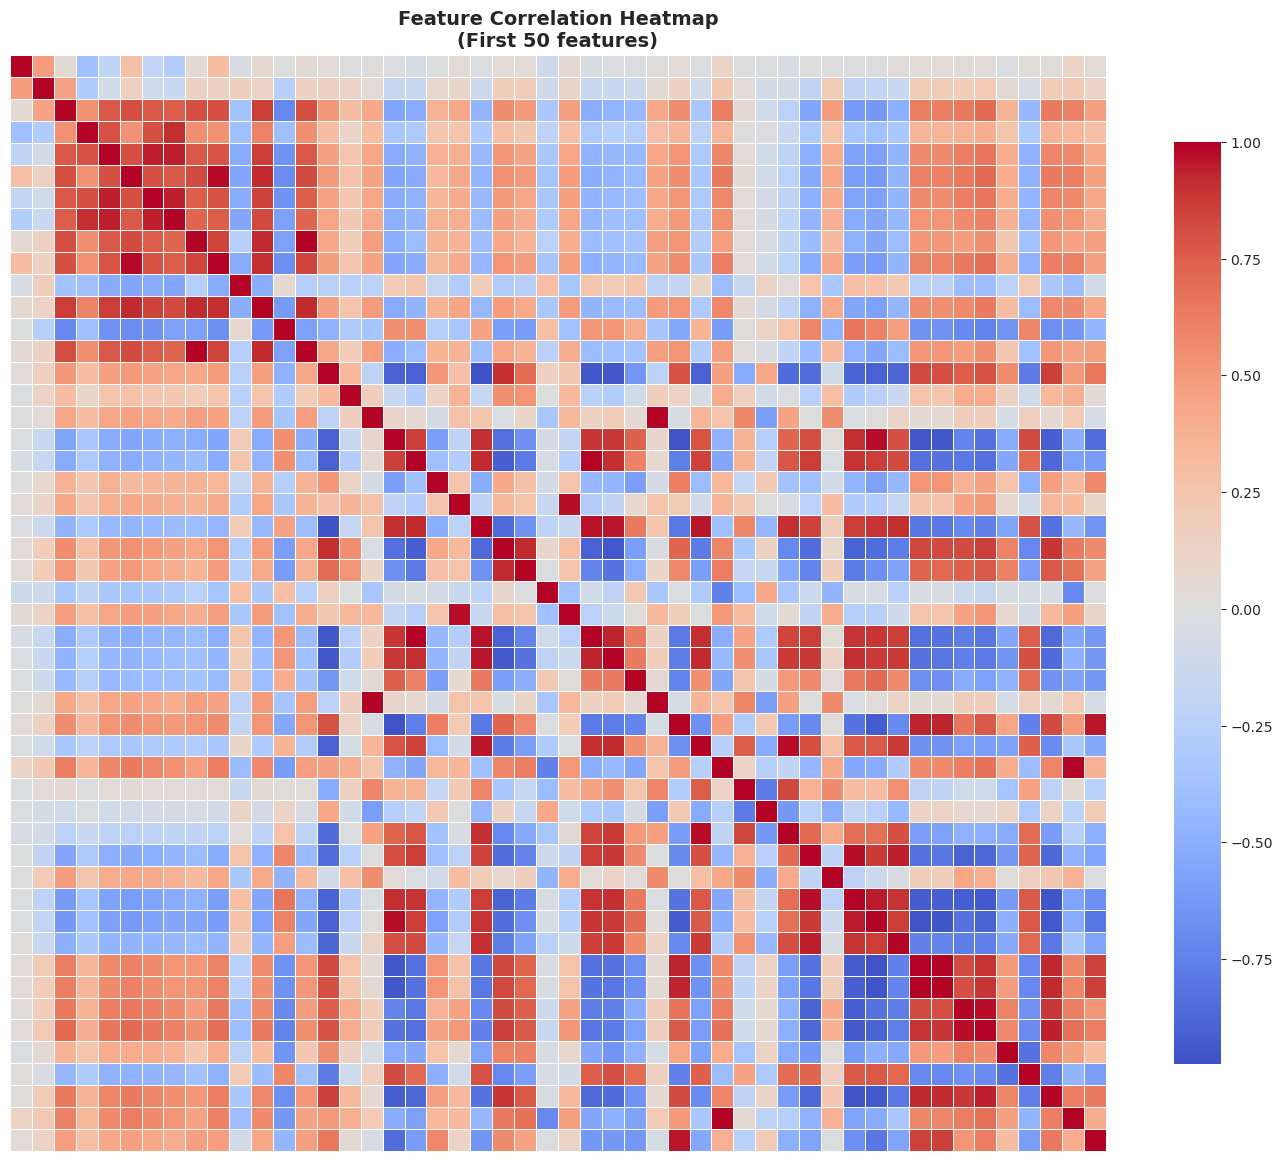


FEATURE QUALITY CHECK SUMMARY

Total features: 443
Total patients: 421

Quality Issues:
  1. Constant features (variance ≈ 0): 0
  2. High missing rate (>50%): 0
  3. High outlier rate (>10%): 0
  4. High correlations (|r| > 0.95): 21 pairs

Recommendation:
  → Remove 0 invalid features
  → Remaining: 443 features

✅ Invalid features list saved: data3d/outputs/invalid_features.json

✅ QUALITY CHECK COMPLETED!

Visualizing feature distributions...

✅ Feature distributions saved: data3d/outputs/feature_distributions.png


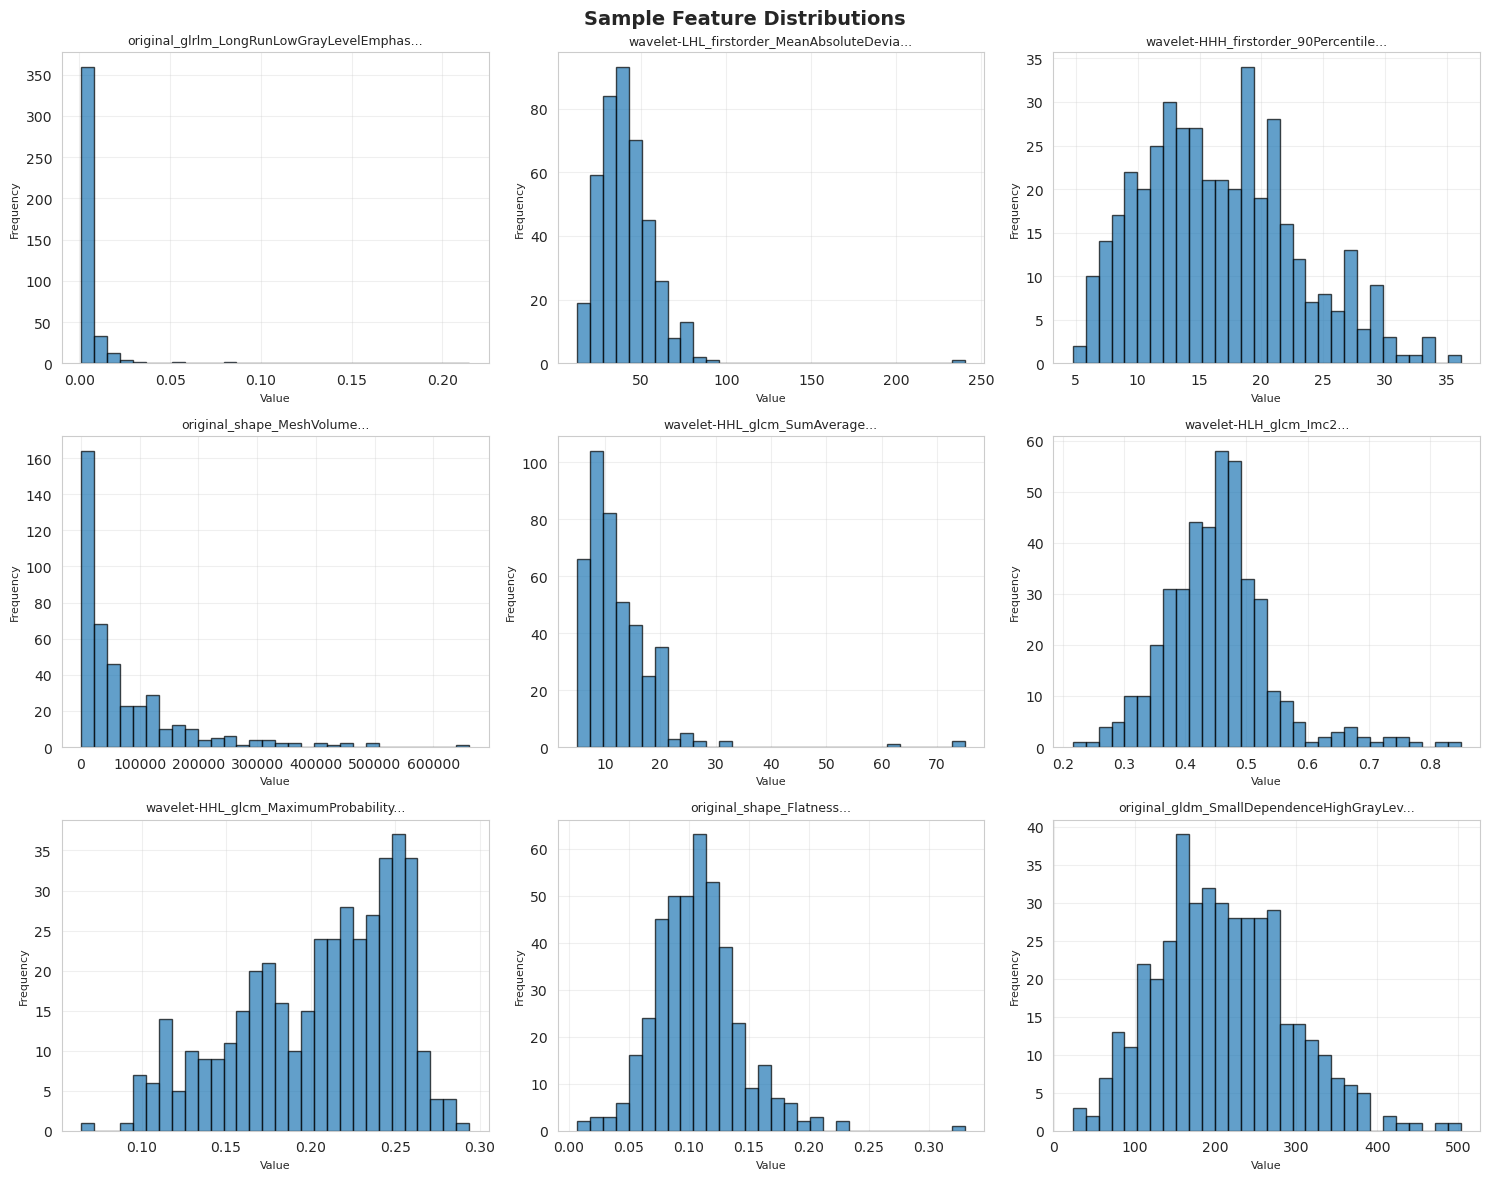

In [11]:
# Khởi tạo an toàn (nếu biến chưa tồn tại)
feature_matrix = globals().get("feature_matrix", None)
feature_names = globals().get("feature_names", None)

# Load feature matrix nếu chưa có trong memory
if feature_matrix is None:
    print("Loading saved feature matrix...")
    feature_matrix_path = OUTPUT_DIR / "radiomic_features_440.npy"
    feature_names_path = OUTPUT_DIR / "feature_names.json"
    
    if feature_matrix_path.exists() and feature_names_path.exists():
        feature_matrix = np.load(feature_matrix_path)
        with open(feature_names_path, 'r') as f:
            feature_names = json.load(f)
        print(f"✅ Loaded feature matrix: {feature_matrix.shape}")
    else:
        print("❌ Feature matrix chưa được tạo! Vui lòng chạy Section 2.3 trước.")
        
# Check 1: Constant features (variance = 0)
if feature_matrix is not None:
    print("=" * 70)
    print("CHECK 1: CONSTANT FEATURES (Variance = 0)")
    print("=" * 70)
    
    # Tính variance cho mỗi feature
    feature_variances = np.nanvar(feature_matrix, axis=0)
    
    # Tìm constant features
    constant_threshold = 1e-10
    constant_features_idx = np.where(feature_variances < constant_threshold)[0]
    
    print(f"\nSố lượng constant features: {len(constant_features_idx)}")
    
    if len(constant_features_idx) > 0:
        print("\nConstant features (10 đầu tiên):")
        for i, idx in enumerate(constant_features_idx[:10]):
            print(f"  {i+1}. {feature_names[idx]}")
        
        constant_features_list = [feature_names[i] for i in constant_features_idx]
    else:
        print("\n✅ Không có constant features!")
        constant_features_list = []
        
# Check 2: Features with high missing rate (>50%)
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 2: FEATURES WITH HIGH MISSING RATE (>50%)")
    print("=" * 70)
    
    # Tính missing rate cho mỗi feature
    missing_rates = np.sum(np.isnan(feature_matrix), axis=0) / feature_matrix.shape[0]
    
    # Tìm features với missing rate > 50%
    high_missing_idx = np.where(missing_rates > 0.5)[0]
    
    print(f"\nSố lượng features với missing rate >50%: {len(high_missing_idx)}")
    
    if len(high_missing_idx) > 0:
        print("\nFeatures with high missing rate (10 đầu tiên):")
        for i, idx in enumerate(high_missing_idx[:10]):
            print(f"  {i+1}. {feature_names[idx]} (missing: {missing_rates[idx]*100:.1f}%)")
        
        high_missing_features_list = [feature_names[i] for i in high_missing_idx]
    else:
        print("\n✅ Không có features với missing rate >50%!")
        high_missing_features_list = []       
        
# Check 3: Features with extreme outliers
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 3: FEATURES WITH EXTREME OUTLIERS")
    print("=" * 70)
    
    # Sử dụng IQR method để detect outliers
    outlier_features = []
    
    for i in range(feature_matrix.shape[1]):
        feature_values = feature_matrix[:, i]
        feature_values = feature_values[~np.isnan(feature_values)]  # Bỏ NaN
        
        if len(feature_values) > 0:
            q1 = np.percentile(feature_values, 25)
            q3 = np.percentile(feature_values, 75)
            iqr = q3 - q1
            
            # Outliers: values ngoài [Q1 - 3*IQR, Q3 + 3*IQR]
            lower_bound = q1 - 3 * iqr
            upper_bound = q3 + 3 * iqr
            
            n_outliers = np.sum((feature_values < lower_bound) | (feature_values > upper_bound))
            outlier_rate = n_outliers / len(feature_values)
            
            # Flag nếu >10% là outliers
            if outlier_rate > 0.1:
                outlier_features.append({
                    'name': feature_names[i],
                    'outlier_rate': outlier_rate,
                    'n_outliers': n_outliers
                })
    
    print(f"\nSố lượng features với >10% outliers: {len(outlier_features)}")
    
    if len(outlier_features) > 0:
        print("\nFeatures with high outlier rate (10 đầu tiên):")
        outlier_features_sorted = sorted(outlier_features, key=lambda x: x['outlier_rate'], reverse=True)
        for i, feat in enumerate(outlier_features_sorted[:10]):
            print(f"  {i+1}. {feat['name']} (outliers: {feat['outlier_rate']*100:.1f}%, n={feat['n_outliers']})")
    else:
        print("\n✅ Không có features với outlier rate >10%!")      
        
# Check 4: Feature correlations (sample)
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("CHECK 4: FEATURE CORRELATIONS (Sample)")
    print("=" * 70)
    
    # Chọn 50 features đầu tiên để visualize correlation
    n_sample_features = min(50, feature_matrix.shape[1])
    
    # Remove NaN values cho correlation
    sample_matrix = feature_matrix[:, :n_sample_features]
    
    # Tính correlation matrix
    # Note: np.corrcoef không handle NaN tốt, nên ta dùng pandas
    df = pd.DataFrame(sample_matrix, columns=feature_names[:n_sample_features])
    corr_matrix = df.corr()
    
    print(f"\nTính correlation cho {n_sample_features} features đầu tiên...")
    
    # Tìm high correlation pairs (|corr| > 0.95)
    high_corr_pairs = []
    for i in range(len(corr_matrix)):
        for j in range(i+1, len(corr_matrix)):
            if abs(corr_matrix.iloc[i, j]) > 0.95:
                high_corr_pairs.append({
                    'feature1': feature_names[i],
                    'feature2': feature_names[j],
                    'correlation': corr_matrix.iloc[i, j]
                })
    
    print(f"\nSố lượng high correlation pairs (|r| > 0.95): {len(high_corr_pairs)}")
    
    if len(high_corr_pairs) > 0:
        print("\nHigh correlation pairs (10 đầu tiên):")
        for i, pair in enumerate(high_corr_pairs[:10]):
            print(f"  {i+1}. {pair['feature1'][:40]}...")
            print(f"      ↔ {pair['feature2'][:40]}...")
            print(f"      Correlation: {pair['correlation']:.4f}")
            print()
    
    # Visualize correlation heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8},
                xticklabels=False, yticklabels=False)
    plt.title(f'Feature Correlation Heatmap\n(First {n_sample_features} features)', 
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save heatmap
    heatmap_path = OUTPUT_DIR / "correlation_heatmap.png"
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    print(f"\n✅ Correlation heatmap saved: {heatmap_path}")
    
    plt.show()   
    
# Summary của Quality Check
if feature_matrix is not None:
    print("\n" + "=" * 70)
    print("FEATURE QUALITY CHECK SUMMARY")
    print("=" * 70)
    
    print(f"\nTotal features: {len(feature_names)}")
    print(f"Total patients: {feature_matrix.shape[0]}")
    
    print("\nQuality Issues:")
    print(f"  1. Constant features (variance ≈ 0): {len(constant_features_list)}")
    print(f"  2. High missing rate (>50%): {len(high_missing_features_list)}")
    print(f"  3. High outlier rate (>10%): {len(outlier_features)}")
    print(f"  4. High correlations (|r| > 0.95): {len(high_corr_pairs)} pairs")
    
    # Tạo danh sách features nên remove
    features_to_remove = list(set(constant_features_list + high_missing_features_list))
    
    print(f"\nRecommendation:")
    print(f"  → Remove {len(features_to_remove)} invalid features")
    print(f"  → Remaining: {len(feature_names) - len(features_to_remove)} features")
    
    # Lưu danh sách features to remove
    invalid_features_path = OUTPUT_DIR / "invalid_features.json"
    invalid_features_info = {
        'constant_features': constant_features_list,
        'high_missing_features': high_missing_features_list,
        'features_to_remove': features_to_remove,
        'n_invalid': len(features_to_remove),
        'n_valid': len(feature_names) - len(features_to_remove)
    }
    
    with open(invalid_features_path, 'w') as f:
        json.dump(invalid_features_info, f, indent=2)
    
    print(f"\n✅ Invalid features list saved: {invalid_features_path}")
    
    print("\n" + "=" * 70)
    print("✅ QUALITY CHECK COMPLETED!")
    print("=" * 70) 
    
# Visualize feature distributions (sample)
if feature_matrix is not None:
    print("\nVisualizing feature distributions...\n")
    
    # Chọn 9 features ngẫu nhiên để visualize
    n_viz = min(9, feature_matrix.shape[1])
    random_indices = np.random.choice(feature_matrix.shape[1], n_viz, replace=False)
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(random_indices):
        feature_values = feature_matrix[:, idx]
        feature_values = feature_values[~np.isnan(feature_values)]  # Remove NaN
        
        if len(feature_values) > 0:
            axes[i].hist(feature_values, bins=30, edgecolor='black', alpha=0.7)
            axes[i].set_title(f"{feature_names[idx][:40]}...", fontsize=9)
            axes[i].set_xlabel('Value', fontsize=8)
            axes[i].set_ylabel('Frequency', fontsize=8)
            axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Sample Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save
    dist_path = OUTPUT_DIR / "feature_distributions.png"
    plt.savefig(dist_path, dpi=150, bbox_inches='tight')
    print(f"✅ Feature distributions saved: {dist_path}")
    
    plt.show()    

---
## 🎯 Checkpoint: Feature Extraction Completed!

### Outputs:

1. **Feature Matrix**: `data/features/radiomic_features_440.npy`
   - Shape: (n_patients, ~440 features)
   
2. **Feature Names**: `data/features/feature_names.json`
   - List of all feature names
   
3. **Patient IDs**: `data/features/patient_ids.json`
   - List of patient IDs corresponding to rows
   
4. **Metadata**: `data/features/extraction_metadata.json`
   - Extraction statistics and info
   
5. **Quality Check Results**:
   - `invalid_features.json`: List of features to remove
   - `correlation_heatmap.png`: Correlation visualization
   - `feature_distributions.png`: Distribution plots

### Next Steps:

- **Notebook 3**: Feature selection and dimensionality reduction
- **Notebook 4**: Build prognostic models

---

In [12]:
# Final summary
print("\n" + "="*70)
print("📊 NOTEBOOK 2 COMPLETED SUCCESSFULLY! 📊")
print("="*70)

if feature_matrix is not None:
    print(f"\n✅ Feature extraction completed for {feature_matrix.shape[0]} patients")
    print(f"✅ Total features extracted: {feature_matrix.shape[1]}")
    print(f"✅ Valid features (after QC): {len(feature_names) - len(features_to_remove)}")
    print(f"\nAll results saved to: {OUTPUT_DIR}")
else:
    print("\n⚠️ Feature extraction chưa hoàn thành.")
    print("Vui lòng kiểm tra lại các cells phía trên.")

print("\n" + "="*70)


📊 NOTEBOOK 2 COMPLETED SUCCESSFULLY! 📊

✅ Feature extraction completed for 421 patients
✅ Total features extracted: 443
✅ Valid features (after QC): 443

All results saved to: data3d/outputs



In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Feature Selection and Normalization Pipeline
============================================

This script implements comprehensive feature selection and normalization
for radiomic features extracted from lung cancer CT scans.

UPDATED: Now works with 3D volume-extracted features (not 2D slices)

Main Features:
--------------
1. Feature Selection Methods:
   - Variance threshold filtering
   - Correlation-based redundancy removal
   - Statistical tests (ANOVA F-test, Mutual Information)
   - Recursive Feature Elimination (RFE)
   - Tree-based feature importance

2. Normalization Methods:
   - StandardScaler (Z-score normalization)
   - MinMaxScaler (0-1 scaling)
   - RobustScaler (robust to outliers)

3. Visualization:
   - Feature importance plots
   - Feature selection comparison
   - Distribution before/after normalization

Author: Claude
Date: 2025-11-18
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional
from pathlib import Path

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    SelectFromModel
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import pickle

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


class FeatureSelectionPipeline:
    """
    Comprehensive feature selection and normalization pipeline.

    Attributes:
        features: Input feature matrix (n_samples, n_features)
        feature_names: List of feature names
        labels: Target labels for supervised selection (optional)
        selected_features_: Dictionary storing selected features from each method
        scalers_: Dictionary storing fitted scalers
    """

    def __init__(self, features: np.ndarray, feature_names: List[str],
                 labels: Optional[np.ndarray] = None):
        """
        Initialize the feature selection pipeline.

        Parameters:
            features: Feature matrix (n_samples, n_features)
            feature_names: List of feature names
            labels: Target labels for supervised methods (optional)
        """
        self.features = features
        self.feature_names = np.array(feature_names)
        self.labels = labels
        self.selected_features_ = {}
        self.scalers_ = {}

        print(f"📊 Initialized with {features.shape[0]} samples and {features.shape[1]} features")
        if labels is not None:
            unique_labels, counts = np.unique(labels, return_counts=True)
            print(f"📋 Labels: {dict(zip(unique_labels, counts))}")

    def remove_low_variance(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove features with low variance.

        Parameters:
            threshold: Variance threshold (default: 0.01)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing low variance features (threshold={threshold})...")

        selector = VarianceThreshold(threshold=threshold)
        features_selected = selector.fit_transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        n_removed = len(self.feature_names) - len(feature_names_selected)
        print(f"   ✓ Removed {n_removed} features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['low_variance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support()
        }

        return features_selected, feature_names_selected

    def remove_correlated_features(self, threshold: float = 0.9) -> Tuple[np.ndarray, np.ndarray]:
        """
        Remove highly correlated features.

        Parameters:
            threshold: Correlation threshold (default: 0.9)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        print(f"\n🔍 Removing correlated features (|r| > {threshold})...")

        # Calculate correlation matrix
        df = pd.DataFrame(self.features, columns=self.feature_names)
        corr_matrix = df.corr().abs()

        # Select upper triangle of correlation matrix
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # Find features with correlation greater than threshold
        to_drop = [column for column in upper_triangle.columns
                   if any(upper_triangle[column] > threshold)]

        # Keep features not in to_drop
        feature_mask = ~df.columns.isin(to_drop)
        features_selected = df.loc[:, feature_mask].values
        feature_names_selected = df.columns[feature_mask].values

        print(f"   ✓ Removed {len(to_drop)} correlated features")
        print(f"   ✓ Retained {len(feature_names_selected)} features")

        self.selected_features_['correlation'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'removed_features': to_drop,
            'support': feature_mask
        }

        return features_selected, feature_names_selected

    def select_anova_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using ANOVA F-test.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for ANOVA feature selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using ANOVA F-test...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(f_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get F-scores
        f_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest F-scores")
        print(f"   ✓ F-score range: {f_scores.min():.2f} - {f_scores.max():.2f}")

        self.selected_features_['anova'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': f_scores
        }

        return features_selected, feature_names_selected

    def select_mutual_info_features(self, k: int = 50) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select top k features using Mutual Information.

        Parameters:
            k: Number of top features to select

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for Mutual Information selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting top {k} features using Mutual Information...")

        # Handle case where k > n_features
        k = min(k, self.features.shape[1])

        selector = SelectKBest(mutual_info_classif, k=k)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get MI scores
        mi_scores = selector.scores_

        print(f"   ✓ Selected {k} features with highest MI scores")
        print(f"   ✓ MI score range: {mi_scores.min():.4f} - {mi_scores.max():.4f}")

        self.selected_features_['mutual_info'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'scores': mi_scores
        }

        return features_selected, feature_names_selected

    def select_rfe_features(self, n_features: int = 30,
                           estimator=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features using Recursive Feature Elimination.

        Parameters:
            n_features: Number of features to select
            estimator: Estimator to use (default: LogisticRegression)

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for RFE. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting {n_features} features using RFE...")

        # Default estimator
        if estimator is None:
            estimator = LogisticRegression(max_iter=1000, random_state=42)

        # Handle case where n_features > n_features
        n_features = min(n_features, self.features.shape[1])

        selector = RFE(estimator, n_features_to_select=n_features, step=1)
        features_selected = selector.fit_transform(self.features, self.labels)
        feature_names_selected = self.feature_names[selector.get_support()]

        print(f"   ✓ Selected {n_features} features using RFE")
        print(f"   ✓ Ranking range: {selector.ranking_.min()} - {selector.ranking_.max()}")

        self.selected_features_['rfe'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'ranking': selector.ranking_
        }

        return features_selected, feature_names_selected

    def select_tree_importance_features(self, threshold: float = 0.01) -> Tuple[np.ndarray, np.ndarray]:
        """
        Select features based on tree-based feature importance.

        Parameters:
            threshold: Importance threshold

        Returns:
            Tuple of (selected_features, selected_feature_names)
        """
        if self.labels is None:
            print("⚠️  Labels required for tree-based selection. Skipping...")
            return self.features, self.feature_names

        print(f"\n🔍 Selecting features using Random Forest importance...")

        # Train Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.features, self.labels)

        # Select based on importance
        selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        features_selected = selector.transform(self.features)
        feature_names_selected = self.feature_names[selector.get_support()]

        # Get importances
        importances = rf.feature_importances_

        print(f"   ✓ Selected {len(feature_names_selected)} features")
        print(f"   ✓ Importance range: {importances.min():.4f} - {importances.max():.4f}")

        self.selected_features_['tree_importance'] = {
            'features': features_selected,
            'feature_names': feature_names_selected,
            'support': selector.get_support(),
            'importances': importances
        }

        return features_selected, feature_names_selected

    def normalize_features(self, method: str = 'standard') -> np.ndarray:
        """
        Normalize features using specified method.

        Parameters:
            method: Normalization method ('standard', 'minmax', or 'robust')

        Returns:
            Normalized features
        """
        print(f"\n🔧 Normalizing features using {method} scaler...")

        if method == 'standard':
            scaler = StandardScaler()
        elif method == 'minmax':
            scaler = MinMaxScaler()
        elif method == 'robust':
            scaler = RobustScaler()
        else:
            raise ValueError(f"Unknown normalization method: {method}")

        features_normalized = scaler.fit_transform(self.features)
        self.scalers_[method] = scaler

        print(f"   ✓ Features normalized")
        print(f"   ✓ Mean: {features_normalized.mean():.4f}, Std: {features_normalized.std():.4f}")

        return features_normalized

    def visualize_feature_selection(self, output_dir: str = 'visualizations'):
        """
        Visualize feature selection results.

        Parameters:
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating feature selection visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        # 1. Number of features selected by each method
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # Plot 1: Feature counts comparison
        ax = axes[0, 0]
        methods = list(self.selected_features_.keys())
        counts = [len(self.selected_features_[m]['feature_names']) for m in methods]

        colors = plt.cm.Set3(range(len(methods)))
        bars = ax.bar(methods, counts, color=colors)
        ax.set_ylabel('Number of Features', fontsize=12)
        ax.set_title('Feature Selection Methods Comparison', fontsize=14, fontweight='bold')
        ax.set_ylim(0, max(counts) * 1.2)

        # Add value labels on bars
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(count)}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Plot 2: Feature importance (if available)
        ax = axes[0, 1]
        if 'tree_importance' in self.selected_features_:
            importances = self.selected_features_['tree_importance']['importances']
            feature_names = self.feature_names

            # Sort by importance
            indices = np.argsort(importances)[::-1][:20]  # Top 20

            ax.barh(range(len(indices)), importances[indices], color='steelblue')
            ax.set_yticks(range(len(indices)))
            ax.set_yticklabels([feature_names[i][:30] for i in indices], fontsize=8)
            ax.set_xlabel('Feature Importance', fontsize=12)
            ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'No importance data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('Feature Importance', fontsize=14, fontweight='bold')

        # Plot 3: ANOVA F-scores (if available)
        ax = axes[1, 0]
        if 'anova' in self.selected_features_:
            scores = self.selected_features_['anova']['scores']

            ax.hist(scores[~np.isnan(scores)], bins=50, color='coral', alpha=0.7, edgecolor='black')
            ax.set_xlabel('F-score', fontsize=12)
            ax.set_ylabel('Frequency', fontsize=12)
            ax.set_title('Distribution of ANOVA F-scores', fontsize=14, fontweight='bold')
            ax.axvline(np.median(scores[~np.isnan(scores)]), color='red', linestyle='--',
                      linewidth=2, label=f'Median: {np.median(scores[~np.isnan(scores)]):.2f}')
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'No ANOVA data available',
                   ha='center', va='center', fontsize=12)
            ax.set_title('ANOVA F-scores', fontsize=14, fontweight='bold')

        # Plot 4: Feature overlap (Venn-style comparison)
        ax = axes[1, 1]
        if len(self.selected_features_) >= 2:
            # Compare first two methods
            method_keys = list(self.selected_features_.keys())[:3]

            if len(method_keys) >= 2:
                sets = []
                labels = []
                for key in method_keys:
                    sets.append(set(self.selected_features_[key]['feature_names']))
                    labels.append(key)

                # Calculate overlaps
                overlap_data = []
                for i in range(len(sets)):
                    for j in range(i+1, len(sets)):
                        overlap = len(sets[i].intersection(sets[j]))
                        overlap_data.append({
                            'Method 1': labels[i],
                            'Method 2': labels[j],
                            'Overlap': overlap
                        })

                if overlap_data:
                    df_overlap = pd.DataFrame(overlap_data)

                    # Create bar plot
                    x_pos = range(len(df_overlap))
                    bars = ax.bar(x_pos, df_overlap['Overlap'], color='mediumseagreen')
                    ax.set_xticks(x_pos)
                    ax.set_xticklabels([f"{row['Method 1']}\nvs\n{row['Method 2']}"
                                       for _, row in df_overlap.iterrows()], fontsize=9)
                    ax.set_ylabel('Number of Overlapping Features', fontsize=12)
                    ax.set_title('Feature Overlap Between Methods', fontsize=14, fontweight='bold')

                    # Add value labels
                    for bar, overlap in zip(bars, df_overlap['Overlap']):
                        height = bar.get_height()
                        ax.text(bar.get_x() + bar.get_width()/2., height,
                               f'{int(overlap)}',
                               ha='center', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        output_path = os.path.join(output_dir, '06_feature_selection_analysis.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def visualize_normalization(self, features_before: np.ndarray,
                               features_after: np.ndarray,
                               method: str,
                               output_dir: str = 'visualizations'):
        """
        Visualize the effect of normalization.

        Parameters:
            features_before: Features before normalization
            features_after: Features after normalization
            method: Normalization method name
            output_dir: Directory to save visualizations
        """
        print(f"\n📊 Creating normalization visualization...")

        os.makedirs(output_dir, exist_ok=True)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Select 3 random features to visualize
        n_features = min(3, features_before.shape[1])
        feature_indices = np.random.choice(features_before.shape[1], n_features, replace=False)

        for idx, feature_idx in enumerate(feature_indices):
            # Before normalization
            ax_before = axes[0, idx]
            ax_before.hist(features_before[:, feature_idx], bins=30,
                          color='skyblue', alpha=0.7, edgecolor='black')
            ax_before.set_title(f'Feature {feature_idx} - Before {method}',
                              fontsize=12, fontweight='bold')
            ax_before.set_xlabel('Value', fontsize=10)
            ax_before.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_before = features_before[:, feature_idx].mean()
            std_before = features_before[:, feature_idx].std()
            ax_before.axvline(mean_before, color='red', linestyle='--', linewidth=2,
                            label=f'μ={mean_before:.2f}, σ={std_before:.2f}')
            ax_before.legend(fontsize=9)

            # After normalization
            ax_after = axes[1, idx]
            ax_after.hist(features_after[:, feature_idx], bins=30,
                         color='lightcoral', alpha=0.7, edgecolor='black')
            ax_after.set_title(f'Feature {feature_idx} - After {method}',
                             fontsize=12, fontweight='bold')
            ax_after.set_xlabel('Value', fontsize=10)
            ax_after.set_ylabel('Frequency', fontsize=10)

            # Add statistics
            mean_after = features_after[:, feature_idx].mean()
            std_after = features_after[:, feature_idx].std()
            ax_after.axvline(mean_after, color='red', linestyle='--', linewidth=2,
                           label=f'μ={mean_after:.2f}, σ={std_after:.2f}')
            ax_after.legend(fontsize=9)

        plt.suptitle(f'Effect of {method.capitalize()} Normalization',
                    fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()

        output_path = os.path.join(output_dir, f'07_normalization_{method}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def save_selected_features(self, output_dir: str = 'data3d/outputs'):
        """
        Save selected features to disk.

        Parameters:
            output_dir: Directory to save processed data
        """
        print(f"\n💾 Saving selected features...")

        os.makedirs(output_dir, exist_ok=True)

        for method, data in self.selected_features_.items():
            # Save feature matrix
            feature_path = os.path.join(output_dir, f'features_{method}.npy')
            np.save(feature_path, data['features'])

            # Save feature names
            names_path = os.path.join(output_dir, f'feature_names_{method}.json')
            with open(names_path, 'w') as f:
                json.dump(data['feature_names'].tolist(), f, indent=2)

            print(f"   ✓ Saved {method}: {feature_path}")

        # Save summary
        summary = {
            'total_original_features': len(self.feature_names),
            'methods': {}
        }

        for method, data in self.selected_features_.items():
            summary['methods'][method] = {
                'n_features': len(data['feature_names']),
                'feature_names': data['feature_names'].tolist()
            }

        summary_path = os.path.join(output_dir, 'feature_selection_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(summary, f, indent=2)

        print(f"   ✓ Saved summary: {summary_path}")

    def save_normalized_features(self, features_normalized: np.ndarray,
                                 method: str = 'standard',
                                 output_dir: str = 'data3d/outputs'):
        """
        Save normalized features and scaler to disk.

        Parameters:
            features_normalized: Normalized feature matrix
            method: Normalization method name ('standard', 'minmax', or 'robust')
            output_dir: Directory to save processed data
        """
        print(f"\n💾 Saving normalized features ({method})...")

        os.makedirs(output_dir, exist_ok=True)

        # Save normalized feature matrix
        features_path = os.path.join(output_dir, f'features_normalized_{method}.npy')
        np.save(features_path, features_normalized)
        print(f"   ✓ Saved normalized features: {features_path}")

        # Save feature names
        names_path = os.path.join(output_dir, f'feature_names_normalized_{method}.json')
        with open(names_path, 'w') as f:
            json.dump(self.feature_names.tolist(), f, indent=2)
        print(f"   ✓ Saved feature names: {names_path}")

        # Save scaler object (for transforming new data)
        if method in self.scalers_:
            scaler_path = os.path.join(output_dir, f'scaler_{method}.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(self.scalers_[method], f)
            print(f"   ✓ Saved scaler: {scaler_path}")
        else:
            print(f"   ⚠️  Scaler for method '{method}' not found in self.scalers_")

        # Save metadata
        metadata = {
            'normalization_method': method,
            'n_samples': features_normalized.shape[0],
            'n_features': features_normalized.shape[1],
            'feature_names': self.feature_names.tolist(),
            'statistics': {
                'mean': float(features_normalized.mean()),
                'std': float(features_normalized.std()),
                'min': float(features_normalized.min()),
                'max': float(features_normalized.max())
            }
        }

        metadata_path = os.path.join(output_dir, f'normalization_metadata_{method}.json')
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=2)
        print(f"   ✓ Saved metadata: {metadata_path}")

        print(f"\n   📊 Normalization Summary:")
        print(f"      - Method: {method}")
        print(f"      - Shape: {features_normalized.shape}")
        print(f"      - Mean: {metadata['statistics']['mean']:.4f}")
        print(f"      - Std: {metadata['statistics']['std']:.4f}")
        print(f"      - Range: [{metadata['statistics']['min']:.4f}, {metadata['statistics']['max']:.4f}]")


def load_real_features():
    """
    Load real radiomic features extracted from 3D volumes.

    Updated to work with new 3D volume-based feature extraction.

    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) or None if not found
    """
    # Updated paths for 3D volume-extracted features
    possible_paths = [
        ("data3d/outputs/radiomic_features_440.npy",
         "data3d/outputs/feature_names.json",
         "data3d/outputs/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Found 3D volume radiomic features at: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs (if available)
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                # Generate default patient IDs
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Patient IDs file not found, generated default IDs")

            return feature_matrix, feature_names, patient_ids

    return None


def load_clinical_data():
    """
    Load clinical data from CSV file.

    Returns:
        pandas DataFrame containing clinical data or None if not found.
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "./data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Found clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            return clinical_df

    print("\n⚠️  No clinical data found.")
    return None


def run_feature_selection_pipeline():
    """
    Run feature selection pipeline with real 3D volume-extracted features.

    Updated to work with features extracted from full 3D tumor volumes.
    """
    print("=" * 80)
    print("🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE")
    print("   (Using 3D Volume-Extracted Features)")
    print("=" * 80)

    # Step 1: Load feature data
    print("\n📊 STEP 1: Loading 3D Volume Feature Data")
    print("-" * 80)
    real_data = load_real_features()
    if real_data is None:
        print("\n❌ ERROR: Could not find 3D volume radiomic features!")
        print("\nPlease run the extraction script first:")
        print("  python extract_radiomic_features_parallel_440_full_volume.py")
        print("\nOr ensure the following files exist:")
        print("  - data/features/radiomic_features_440.npy")
        print("  - data/features/feature_names.json")
        print("  - data/features/patient_ids.json")
        raise FileNotFoundError("Could not find 3D volume radiomic features.")

    X, feature_names, patient_ids = real_data
    print(f"\n✅ Using REAL 3D volume radiomic features. Shape: {X.shape}")

    # Step 2: Load clinical data
    print("\n📊 STEP 2: Loading Clinical Data for Labels")
    print("-" * 80)
    clinical_df = load_clinical_data()
    if clinical_df is None:
        print("\n❌ ERROR: Could not find clinical data!")
        print("\nPlease ensure one of the following files exists:")
        print("  - nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv")
        print("  - data/NSCLC-Radiomics-clinical-data.csv")
        raise FileNotFoundError("Could not find clinical data.")

    # =======================================================================
    # STEP 2.5: ALIGN FEATURE AND CLINICAL DATA
    # =======================================================================
    print("\n📊 STEP 2.5: Aligning Feature and Clinical Data")
    print("-" * 80)

    # Find patient ID column in clinical data
    id_col = None
    possible_id_cols = ['PatientID', 'patient_id', 'case_id', 'Case ID']
    for col in possible_id_cols:
        if col in clinical_df.columns:
            id_col = col
            break

    if id_col is None:
        raise KeyError(f"Could not find patient ID column in clinical data. Tried: {possible_id_cols}")

    print(f"   ✓ Using '{id_col}' as patient identifier.")

    # Create DataFrame from features for easy merging
    features_df = pd.DataFrame(data=X, index=patient_ids, columns=feature_names)

    # Set patient ID as index for clinical data
    clinical_df_indexed = clinical_df.set_index(id_col)

    # Get common patient IDs
    common_patient_ids = features_df.index.intersection(clinical_df_indexed.index)

    print(f"   - Features data has {len(features_df.index)} patients.")
    print(f"   - Clinical data has {len(clinical_df_indexed.index)} patients.")
    print(f"   - Found {len(common_patient_ids)} common patients.")

    # Filter both DataFrames to keep only common patients in same order
    features_aligned = features_df.loc[common_patient_ids]
    clinical_aligned = clinical_df_indexed.loc[common_patient_ids]

    # Update X and patient_ids after alignment
    X_aligned = features_aligned.values
    final_patient_ids = features_aligned.index.tolist()

    print(f"   ✅ Data aligned. Final shape for analysis: {X_aligned.shape}")

    # Create labels 'y' from aligned clinical data
    if 'deadstatus.event' in clinical_aligned.columns:
        y_aligned = clinical_aligned['deadstatus.event'].values
        print(f"   ✅ Using 'deadstatus.event' as labels. Length: {len(y_aligned)}")
    elif 'Survival.time' in clinical_aligned.columns:
        median_survival = clinical_aligned['Survival.time'].median()
        y_aligned = (clinical_aligned['Survival.time'] > median_survival).astype(int)
        print(f"   ✅ Created binary labels from survival time. Length: {len(y_aligned)}")
    else:
        raise KeyError("Could not find 'deadstatus.event' or 'Survival.time' in clinical data.")

    # Final verification
    if X_aligned.shape[0] != len(y_aligned):
        raise ValueError("Critical error: Data still misaligned after processing!")

    # Step 3: Initialize pipeline with aligned data
    print("\n📊 STEP 3: Initializing Feature Selection Pipeline")
    print("-" * 80)
    pipeline = FeatureSelectionPipeline(X_aligned, feature_names, y_aligned)

    # Step 4: Run feature selection methods
    print("\n📊 STEP 4: Running Feature Selection Methods")
    print("-" * 80)

    pipeline.remove_low_variance(threshold=0.01)
    pipeline.remove_correlated_features(threshold=0.9)
    k_anova = min(50, X_aligned.shape[1])
    pipeline.select_anova_features(k=k_anova)
    k_mi = min(50, X_aligned.shape[1])
    pipeline.select_mutual_info_features(k=k_mi)
    n_rfe = min(30, X_aligned.shape[1])
    pipeline.select_rfe_features(n_features=n_rfe)
    pipeline.select_tree_importance_features(threshold=0.01)

    # Step 5: Normalize features
    print("\n📊 STEP 5: Feature Normalization")
    print("-" * 80)
    X_normalized = pipeline.normalize_features(method='standard')

    # Step 6: Visualize results
    print("\n📊 STEP 6: Creating Visualizations")
    print("-" * 80)
    pipeline.visualize_feature_selection()
    pipeline.visualize_normalization(X_aligned, X_normalized, method='standard')

    # Step 7: Save results
    print("\n📊 STEP 7: Saving Results")
    print("-" * 80)
    pipeline.save_selected_features()
    pipeline.save_normalized_features(X_normalized, method='standard')

    # Summary
    print("\n" + "=" * 80)
    print("✅ FEATURE SELECTION PIPELINE COMPLETED!")
    print("=" * 80)
    print(f"\n📊 Summary:")
    print(f"   - Original features: {len(feature_names)}")
    print(f"   - Samples after alignment: {X_aligned.shape[0]}")
    for method, data in pipeline.selected_features_.items():
        print(f"   - {method}: {len(data['feature_names'])} features selected")
    print(f"\n📁 Results saved to:")
    print(f"   - data3d/outputs/features_*.npy (selected features)")
    print(f"   - data3d/outputs/features_normalized_standard.npy (normalized features)")
    print(f"   - data3d/outputs/scaler_standard.pkl (scaler for new data)")
    print(f"   - data3d/outputs/feature_names_normalized_*.json")
    print(f"   - visualizations/06_feature_selection_analysis.png")
    print(f"   - visualizations/07_normalization_standard.png")
    print("=" * 80)


if __name__ == "__main__":
    run_feature_selection_pipeline()

🚀 FEATURE SELECTION AND NORMALIZATION PIPELINE
   (Using 3D Volume-Extracted Features)

📊 STEP 1: Loading 3D Volume Feature Data
--------------------------------------------------------------------------------

📂 Found 3D volume radiomic features at: data3d/outputs
   ✅ Loaded feature matrix: (421, 443)
   ✅ Loaded 443 feature names
   ✅ Loaded 421 patient IDs

✅ Using REAL 3D volume radiomic features. Shape: (421, 443)

📊 STEP 2: Loading Clinical Data for Labels
--------------------------------------------------------------------------------

📂 Found clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)

📊 STEP 2.5: Aligning Feature and Clinical Data
--------------------------------------------------------------------------------
   ✓ Using 'PatientID' as patient identifier.
   - Features data has 421 patients.
   - Clinical data has 422 patients.
   - Found 421 common patients.
   ✅ Data aligned. Final shape for analysis: (421,

NORMALIZED RADIOMICS FEATURES VISUALIZATION

🔍 Đang tìm kiếm normalized features...

📂 Tìm thấy normalized features (standard): data3d/outputs
   ✅ Loaded feature matrix: (421, 443)
   ✅ Loaded 443 feature names
   ✅ Loaded 421 patient IDs
   ✅ Loaded normalization metadata
      - Method: standard
      - Mean: 0.000000
      - Std: 1.000000
      - Range: [-15.026, 20.041]

✅ Sử dụng normalized features!
   Feature matrix: 421 patients × 443 features

📊 Feature groups:
   - Shape: 14 features
   - First-order (Intensity): 162 features
   - GLCM (Texture): 216 features
   - GLRLM (Texture): 16 features
   - GLSZM (Texture): 16 features
   - GLDM (Texture): 14 features
   - NGTDM (Texture): 5 features

PHẦN 2: NORMALIZED FEATURE STATISTICS OVERVIEW

Dataset shape: (421, 443)

Bảng thống kê normalized features (5 features đầu tiên):
       original_shape_Elongation  original_shape_Flatness  \
count               4.210000e+02             4.210000e+02   
mean               -1.991545e-15  

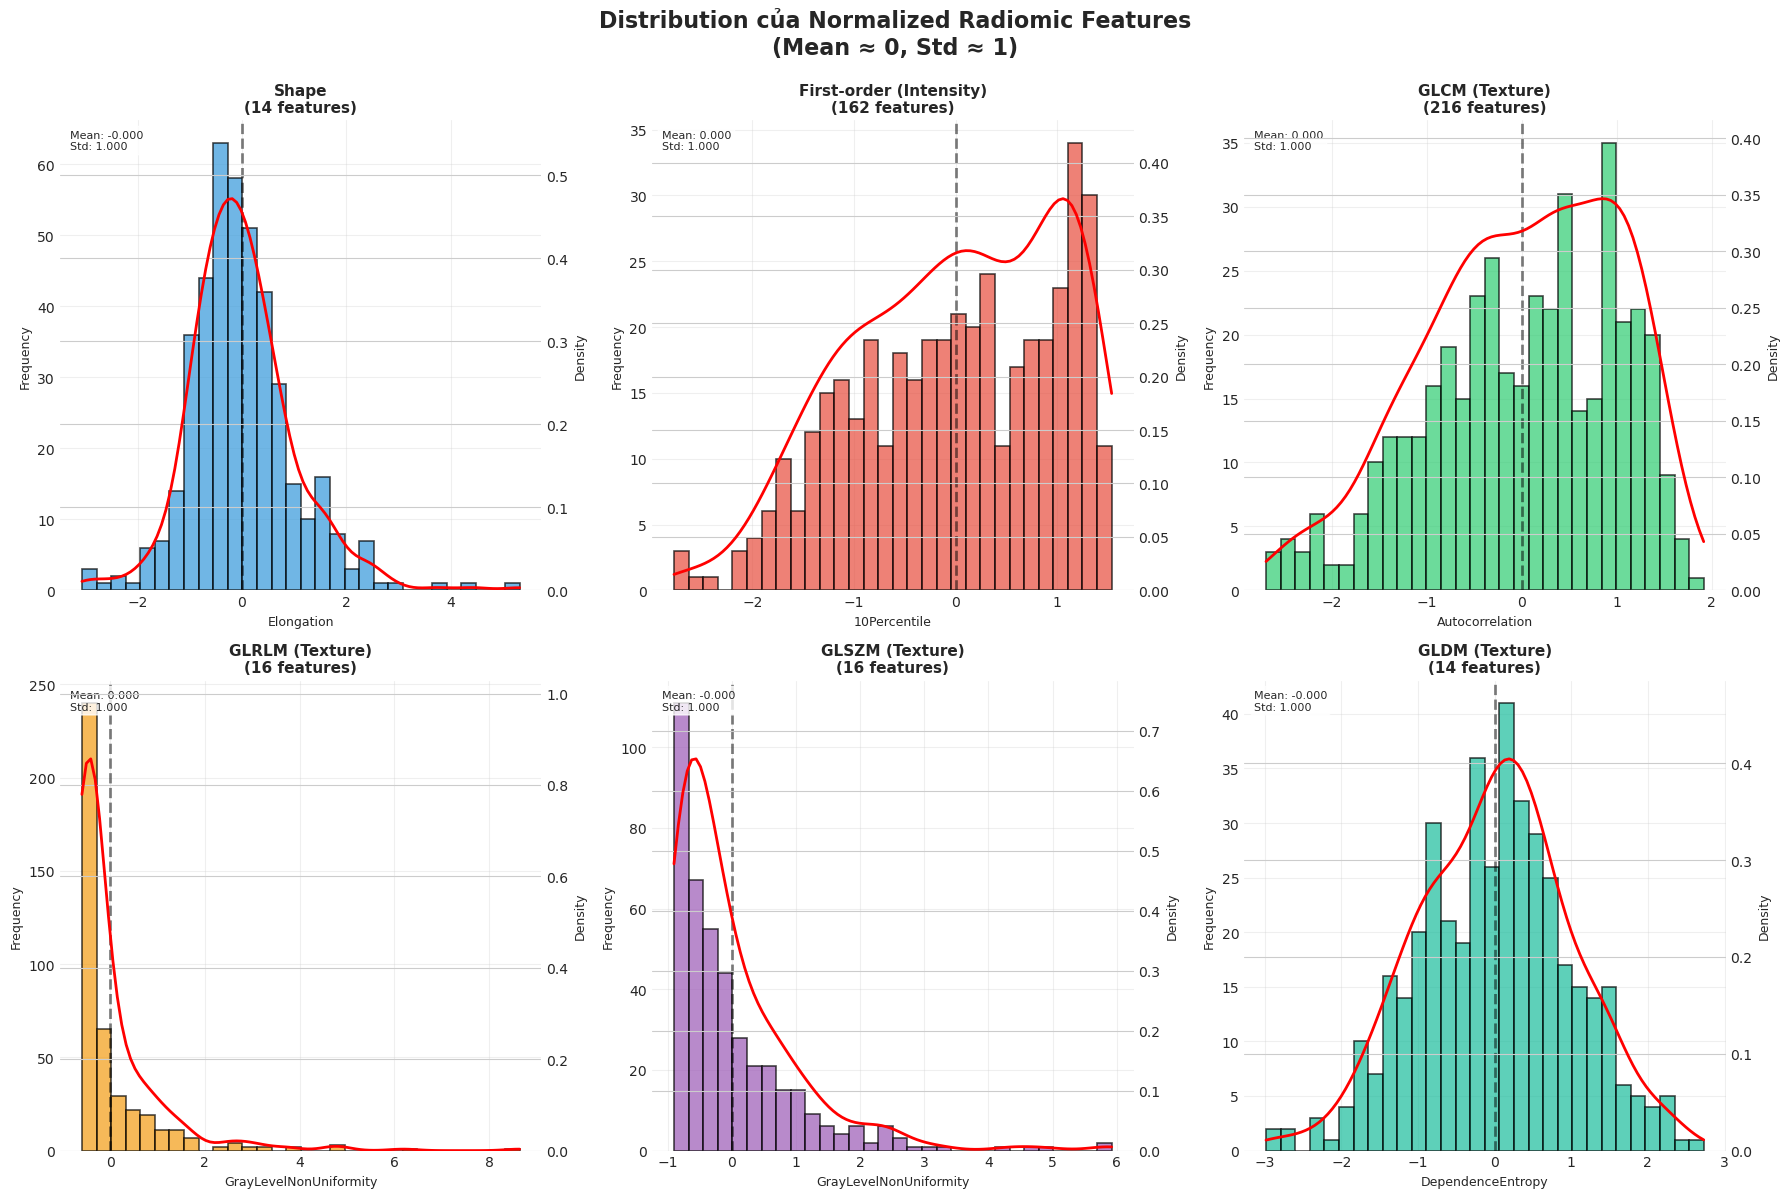


PHẦN 4: CORRELATION MATRIX

✅ Saved: visualizations/02_normalized_correlation_matrix.png


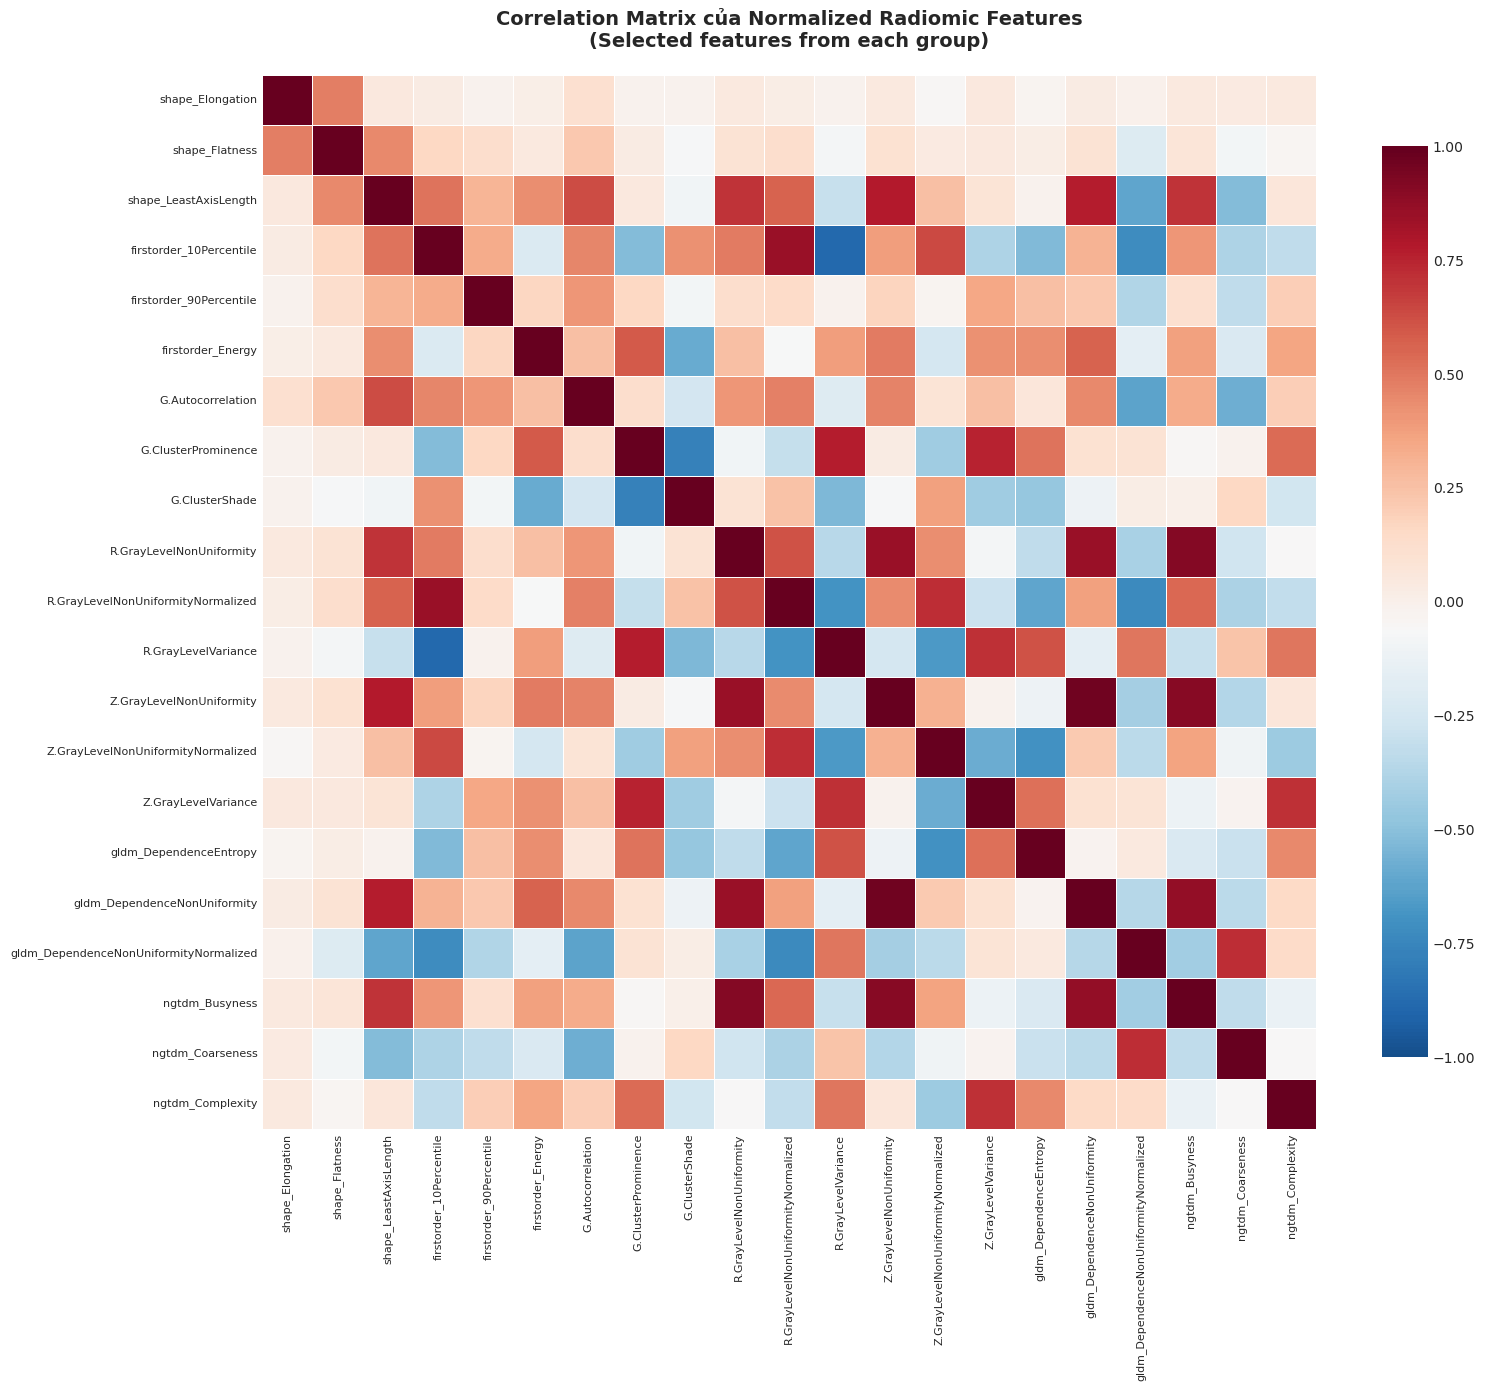


🔍 High Correlation Pairs (|r| > 0.8):
              Feature 1                        Feature 2  Correlation
 GrayLevelNonUniformity          DependenceNonUniformity     0.966177
 GrayLevelNonUniformity                         Busyness     0.908198
 GrayLevelNonUniformity                         Busyness     0.900739
           10Percentile                GrayLevelVariance    -0.886439
DependenceNonUniformity                         Busyness     0.874704
 GrayLevelNonUniformity          DependenceNonUniformity     0.857812
 GrayLevelNonUniformity           GrayLevelNonUniformity     0.851902
           10Percentile GrayLevelNonUniformityNormalized     0.849157

PHẦN 5: SO SÁNH NORMALIZED FEATURES GIỮA PATIENTS

✅ Saved: visualizations/03_normalized_patient_comparison.png


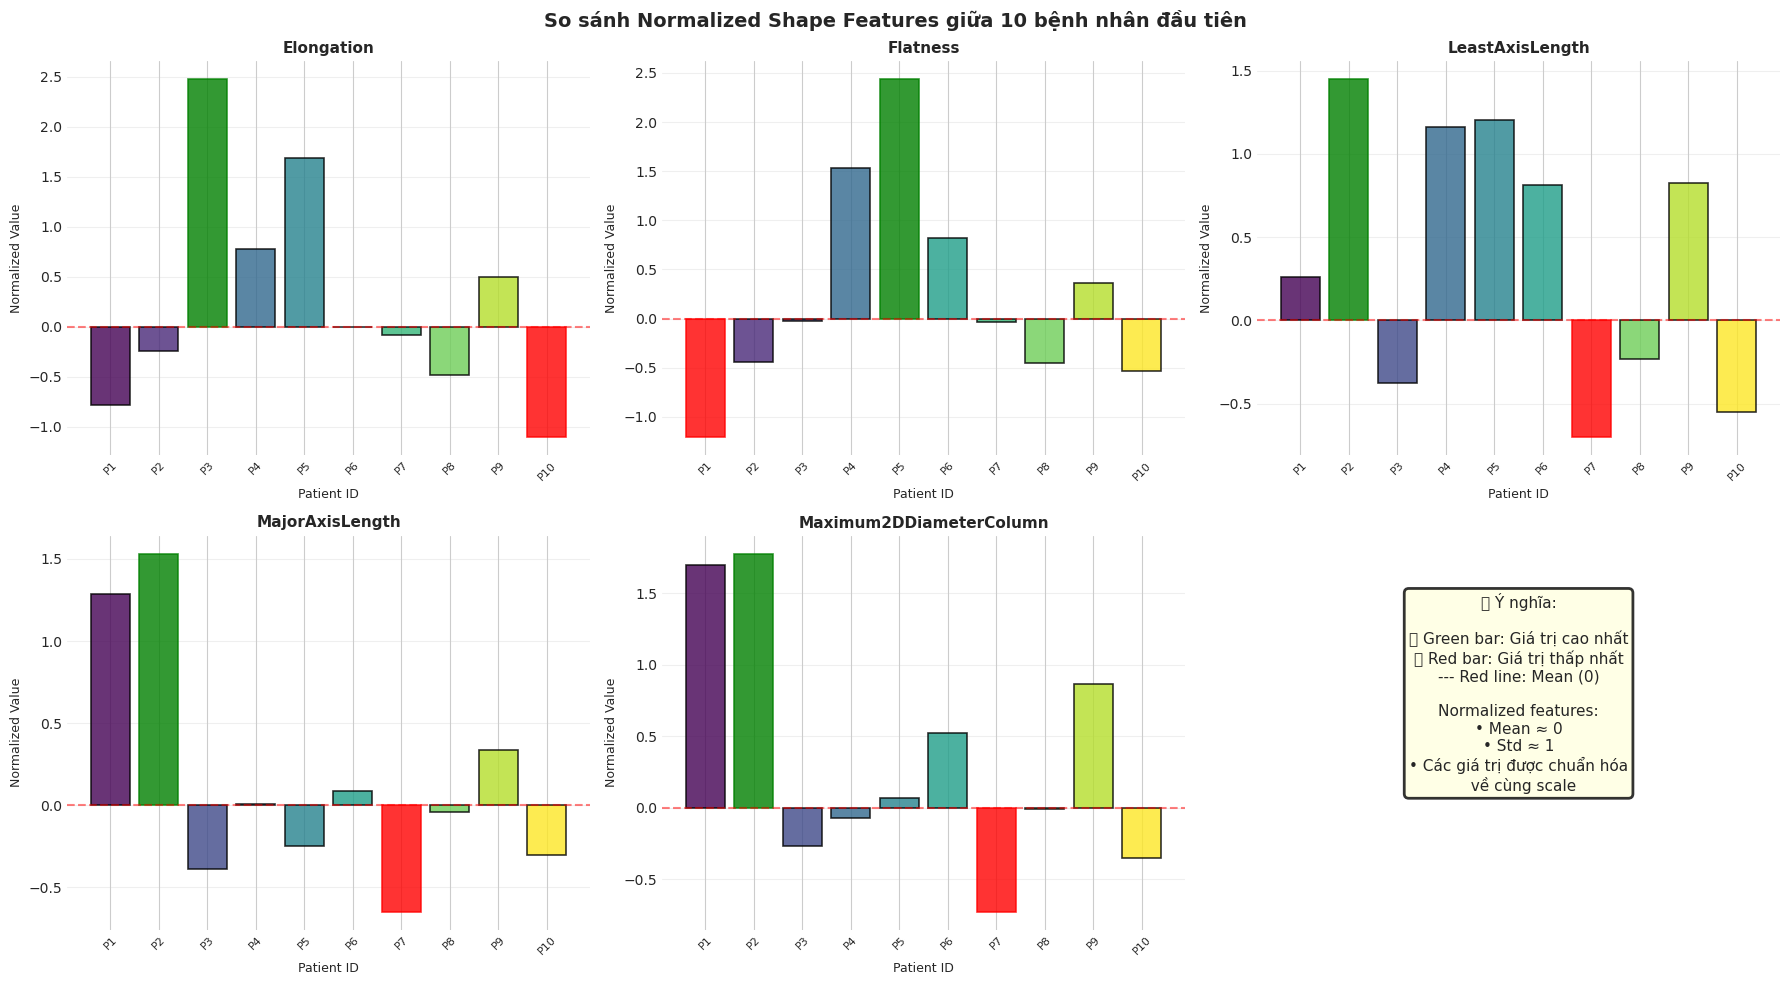


PHẦN 6: PCA ANALYSIS - FEATURE VARIANCE (ON NORMALIZED DATA)

✅ Saved: visualizations/04_normalized_pca_analysis.png


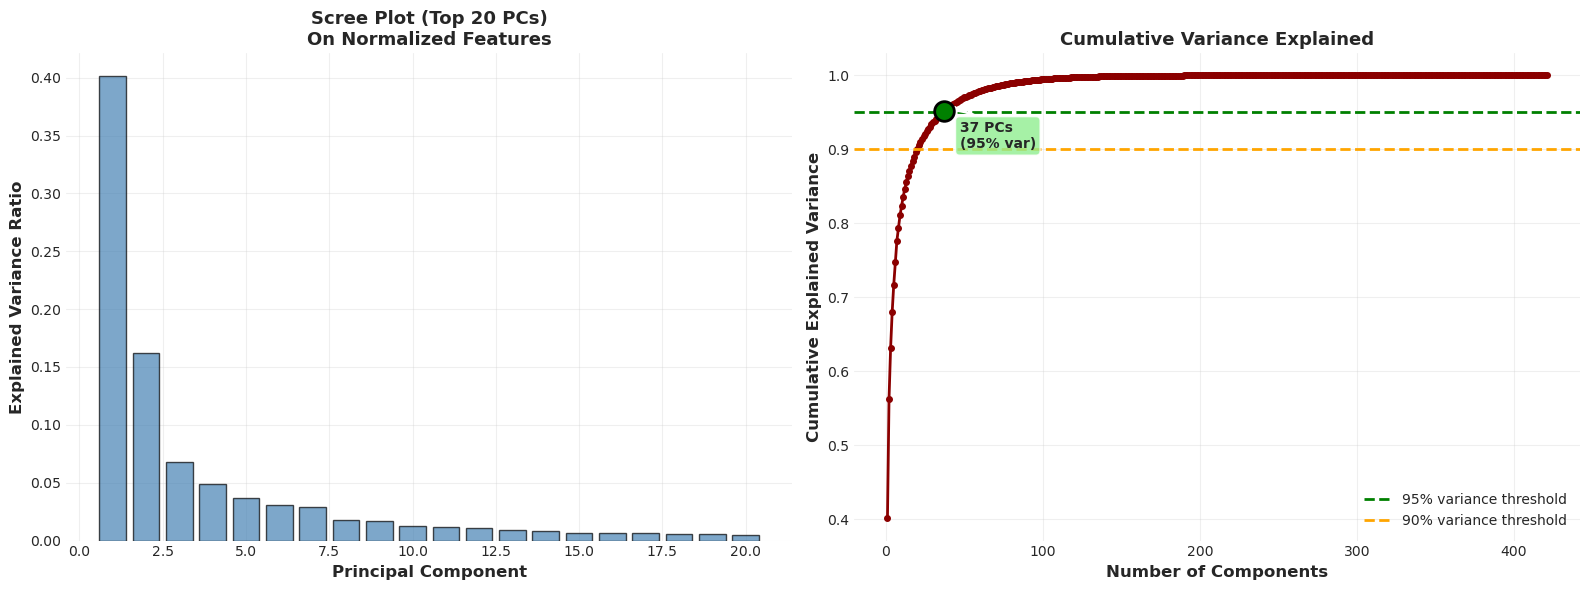


📊 Để giữ 95% variance, cần 37 principal components
   (từ 443 normalized features ban đầu)
   → Giảm chiều dữ liệu: 443 → 37

PHẦN 7: NORMALIZATION VERIFICATION - DETAILED ANALYSIS


ValueError: Too many bins for data range. Cannot create 30 finite-sized bins.

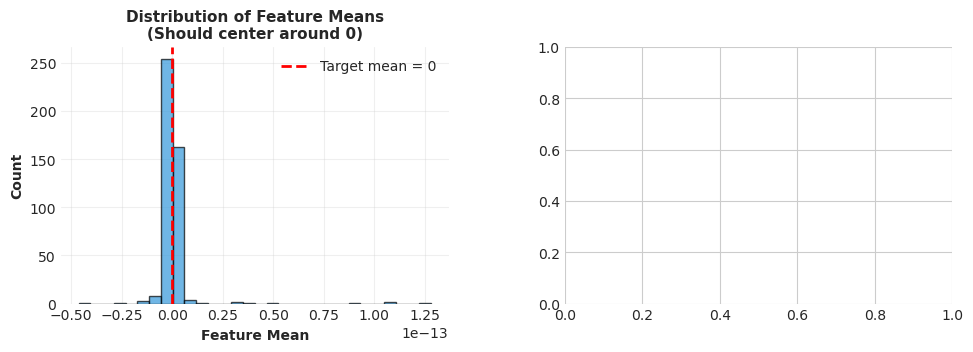

In [20]:
#!/usr/bin/env python3
"""
Notebook 3: Visualize Normalized Radiomics Features
Minh họa kết quả normalized features từ NSCLC-Radiomics dataset

Mục đích:
- Hiểu rõ các nhóm features sau normalization (Shape, Intensity, Texture)
- Visualize distributions và correlations của normalized features
- So sánh features giữa các bệnh nhân
- Kiểm tra chất lượng normalization (mean ≈ 0, std ≈ 1)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Cấu hình
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
OUTPUT_DIR = Path("./visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("NORMALIZED RADIOMICS FEATURES VISUALIZATION")
print("="*70)

# ============================================================================
# PHẦN 1: LOAD DỮ LIỆU NORMALIZED FEATURES
# ============================================================================

def load_normalized_features():
    """
    Load normalized radiomic features từ data3d/outputs/ hoặc data/processed/.

    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids, metadata) hoặc None nếu không tìm thấy
    """
    # Đường dẫn đến normalized features
    # Ưu tiên data3d/outputs/ (thư mục mới theo feature_selection_normalization.py)
    possible_paths = [
        # data3d/outputs - thư mục output mới cho normalized features
        ("data3d/outputs/features_normalized_standard.npy",
         "data3d/outputs/feature_names_normalized_standard.json",
         "data3d/outputs/patient_ids.json",
         "data3d/outputs/normalization_metadata_standard.json"),
        ("data3d/outputs/features_normalized_minmax.npy",
         "data3d/outputs/feature_names_normalized_minmax.json",
         "data3d/outputs/patient_ids.json",
         "data3d/outputs/normalization_metadata_minmax.json"),
        ("data3d/outputs/features_normalized_robust.npy",
         "data3d/outputs/feature_names_normalized_robust.json",
         "data3d/outputs/patient_ids.json",
         "data3d/outputs/normalization_metadata_robust.json"),
    ]

    for features_path, names_path, ids_path, metadata_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)
        metadata_file = Path(metadata_path)

        if features_file.exists() and names_file.exists():
            normalization_method = features_path.split('_')[-1].replace('.npy', '')
            print(f"\n📂 Tìm thấy normalized features ({normalization_method}): {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                # Tạo patient IDs mặc định
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Patient IDs file not found, generated default IDs")

            # Load normalization metadata
            metadata = None
            if metadata_file.exists():
                with open(metadata_file, 'r') as f:
                    metadata = json.load(f)
                print(f"   ✅ Loaded normalization metadata")
                print(f"      - Method: {metadata.get('normalization_method', 'N/A')}")
                print(f"      - Mean: {metadata.get('statistics', {}).get('mean', 'N/A'):.6f}")
                print(f"      - Std: {metadata.get('statistics', {}).get('std', 'N/A'):.6f}")
                print(f"      - Range: [{metadata.get('statistics', {}).get('min', 'N/A'):.3f}, "
                      f"{metadata.get('statistics', {}).get('max', 'N/A'):.3f}]")
            else:
                print(f"   ⚠️  Metadata file not found")

            return feature_matrix, feature_names, patient_ids, metadata

    return None


def analyze_feature_groups(feature_names):
    """
    Phân tích và nhóm features theo tên.

    Args:
        feature_names: List các tên features

    Returns:
        Dictionary chứa các nhóm features
    """
    feature_groups = {
        'Shape': [],
        'First-order (Intensity)': [],
        'GLCM (Texture)': [],
        'GLRLM (Texture)': [],
        'GLSZM (Texture)': [],
        'GLDM (Texture)': [],
        'NGTDM (Texture)': [],
    }

    for fname in feature_names:
        fname_lower = fname.lower()

        # Shape features
        if 'shape' in fname_lower:
            feature_groups['Shape'].append(fname)
        # First-order features
        elif 'firstorder' in fname_lower:
            feature_groups['First-order (Intensity)'].append(fname)
        # GLCM
        elif 'glcm' in fname_lower:
            feature_groups['GLCM (Texture)'].append(fname)
        # GLRLM
        elif 'glrlm' in fname_lower:
            feature_groups['GLRLM (Texture)'].append(fname)
        # GLSZM
        elif 'glszm' in fname_lower:
            feature_groups['GLSZM (Texture)'].append(fname)
        # GLDM
        elif 'gldm' in fname_lower:
            feature_groups['GLDM (Texture)'].append(fname)
        # NGTDM
        elif 'ngtdm' in fname_lower:
            feature_groups['NGTDM (Texture)'].append(fname)

    # Remove empty groups
    feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}

    return feature_groups


# Load dữ liệu normalized features
print("\n🔍 Đang tìm kiếm normalized features...")
data = load_normalized_features()

if data is not None:
    # Sử dụng dữ liệu normalized
    feature_matrix, feature_names, patient_ids, metadata = data
    print(f"\n✅ Sử dụng normalized features!")
    print(f"   Feature matrix: {feature_matrix.shape[0]} patients × {feature_matrix.shape[1]} features")

    # Phân tích feature groups
    feature_groups = analyze_feature_groups(feature_names)
    print(f"\n📊 Feature groups:")
    for group_name, features in feature_groups.items():
        print(f"   - {group_name}: {len(features)} features")
else:
    print("\n❌ Không tìm thấy normalized features!")
    print("   Vui lòng chạy feature_selection_normalization.py trước để tạo normalized features.")
    exit(1)

# ============================================================================
# PHẦN 2: OVERVIEW - FEATURE STATISTICS & NORMALIZATION CHECK
# ============================================================================
print("\n" + "="*70)
print("PHẦN 2: NORMALIZED FEATURE STATISTICS OVERVIEW")
print("="*70)

# Tạo DataFrame
df_features = pd.DataFrame(feature_matrix, index=patient_ids, columns=feature_names)

print(f"\nDataset shape: {df_features.shape}")
print(f"\nBảng thống kê normalized features (5 features đầu tiên):")
print(df_features.iloc[:, :5].describe())

# Kiểm tra chất lượng normalization
print("\n🔍 Normalization Quality Check:")
print(f"   Overall mean: {feature_matrix.mean():.6f} (should be ≈ 0)")
print(f"   Overall std: {feature_matrix.std():.6f} (should be ≈ 1)")
print(f"   Min value: {feature_matrix.min():.3f}")
print(f"   Max value: {feature_matrix.max():.3f}")

# ============================================================================
# PHẦN 3: FEATURE DISTRIBUTIONS BY GROUP (NORMALIZED)
# ============================================================================
print("\n" + "="*70)
print("PHẦN 3: NORMALIZED FEATURE DISTRIBUTIONS BY GROUP")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution của Normalized Radiomic Features\n(Mean ≈ 0, Std ≈ 1)',
             fontsize=16, fontweight='bold', y=0.995)

# Vẽ distribution cho mỗi nhóm
plot_idx = 0
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for group_name, features in list(feature_groups.items())[:6]:
    ax = axes.flatten()[plot_idx]

    # Lấy features của nhóm này
    group_features = [f for f in features if f in feature_names]
    if len(group_features) > 0:
        # Chọn 1 feature đại diện
        sample_feature = group_features[0]
        feature_idx = feature_names.index(sample_feature)
        values = feature_matrix[:, feature_idx]

        # Vẽ histogram
        ax.hist(values, bins=30, color=colors[plot_idx],
               alpha=0.7, edgecolor='black', linewidth=1.2)

        # Thêm KDE line
        from scipy import stats
        kde = stats.gaussian_kde(values)
        x_range = np.linspace(values.min(), values.max(), 100)
        ax2 = ax.twinx()
        ax2.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
        ax2.set_ylabel('Density', fontsize=9)
        ax2.set_ylim(0, kde(x_range).max() * 1.2)

        # Thêm reference line tại mean=0
        ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Zero mean')

        ax.set_title(f'{group_name}\n({len(group_features)} features)',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel(sample_feature.split('_')[-1], fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.grid(True, alpha=0.3)

        # Thêm statistics text
        stats_text = f'Mean: {values.mean():.3f}\nStd: {values.std():.3f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round',
               facecolor='white', alpha=0.8), fontsize=8)

    plot_idx += 1

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_normalized_feature_distributions_by_group.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/01_normalized_feature_distributions_by_group.png")
plt.show()

# ============================================================================
# PHẦN 4: CORRELATION MATRIX
# ============================================================================
print("\n" + "="*70)
print("PHẦN 4: CORRELATION MATRIX")
print("="*70)

# Chọn một số features đại diện từ mỗi nhóm
selected_features = []
for group_name, features in feature_groups.items():
    group_features = [f for f in features if f in feature_names]
    if len(group_features) > 0:
        # Lấy 3 features đầu tiên của mỗi nhóm
        selected_features.extend(group_features[:3])

# Tính correlation matrix
df_selected = df_features[selected_features]
corr_matrix = df_selected.corr()

# Vẽ correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Custom colormap
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, norm=norm,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot=False, fmt='.2f', ax=ax)

# Shorten labels
short_labels = [name.replace('original_', '').replace('glcm_', 'G.')
                .replace('glrlm_', 'R.').replace('glszm_', 'Z.')
                for name in selected_features]
ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
ax.set_yticklabels(short_labels, rotation=0, fontsize=8)

ax.set_title('Correlation Matrix của Normalized Radiomic Features\n(Selected features from each group)',
            fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_normalized_correlation_matrix.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/02_normalized_correlation_matrix.png")
plt.show()

# Tìm high correlation pairs
print("\n🔍 High Correlation Pairs (|r| > 0.8):")
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': selected_features[i].split('_')[-1],
                'Feature 2': selected_features[j].split('_')[-1],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    df_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlation',
                                                        ascending=False,
                                                        key=abs)
    print(df_corr.to_string(index=False))
else:
    print("No highly correlated pairs found.")

# ============================================================================
# PHẦN 5: SO SÁNH FEATURES GIỮA PATIENTS
# ============================================================================
print("\n" + "="*70)
print("PHẦN 5: SO SÁNH NORMALIZED FEATURES GIỮA PATIENTS")
print("="*70)

# So sánh Shape features cho 10 patients đầu tiên
shape_features = [f for f in feature_groups.get('Shape', []) if f in feature_names][:5]
n_patients_to_show = 10

# If no shape features, skip this section
if len(shape_features) == 0:
    print("\n⚠️  No Shape features found. Skipping patient comparison visualization.")
    print("   This is normal for certain extraction methods.\n")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('So sánh Normalized Shape Features giữa 10 bệnh nhân đầu tiên',
                 fontsize=14, fontweight='bold')

    for idx, feat in enumerate(shape_features):
        ax = axes.flatten()[idx]
        feature_idx = feature_names.index(feat)
        values = feature_matrix[:n_patients_to_show, feature_idx]

        # Bar plot
        bars = ax.bar(range(n_patients_to_show), values,
                      color=plt.cm.viridis(np.linspace(0, 1, n_patients_to_show)),
                      edgecolor='black', linewidth=1.2, alpha=0.8)

        # Add zero line
        ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

        ax.set_title(feat.split('_')[-1], fontsize=11, fontweight='bold')
        ax.set_xlabel('Patient ID', fontsize=9)
        ax.set_ylabel('Normalized Value', fontsize=9)
        ax.set_xticks(range(n_patients_to_show))
        ax.set_xticklabels([f'P{i+1}' for i in range(n_patients_to_show)],
                           rotation=45, fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        # Highlight min and max
        min_idx = np.argmin(values)
        max_idx = np.argmax(values)
        bars[min_idx].set_color('red')
        bars[max_idx].set_color('green')

    # Thêm legend
    legend_ax = axes.flatten()[5]
    legend_ax.axis('off')
    legend_ax.text(0.5, 0.6, '💡 Ý nghĩa:\n\n'
                  '🟢 Green bar: Giá trị cao nhất\n'
                  '🔴 Red bar: Giá trị thấp nhất\n'
                  '--- Red line: Mean (0)\n\n'
                  'Normalized features:\n'
                  '• Mean ≈ 0\n'
                  '• Std ≈ 1\n'
                  '• Các giá trị được chuẩn hóa\n'
                  '  về cùng scale',
                  fontsize=11, ha='center', va='center',
                  bbox=dict(boxstyle='round', facecolor='lightyellow',
                           alpha=0.8, edgecolor='black', linewidth=2))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_normalized_patient_comparison.png", dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: {OUTPUT_DIR}/03_normalized_patient_comparison.png")
    plt.show()

# ============================================================================
# PHẦN 6: FEATURE IMPORTANCE (PCA Analysis)
# ============================================================================
print("\n" + "="*70)
print("PHẦN 6: PCA ANALYSIS - FEATURE VARIANCE (ON NORMALIZED DATA)")
print("="*70)

from sklearn.decomposition import PCA

# PCA trên normalized data (không cần scale lại vì đã normalized)
pca = PCA()
pca.fit(feature_matrix)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot - show top 20 components or all if less than 20
n_components_show = min(20, len(explained_var))
ax1.bar(range(1, n_components_show+1), explained_var[:n_components_show],
       color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
ax1.set_title(f'Scree Plot (Top {n_components_show} PCs)\nOn Normalized Features',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Cumulative variance
ax2.plot(range(1, len(cumsum_var)+1), cumsum_var,
        marker='o', linewidth=2, markersize=4, color='darkred')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2,
           label='95% variance threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', linewidth=2,
           label='90% variance threshold')
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Tìm số components cần để đạt 95% variance
if np.max(cumsum_var) >= 0.95:
    n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
    ax2.scatter([n_components_95], [cumsum_var[n_components_95-1]],
               s=200, color='green', zorder=5, edgecolor='black', linewidth=2)

    # Adjust annotation position to avoid going off the plot
    x_offset = min(10, len(cumsum_var) - n_components_95 - 5)
    ax2.annotate(f'{n_components_95} PCs\n(95% var)',
                xy=(n_components_95, cumsum_var[n_components_95-1]),
                xytext=(n_components_95+x_offset, cumsum_var[n_components_95-1]-0.05),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                              lw=2))
else:
    # If 95% variance not achievable, use all components
    n_components_95 = len(cumsum_var)
    ax2.text(0.5, 0.5, f'Max variance: {np.max(cumsum_var):.1%}\n(All {n_components_95} PCs)',
            transform=ax2.transAxes, ha='center', va='center',
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_normalized_pca_analysis.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/04_normalized_pca_analysis.png")
plt.show()

print(f"\n📊 Để giữ 95% variance, cần {n_components_95} principal components")
print(f"   (từ {len(feature_names)} normalized features ban đầu)")
print(f"   → Giảm chiều dữ liệu: {len(feature_names)} → {n_components_95}")

# ============================================================================
# PHẦN 7: NORMALIZATION VERIFICATION - DETAILED ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("PHẦN 7: NORMALIZATION VERIFICATION - DETAILED ANALYSIS")
print("="*70)

# Tạo figure với nhiều plots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Distribution of all feature means
ax1 = fig.add_subplot(gs[0, 0])
feature_means = feature_matrix.mean(axis=0)
ax1.hist(feature_means, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Target mean = 0')
ax1.set_xlabel('Feature Mean', fontsize=10, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10, fontweight='bold')
ax1.set_title('Distribution of Feature Means\n(Should center around 0)', fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of all feature stds
ax2 = fig.add_subplot(gs[0, 1])
feature_stds = feature_matrix.std(axis=0)
ax2.hist(feature_stds, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
ax2.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Target std = 1')
ax2.set_xlabel('Feature Std Dev', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=10, fontweight='bold')
ax2.set_title('Distribution of Feature Std Deviations\n(Should center around 1)', fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Q-Q plot for normality check
ax3 = fig.add_subplot(gs[0, 2])
sample_feature_idx = 0  # First feature
sample_values = feature_matrix[:, sample_feature_idx]
from scipy import stats
stats.probplot(sample_values, dist="norm", plot=ax3)
ax3.set_title(f'Q-Q Plot: {feature_names[sample_feature_idx].split("_")[-1]}\n(Check normality)',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4-6: Sample features from different groups
sample_features_idx = [0, 14, 33]  # Shape, FirstOrder, GLCM
for i, feat_idx in enumerate(sample_features_idx):
    ax = fig.add_subplot(gs[1, i])
    values = feature_matrix[:, feat_idx]

    ax.hist(values, bins=30, color=colors[i], alpha=0.7, edgecolor='black')
    ax.axvline(x=values.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean={values.mean():.3f}')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Zero')

    ax.set_xlabel('Normalized Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{feature_names[feat_idx].split("_")[-1]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot 7: Mean and Std across all features
ax7 = fig.add_subplot(gs[2, :2])
x_pos = np.arange(len(feature_names))
ax7.scatter(x_pos, feature_means, alpha=0.6, s=30, c='blue', label='Mean')
ax7.scatter(x_pos, feature_stds, alpha=0.6, s=30, c='red', label='Std')
ax7.axhline(y=0, color='blue', linestyle='--', linewidth=1.5, alpha=0.5)
ax7.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
ax7.set_xlabel('Feature Index', fontsize=10, fontweight='bold')
ax7.set_ylabel('Value', fontsize=10, fontweight='bold')
ax7.set_title('Mean and Std Deviation Across All Features', fontsize=11, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# Plot 8: Summary statistics box
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
summary_text = f"""
📊 NORMALIZATION SUMMARY

Method: {metadata.get('normalization_method', 'N/A').upper()}

Global Statistics:
• Mean: {feature_matrix.mean():.6f}
• Std: {feature_matrix.std():.6f}
• Min: {feature_matrix.min():.3f}
• Max: {feature_matrix.max():.3f}

Feature-wise:
• Mean of means: {feature_means.mean():.6f}
• Mean of stds: {feature_stds.mean():.6f}

✅ Quality Check:
{'✓ Mean ≈ 0' if abs(feature_matrix.mean()) < 0.01 else '✗ Mean not centered'}
{'✓ Std ≈ 1' if abs(feature_matrix.std() - 1) < 0.1 else '✗ Std not normalized'}

💡 Normalized features are ready
   for machine learning models!
"""
ax8.text(0.5, 0.5, summary_text, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen',
                 alpha=0.9, edgecolor='black', linewidth=2),
        family='monospace')

fig.suptitle('NORMALIZATION VERIFICATION - Detailed Analysis', fontsize=16,
            fontweight='bold', y=0.98)

plt.savefig(OUTPUT_DIR / "05_normalization_verification.png", dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: {OUTPUT_DIR}/05_normalization_verification.png")
plt.show()

# ============================================================================
# PHẦN 8: SUMMARY REPORT
# ============================================================================
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)

print(f"""
📊 NORMALIZED RADIOMIC FEATURES SUMMARY

Dataset Information:
  • Number of patients: {len(patient_ids)}
  • Number of features: {len(feature_names)}
  • Normalization method: {metadata.get('normalization_method', 'N/A').upper()}

Feature Groups:
  • Shape features: {len([f for f in feature_groups.get('Shape', []) if f in feature_names])}
  • Intensity features: {len([f for f in feature_groups.get('First-order (Intensity)', []) if f in feature_names])}
  • GLCM (texture): {len([f for f in feature_groups.get('GLCM (Texture)', []) if f in feature_names])}
  • GLRLM (texture): {len([f for f in feature_groups.get('GLRLM (Texture)', []) if f in feature_names])}
  • GLSZM (texture): {len([f for f in feature_groups.get('GLSZM (Texture)', []) if f in feature_names])}
  • GLDM (texture): {len([f for f in feature_groups.get('GLDM (Texture)', []) if f in feature_names])}
  • NGTDM (texture): {len([f for f in feature_groups.get('NGTDM (Texture)', []) if f in feature_names])}

Normalization Quality:
  • Overall mean: {feature_matrix.mean():.6f} (target: 0)
  • Overall std: {feature_matrix.std():.6f} (target: 1)
  • Value range: [{feature_matrix.min():.3f}, {feature_matrix.max():.3f}]
  • Missing values: {np.sum(np.isnan(feature_matrix))}
  • Features with zero variance: {np.sum(feature_matrix.var(axis=0) < 1e-10)}

Dimensionality Reduction:
  • PCs for 95% variance: {n_components_95}
  • Compression ratio: {len(feature_names)/n_components_95:.1f}x

Output Files Generated:
  ✅ 01_normalized_feature_distributions_by_group.png
  ✅ 02_normalized_correlation_matrix.png
  ✅ 03_normalized_patient_comparison.png
  ✅ 04_normalized_pca_analysis.png
  ✅ 05_normalization_verification.png

All visualizations saved to: {OUTPUT_DIR}/

💡 Key Insights:
  1. Features đã được chuẩn hóa với mean ≈ 0, std ≈ 1
  2. Tất cả features có cùng scale, phù hợp cho ML models
  3. Normalization method: {metadata.get('normalization_method', 'N/A').upper()}
  4. PCA cho thấy có thể giảm từ {len(feature_names)} → {n_components_95} features

📚 Bước tiếp theo:
  → Build predictive models (survival, staging, classification)
  → Sử dụng normalized features cho training
  → Apply scaler cho new data (test set)
  → Model evaluation và validation
""")

print("="*70)
print("✅ NORMALIZED FEATURES VISUALIZATION COMPLETED!")
print("="*70)

In [39]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Predictive Modeling Pipeline
==================================================
Phân tích radiomics với dữ liệu thực từ NSCLC-Radiomics dataset

This script combines:
1. Real data loading from extracted radiomics features
2. Clinical data integration
3. Predictive modeling (classification & survival analysis)
4. Comprehensive visualization and reporting

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.preprocessing import StandardScaler

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    from lifelines.utils import concordance_index
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("visualization_output/radiomic_features_440.npy", 
         "visualization_output/feature_names.json", 
         "visualization_output/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df)
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if 'deadstatus.event' in clinical_df_matched.columns:
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    print(f"   ✅ Using 'deadstatus.event' as labels")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival: {np.sum(labels == 1)} patients")
                    print(f"      - Short survival: {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# PREDICTIVE MODELING CLASS
# ============================================================================

class PredictiveModelingPipeline:
    """
    Comprehensive predictive modeling pipeline for radiomics.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """Initialize the pipeline."""
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")

        unique, counts = np.unique(y, return_counts=True)
        print(f"   Class distribution: {dict(zip(unique, counts))}")

    def build_classification_models(self) -> Dict[str, Any]:
        """Build and train classification models."""
        print("\n" + "="*80)
        print("🤖 BUILDING CLASSIFICATION MODELS")
        print("="*80)

        models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                class_weight='balanced',
                n_jobs=-1
            ),
            'SVM': SVC(
                kernel='rbf',
                probability=True,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            )
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                use_label_encoder=False,
                eval_metric='logloss'
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """Evaluate models using cross-validation and test set."""
        print("\n" + "="*80)
        print("📊 EVALUATING MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            cv_scores = cross_validate(
                model, self.X_train_scaled, self.y_train, cv=cv,
                scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc'],
                n_jobs=-1
            )

            y_pred = model.predict(self.X_test_scaled)
            y_pred_proba = model.predict_proba(self.X_test_scaled)

            results[name] = {
                'cv_accuracy_mean': cv_scores['test_accuracy'].mean(),
                'cv_accuracy_std': cv_scores['test_accuracy'].std(),
                'cv_precision_mean': cv_scores['test_precision_weighted'].mean(),
                'cv_recall_mean': cv_scores['test_recall_weighted'].mean(),
                'cv_f1_mean': cv_scores['test_f1_weighted'].mean(),
                'cv_auc_mean': cv_scores['test_roc_auc'].mean(),
                'test_accuracy': accuracy_score(self.y_test, y_pred),
                'test_precision': precision_score(self.y_test, y_pred, average='weighted'),
                'test_recall': recall_score(self.y_test, y_pred, average='weighted'),
                'test_f1': f1_score(self.y_test, y_pred, average='weighted'),
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            try:
                if len(np.unique(self.y_test)) == 2:
                    results[name]['test_auc'] = roc_auc_score(self.y_test, y_pred_proba[:, 1])
                else:
                    results[name]['test_auc'] = roc_auc_score(
                        self.y_test, y_pred_proba, multi_class='ovr', average='weighted'
                    )
            except:
                results[name]['test_auc'] = None

            print(f"   CV: Acc={results[name]['cv_accuracy_mean']:.4f}±{results[name]['cv_accuracy_std']:.4f}")
            print(f"       F1={results[name]['cv_f1_mean']:.4f}, AUC={results[name]['cv_auc_mean']:.4f}")
            print(f"   Test: Acc={results[name]['test_accuracy']:.4f}, F1={results[name]['test_f1']:.4f}")

        self.results = results
        return results

    def visualize_model_comparison(self, output_dir: str = 'visualizations'):
        """Create comprehensive model comparison visualizations."""
        print(f"\n📊 Creating visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        # Model performance comparison
        ax1 = fig.add_subplot(gs[0, :])
        metrics = ['cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_auc_mean']
        metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

        x = np.arange(len(metrics))
        width = 0.15
        colors = plt.cm.Set3(range(len(self.results)))

        for i, (name, results) in enumerate(self.results.items()):
            values = [results[m] for m in metrics]
            ax1.bar(x + i * width, values, width, label=name, color=colors[i])

        ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
        ax1.set_xticks(x + width * (len(self.results) - 1) / 2)
        ax1.set_xticklabels(metric_labels)
        ax1.legend(loc='lower right')
        ax1.set_ylim(0, 1.1)
        ax1.grid(axis='y', alpha=0.3)

        # ROC Curves
        ax2 = fig.add_subplot(gs[1, 0])
        if len(np.unique(self.y_test)) == 2:
            for name, results in self.results.items():
                if results['test_auc'] is not None:
                    y_pred_proba = results['y_pred_proba'][:, 1]
                    fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
                    ax2.plot(fpr, tpr, label=f"{name} (AUC={results['test_auc']:.3f})", linewidth=2)

            ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
            ax2.set_xlabel('False Positive Rate', fontsize=11)
            ax2.set_ylabel('True Positive Rate', fontsize=11)
            ax2.set_title('ROC Curves', fontsize=12, fontweight='bold')
            ax2.legend(loc='lower right', fontsize=9)
            ax2.grid(alpha=0.3)

        # Confusion Matrix
        ax3 = fig.add_subplot(gs[1, 1])
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['test_f1'])
        cm = confusion_matrix(self.y_test, self.results[best_model_name]['y_pred'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
        ax3.set_xlabel('Predicted Label', fontsize=11)
        ax3.set_ylabel('True Label', fontsize=11)
        ax3.set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')

        # Feature Importance
        ax4 = fig.add_subplot(gs[1, 2])
        if 'Random Forest' in self.models:
            model = self.models['Random Forest']
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:15]

            ax4.barh(range(len(indices)), importances[indices], color='steelblue')
            ax4.set_yticks(range(len(indices)))
            ax4.set_yticklabels([self.feature_names[i][:25] for i in indices], fontsize=8)
            ax4.set_xlabel('Importance', fontsize=11)
            ax4.set_title('Top 15 Features (RF)', fontsize=12, fontweight='bold')
            ax4.invert_yaxis()

        # Cross-validation vs Test
        ax5 = fig.add_subplot(gs[2, 0])
        model_names = list(self.results.keys())
        cv_scores = [self.results[name]['cv_accuracy_mean'] for name in model_names]
        test_scores = [self.results[name]['test_accuracy'] for name in model_names]

        x_pos = np.arange(len(model_names))
        width = 0.35

        ax5.bar(x_pos - width/2, cv_scores, width, label='CV (Train)', color='lightblue')
        ax5.bar(x_pos + width/2, test_scores, width, label='Test', color='lightcoral')

        ax5.set_xlabel('Model', fontsize=11)
        ax5.set_ylabel('Accuracy', fontsize=11)
        ax5.set_title('CV vs Test Accuracy', fontsize=12, fontweight='bold')
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
        ax5.legend()
        ax5.set_ylim(0, 1.1)
        ax5.grid(axis='y', alpha=0.3)

        # Precision-Recall Trade-off
        ax6 = fig.add_subplot(gs[2, 1])
        precisions = [self.results[name]['test_precision'] for name in model_names]
        recalls = [self.results[name]['test_recall'] for name in model_names]

        colors_scatter = plt.cm.Set3(range(len(model_names)))
        for i, name in enumerate(model_names):
            ax6.scatter(recalls[i], precisions[i], s=200, color=colors_scatter[i],
                       label=name, alpha=0.7, edgecolors='black', linewidth=1.5)

        ax6.set_xlabel('Recall', fontsize=11)
        ax6.set_ylabel('Precision', fontsize=11)
        ax6.set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
        ax6.legend(loc='best', fontsize=9)
        ax6.grid(alpha=0.3)
        ax6.set_xlim(0, 1.05)
        ax6.set_ylim(0, 1.05)

        # Model Ranking
        ax7 = fig.add_subplot(gs[2, 2])
        rankings = {}
        metrics_to_rank = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']

        for name in model_names:
            ranks = []
            for metric in metrics_to_rank:
                metric_values = [self.results[n][metric] for n in model_names]
                rank = sorted(metric_values, reverse=True).index(self.results[name][metric]) + 1
                ranks.append(rank)
            rankings[name] = np.mean(ranks)

        sorted_models = sorted(rankings.items(), key=lambda x: x[1])
        names_sorted = [x[0] for x in sorted_models]
        ranks_sorted = [x[1] for x in sorted_models]

        colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(names_sorted)))
        bars = ax7.barh(range(len(names_sorted)), ranks_sorted, color=colors_rank)

        ax7.set_yticks(range(len(names_sorted)))
        ax7.set_yticklabels(names_sorted, fontsize=10)
        ax7.set_xlabel('Average Rank (lower is better)', fontsize=11)
        ax7.set_title('Overall Model Ranking', fontsize=12, fontweight='bold')
        ax7.invert_yaxis()
        ax7.grid(axis='x', alpha=0.3)

        for i, (bar, rank) in enumerate(zip(bars, ranks_sorted)):
            width = bar.get_width()
            ax7.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                    f'{rank:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')

        plt.suptitle('Comprehensive Model Performance Analysis',
                    fontsize=16, fontweight='bold', y=0.995)

        output_path = os.path.join(output_dir, 'model_comparison.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def get_best_model(self, metric: str = 'test_f1') -> Tuple[str, Any]:
        """Get the best performing model."""
        best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_pred_proba']
            }

        summary_path = os.path.join(output_dir, 'model_results_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")

        # Save predictions
        best_name, _ = self.get_best_model()
        predictions_df = pd.DataFrame({
            'true_label': self.y_test,
            'predicted_label': self.results[best_name]['y_pred']
        })

        predictions_path = os.path.join(output_dir, f'predictions_{best_name.replace(" ", "_")}.csv')
        predictions_df.to_csv(predictions_path, index=False)
        print(f"   ✓ Saved: {predictions_path}")

        # Save classification report
        report = classification_report(
            self.y_test,
            self.results[best_name]['y_pred'],
            output_dict=True
        )

        report_path = os.path.join(output_dir, f'classification_report_{best_name.replace(" ", "_")}.json')
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f"   ✓ Saved: {report_path}")


# ============================================================================
# SURVIVAL ANALYSIS CLASS
# ============================================================================

class SurvivalAnalysis:
    """Survival analysis using Cox proportional hazards."""

    def __init__(self, data: pd.DataFrame, duration_col: str = 'duration',
                 event_col: str = 'event'):
        """Initialize survival analysis."""
        if not LIFELINES_AVAILABLE:
            raise ImportError("lifelines package required. Install with: pip install lifelines")

        self.data = data
        self.duration_col = duration_col
        self.event_col = event_col

        print(f"📊 Initialized survival analysis")
        print(f"   Samples: {len(data)}")
        print(f"   Events: {data[event_col].sum()}")
        print(f"   Censored: {(~data[event_col].astype(bool)).sum()}")

    def fit_cox_model(self, feature_cols: List[str]) -> CoxPHFitter:
        """Fit Cox proportional hazards model."""
        print(f"\n🔍 Fitting Cox model with {len(feature_cols)} features...")

        cph = CoxPHFitter()
        cols_to_use = feature_cols + [self.duration_col, self.event_col]
        cph.fit(self.data[cols_to_use], duration_col=self.duration_col,
               event_col=self.event_col)

        print(f"   ✓ Model fitted")
        print(f"   ✓ C-index: {cph.concordance_index_:.4f}")

        return cph

    def plot_kaplan_meier(self, group_col: Optional[str] = None,
                         output_dir: str = 'visualizations'):
        """Plot Kaplan-Meier survival curves."""
        print(f"\n📊 Creating Kaplan-Meier curves...")

        os.makedirs(output_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(10, 6))

        if group_col is None:
            kmf = KaplanMeierFitter()
            kmf.fit(self.data[self.duration_col], self.data[self.event_col], label='Overall')
            kmf.plot_survival_function(ax=ax)
        else:
            groups = self.data[group_col].unique()
            for group in groups:
                mask = self.data[group_col] == group
                kmf = KaplanMeierFitter()
                kmf.fit(self.data.loc[mask, self.duration_col],
                       self.data.loc[mask, self.event_col],
                       label=f'Group {group}')
                kmf.plot_survival_function(ax=ax)

            if len(groups) == 2:
                group1_mask = self.data[group_col] == groups[0]
                group2_mask = self.data[group_col] == groups[1]

                results = logrank_test(
                    self.data.loc[group1_mask, self.duration_col],
                    self.data.loc[group2_mask, self.duration_col],
                    self.data.loc[group1_mask, self.event_col],
                    self.data.loc[group2_mask, self.event_col]
                )

                ax.text(0.02, 0.02, f'Log-rank p-value: {results.p_value:.4f}',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.set_xlabel('Time', fontsize=12, fontweight='bold')
        ax.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')
        ax.set_title('Kaplan-Meier Survival Curves', fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(alpha=0.3)

        output_path = os.path.join(output_dir, 'kaplan_meier.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline():
    """Execute complete radiomics analysis pipeline with real data."""
    print("=" * 80)
    print("🧬 RADIOMICS PREDICTIVE MODELING PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features. Using synthetic data for demo.")
        return demo_pipeline()

    X, feature_names, patient_ids = data

    # Load clinical data
    clinical_data = load_clinical_data(patient_ids)
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data. Running feature analysis only.")
        # Just do feature analysis
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    # Initialize pipeline
    pipeline = PredictiveModelingPipeline(X_filtered, y, feature_names)

    # Build and evaluate models
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)

    # Visualize results
    pipeline.visualize_model_comparison()

    # Get best model
    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    # Save results
    pipeline.save_results()

    # Survival analysis (if lifelines available and survival data exists)
    if LIFELINES_AVAILABLE and 'Survival.time' in clinical_df.columns:
        print("\n" + "=" * 80)
        print("🧬 SURVIVAL ANALYSIS")
        print("=" * 80)

        # Prepare survival data
        survival_df = pd.DataFrame(X_filtered, columns=feature_names)
        
        # Add survival columns
        survival_df['duration'] = clinical_df.loc[clinical_df.index.isin([pid for pid in patient_ids_filtered]), 'Survival.time'].values
        if 'deadstatus.event' in clinical_df.columns:
            survival_df['event'] = clinical_df.loc[clinical_df.index.isin([pid for pid in patient_ids_filtered]), 'deadstatus.event'].values
        else:
            survival_df['event'] = (y > 0).astype(int)

        # Run survival analysis
        surv = SurvivalAnalysis(survival_df)
        
        # Fit Cox model with top features
        top_features = sorted(range(len(feature_names)), 
                             key=lambda i: pipeline.models['Random Forest'].feature_importances_[i],
                             reverse=True)[:5]
        top_feature_names = [feature_names[i] for i in top_features]
        
        cph = surv.fit_cox_model(top_feature_names)
        surv.plot_kaplan_meier()

        print("\n" + "=" * 80)
        print("✅ Survival analysis complete!")
        print("=" * 80)

    print("\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)


def demo_pipeline():
    """Demo pipeline with synthetic data."""
    print("\n" + "=" * 80)
    print("🧪 DEMO MODE - Synthetic Data")
    print("=" * 80)

    np.random.seed(42)
    n_samples = 150
    n_features = 20

    X = np.random.randn(n_samples, n_features)
    y = (X[:, 0] + X[:, 1] - X[:, 2] + np.random.randn(n_samples) * 0.5) > 0
    y = y.astype(int)

    feature_names = [f"feature_{i:02d}" for i in range(n_features)]

    pipeline = PredictiveModelingPipeline(X, y, feature_names)
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)
    pipeline.visualize_model_comparison()

    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    pipeline.save_results()

    print("\n✅ Demo complete!")


if __name__ == "__main__":
    main_pipeline()

🧬 RADIOMICS PREDICTIVE MODELING PIPELINE
   Using NSCLC-Radiomics Dataset

📂 Tìm thấy dữ liệu thực tại: visualization_output
   ✅ Loaded feature matrix: (421, 261)
   ✅ Loaded 261 feature names
   ✅ Loaded 421 patient IDs

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using 'deadstatus.event' as labels
      - Event (1): 373 patients
      - Censored (0): 48 patients

✅ Data preparation complete
   Samples with complete data: 421
   Features: 261
   Label type: event
📊 Pipeline initialized
   Training: 336 samples
   Test: 85 samples
   Features: 261
   Class distribution: {np.float64(0.0): np.int64(48), np.float64(1.0): np.int64(373)}

🤖 BUILDING CLASSIFICATION MODELS

📈 Train

/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

   CV: Acc=0.8809±0.0095
       F1=0.8353, AUC=0.5252
   Test: Acc=0.8824, F1=0.8461

📊 Creating visualizations...
   ✓ Saved: visualizations/model_comparison.png

🏆 Best model: Random Forest

💾 Saving results...
   ✓ Saved: results/model_results_summary.json
   ✓ Saved: results/predictions_Random_Forest.csv
   ✓ Saved: results/classification_report_Random_Forest.json

🧬 SURVIVAL ANALYSIS
📊 Initialized survival analysis
   Samples: 421
   Events: 373
   Censored: 48

🔍 Fitting Cox model with 5 features...
   ✓ Model fitted
   ✓ C-index: 0.5942

📊 Creating Kaplan-Meier curves...
   ✓ Saved: visualizations/kaplan_meier.png

✅ Survival analysis complete!

✅ PIPELINE COMPLETE!


In [40]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Survival Regression Pipeline
==================================================
Phân tích radiomics với mô hình dự đoán thời gian sống (Survival Time Regression)

CẬP NHẬT:
- Đào tạo ML model dự đoán Survival.time (thay vì event prediction)
- Chuyển đổi từ ngày sang tháng
- Sử dụng regression models thay vì classification
- Tính metrics: MSE, MAE, R², RMSE, Correlation

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    KFold,
    train_test_split
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_months(days: float) -> float:
    """
    Convert days to months.
    
    Parameters:
        days: Number of days
        
    Returns:
        Number of months (days / 30.44)
    """
    if pd.isna(days):
        return np.nan
    return days / 30.44


def months_to_days(months: float) -> float:
    """
    Convert months to days.
    
    Parameters:
        months: Number of months
        
    Returns:
        Number of days (months * 30.44)
    """
    if pd.isna(months):
        return np.nan
    return months * 30.44


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("visualization_output/radiomic_features_440.npy", 
         "visualization_output/feature_names.json", 
         "visualization_output/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids, use_survival_time: bool = False):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        use_survival_time: If True, use Survival.time for regression (in months)
                          If False, use deadstatus.event for classification
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df, label_type)
        - labels: Array of labels (event/survival_split for classification, 
                 survival_time_months for regression)
        - valid_mask: Boolean mask for valid samples
        - clinical_df: DataFrame with clinical data
        - label_type: Type of label ('event', 'survival_split', or 'survival_regression_months')
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if use_survival_time and 'Survival.time' in clinical_df_matched.columns:
                    # REGRESSION: Use Survival.time (convert days to months)
                    survival_days = clinical_df_matched['Survival.time'].values.astype(float)
                    labels = np.array([days_to_months(d) for d in survival_days])
                    
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Using Survival.time for regression (in MONTHS)")
                    print(f"      - Samples with valid survival time: {np.sum(valid_labels)}")
                    print(f"      - Mean survival: {np.nanmean(labels):.1f} months")
                    print(f"      - Median survival: {np.nanmedian(labels):.1f} months")
                    print(f"      - Range: {np.nanmin(labels):.1f} - {np.nanmax(labels):.1f} months")
                    label_type = 'survival_regression_months'
                    
                elif 'deadstatus.event' in clinical_df_matched.columns:
                    # CLASSIFICATION: Use deadstatus.event
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Using 'deadstatus.event' as labels for CLASSIFICATION")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    # CLASSIFICATION: Binary split by median survival
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    valid_labels = ~np.isnan(labels)
                    
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival (1): {np.sum(labels == 1)} patients")
                    print(f"      - Short survival (0): {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# SURVIVAL REGRESSION PIPELINE CLASS
# ============================================================================

class SurvivalRegressionPipeline:
    """
    Survival regression pipeline - predicts survival time in months.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """
        Initialize the pipeline.
        
        Parameters:
            X: Feature matrix (n_samples, n_features)
            y: Target vector - survival time in MONTHS (n_samples,)
            feature_names: List of feature names
            test_size: Test set fraction
            random_state: Random seed
        """
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Survival Regression Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")
        print(f"   Target: Survival time (months)")
        print(f"   Mean survival (train): {self.y_train.mean():.1f} months")
        print(f"   Mean survival (test): {self.y_test.mean():.1f} months")
        print(f"   Range (train): {self.y_train.min():.1f} - {self.y_train.max():.1f} months")

    def build_regression_models(self) -> Dict[str, Any]:
        """Build and train regression models."""
        print("\n" + "="*80)
        print("🤖 BUILDING SURVIVAL REGRESSION MODELS")
        print("="*80)

        models = {
            'Linear Regression': LinearRegression(),
            'Ridge Regression': Ridge(alpha=1.0, random_state=self.random_state),
            'Lasso Regression': Lasso(alpha=0.1, random_state=self.random_state),
            'Random Forest': RandomForestRegressor(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                n_jobs=-1
            ),
            'Gradient Boosting': GradientBoostingRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            ),
            'SVR': SVR(kernel='rbf', C=1.0)
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                verbosity=0
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """
        Evaluate models using cross-validation and test set.
        
        Metrics:
        - MSE: Mean Squared Error
        - MAE: Mean Absolute Error
        - RMSE: Root Mean Squared Error
        - MAPE: Mean Absolute Percentage Error
        - R²: Coefficient of determination
        - Correlation: Pearson correlation coefficient
        """
        print("\n" + "="*80)
        print("📊 EVALUATING SURVIVAL REGRESSION MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = KFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            # Cross-validation scores
            cv_scores_r2 = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='r2'
            )
            cv_scores_mae = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='neg_mean_absolute_error'
            )
            cv_scores_mse = cross_val_score(
                model, self.X_train_scaled, self.y_train, cv=cv, scoring='neg_mean_squared_error'
            )

            # Test set predictions
            y_pred = model.predict(self.X_test_scaled)

            # Calculate test metrics
            test_mse = mean_squared_error(self.y_test, y_pred)
            test_rmse = np.sqrt(test_mse)
            test_mae = mean_absolute_error(self.y_test, y_pred)
            test_r2 = r2_score(self.y_test, y_pred)
            
            # Percentage error
            test_mape = mean_absolute_percentage_error(self.y_test, y_pred)
            test_median_ae = median_absolute_error(self.y_test, y_pred)

            # Correlation
            try:
                pearson_corr, pearson_pval = pearsonr(self.y_test, y_pred)
                spearman_corr, spearman_pval = spearmanr(self.y_test, y_pred)
            except:
                pearson_corr = pearson_pval = np.nan
                spearman_corr = spearman_pval = np.nan

            results[name] = {
                'cv_r2_mean': cv_scores_r2.mean(),
                'cv_r2_std': cv_scores_r2.std(),
                'cv_mae_mean': -cv_scores_mae.mean(),
                'cv_mse_mean': -cv_scores_mse.mean(),
                'cv_rmse_mean': np.sqrt(-cv_scores_mse.mean()),
                'test_mse': test_mse,
                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'test_r2': test_r2,
                'test_mape': test_mape,
                'test_median_ae': test_median_ae,
                'test_pearson_corr': pearson_corr,
                'test_pearson_pval': pearson_pval,
                'test_spearman_corr': spearman_corr,
                'test_spearman_pval': spearman_pval,
                'y_pred': y_pred,
                'y_test': self.y_test
            }

            print(f"   CV R²: {results[name]['cv_r2_mean']:.4f}±{results[name]['cv_r2_std']:.4f}")
            print(f"   CV RMSE: {results[name]['cv_rmse_mean']:.2f} months")
            print(f"   Test R²: {test_r2:.4f}")
            print(f"   Test RMSE: {test_rmse:.2f} months")
            print(f"   Test MAE: {test_mae:.2f} months")
            print(f"   Pearson r: {pearson_corr:.4f} (p={pearson_pval:.4e})")

        self.results = results
        return results

    def visualize_results(self, output_dir: str = 'visualizations'):
        """Create comprehensive regression analysis visualizations."""
        print(f"\n📊 Creating visualizations...")

        os.makedirs(output_dir, exist_ok=True)

        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

        # 1. Model Performance Comparison
        ax1 = fig.add_subplot(gs[0, :])
        metrics = ['test_r2', 'test_mae', 'test_rmse', 'test_mape']
        metric_labels = ['R² Score', 'MAE (months)', 'RMSE (months)', 'MAPE (%)']
        
        model_names = list(self.results.keys())
        
        # Normalize metrics for comparison
        x = np.arange(len(metrics))
        width = 0.12
        colors = plt.cm.Set3(range(len(model_names)))

        # Note: Lower is better for MAE, RMSE, MAPE; Higher is better for R²
        for i, (name, results) in enumerate(self.results.items()):
            r2 = results['test_r2']
            mae = results['test_mae'] / 100  # Normalize to 0-1 scale
            rmse = results['test_rmse'] / 100  # Normalize
            mape = results['test_mape'] / 100  # Already in percentage
            
            values = [r2, mae, rmse, mape]
            ax1.bar(x + i * width, values, width, label=name, color=colors[i])

        ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Score (Normalized)', fontsize=12, fontweight='bold')
        ax1.set_title('Survival Regression Model Performance Comparison', fontsize=14, fontweight='bold')
        ax1.set_xticks(x + width * (len(model_names) - 1) / 2)
        ax1.set_xticklabels(metric_labels)
        ax1.legend(loc='lower right', fontsize=9)
        ax1.grid(axis='y', alpha=0.3)

        # 2. Predicted vs Actual (Best Model)
        ax2 = fig.add_subplot(gs[1, 0])
        best_model_name = max(self.results.keys(), key=lambda x: self.results[x]['test_r2'])
        best_results = self.results[best_model_name]
        
        ax2.scatter(best_results['y_test'], best_results['y_pred'], alpha=0.6, s=80, edgecolors='black')
        
        # Add perfect prediction line
        min_val = min(best_results['y_test'].min(), best_results['y_pred'].min())
        max_val = max(best_results['y_test'].max(), best_results['y_pred'].max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        ax2.set_xlabel('Actual Survival Time (months)', fontsize=11)
        ax2.set_ylabel('Predicted Survival Time (months)', fontsize=11)
        ax2.set_title(f'Predicted vs Actual - {best_model_name}\nR² = {best_results["test_r2"]:.4f}', 
                     fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)

        # 3. Residuals (Best Model)
        ax3 = fig.add_subplot(gs[1, 1])
        residuals = best_results['y_test'] - best_results['y_pred']
        
        ax3.scatter(best_results['y_pred'], residuals, alpha=0.6, s=80, edgecolors='black')
        ax3.axhline(y=0, color='r', linestyle='--', linewidth=2)
        
        ax3.set_xlabel('Predicted Survival Time (months)', fontsize=11)
        ax3.set_ylabel('Residuals (months)', fontsize=11)
        ax3.set_title(f'Residual Plot - {best_model_name}', fontsize=12, fontweight='bold')
        ax3.grid(alpha=0.3)

        # 4. Residual Distribution
        ax4 = fig.add_subplot(gs[1, 2])
        ax4.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        ax4.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        ax4.set_xlabel('Residuals (months)', fontsize=11)
        ax4.set_ylabel('Frequency', fontsize=11)
        ax4.set_title(f'Residual Distribution - {best_model_name}', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)

        # 5. R² Comparison
        ax5 = fig.add_subplot(gs[2, 0])
        r2_scores = [self.results[name]['test_r2'] for name in model_names]
        colors_r2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax5.barh(range(len(model_names)), r2_scores, color=colors_r2, edgecolor='black')
        
        ax5.set_yticks(range(len(model_names)))
        ax5.set_yticklabels(model_names, fontsize=10)
        ax5.set_xlabel('R² Score', fontsize=11)
        ax5.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
        ax5.set_xlim(0, 1.0)
        ax5.grid(axis='x', alpha=0.3)
        
        for i, (bar, r2) in enumerate(zip(bars, r2_scores)):
            width = bar.get_width()
            ax5.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{r2:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

        # 6. RMSE Comparison
        ax6 = fig.add_subplot(gs[2, 1])
        rmse_scores = [self.results[name]['test_rmse'] for name in model_names]
        colors_rmse = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax6.barh(range(len(model_names)), rmse_scores, color=colors_rmse, edgecolor='black')
        
        ax6.set_yticks(range(len(model_names)))
        ax6.set_yticklabels(model_names, fontsize=10)
        ax6.set_xlabel('RMSE (months)', fontsize=11)
        ax6.set_title('RMSE Comparison (lower is better)', fontsize=12, fontweight='bold')
        ax6.grid(axis='x', alpha=0.3)
        
        for i, (bar, rmse) in enumerate(zip(bars, rmse_scores)):
            width = bar.get_width()
            ax6.text(width + 0.2, bar.get_y() + bar.get_height()/2,
                    f'{rmse:.2f}', ha='left', va='center', fontsize=9, fontweight='bold')

        # 7. Correlation vs Actual
        ax7 = fig.add_subplot(gs[2, 2])
        correlations = [self.results[name]['test_pearson_corr'] for name in model_names]
        colors_corr = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(model_names)))
        bars = ax7.barh(range(len(model_names)), correlations, color=colors_corr, edgecolor='black')
        
        ax7.set_yticks(range(len(model_names)))
        ax7.set_yticklabels(model_names, fontsize=10)
        ax7.set_xlabel('Pearson Correlation', fontsize=11)
        ax7.set_title('Pearson Correlation (prediction vs actual)', fontsize=12, fontweight='bold')
        ax7.set_xlim(-1, 1)
        ax7.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax7.grid(axis='x', alpha=0.3)
        
        for i, (bar, corr) in enumerate(zip(bars, correlations)):
            width = bar.get_width()
            if width >= 0:
                ax7.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                        f'{corr:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
            else:
                ax7.text(width - 0.02, bar.get_y() + bar.get_height()/2,
                        f'{corr:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

        plt.suptitle('Comprehensive Survival Regression Analysis\n(Predicting Survival Time in Months)',
                    fontsize=16, fontweight='bold', y=0.995)

        output_path = os.path.join(output_dir, 'survival_regression_analysis.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()

    def get_best_model(self, metric: str = 'test_r2') -> Tuple[str, Any]:
        """Get the best performing model."""
        if metric == 'test_rmse':
            # For RMSE, lower is better
            best_name = min(self.results.keys(), key=lambda x: self.results[x][metric])
        else:
            best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_test']
            }

        summary_path = os.path.join(output_dir, 'survival_regression_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")

        # Save predictions
        best_name, _ = self.get_best_model()
        predictions_df = pd.DataFrame({
            'actual_survival_months': self.results[best_name]['y_test'],
            'predicted_survival_months': self.results[best_name]['y_pred'],
            'error_months': self.results[best_name]['y_test'] - self.results[best_name]['y_pred'],
            'absolute_error_months': np.abs(self.results[best_name]['y_test'] - self.results[best_name]['y_pred']),
        })

        predictions_path = os.path.join(output_dir, f'predictions_{best_name.replace(" ", "_")}.csv')
        predictions_df.to_csv(predictions_path, index=False)
        print(f"   ✓ Saved: {predictions_path}")
        
        # Print summary statistics
        print(f"\n📊 Predictions Summary ({best_name}):")
        print(f"   Mean error: {predictions_df['error_months'].mean():.2f} months")
        print(f"   Median error: {predictions_df['error_months'].median():.2f} months")
        print(f"   Mean absolute error: {predictions_df['absolute_error_months'].mean():.2f} months")
        print(f"   Max error: ±{predictions_df['absolute_error_months'].max():.2f} months")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline(use_survival_regression: bool = True):
    """
    Execute complete radiomics analysis pipeline with survival regression.
    
    Parameters:
        use_survival_regression: If True, use Survival.time for regression
                                If False, use event for classification
    """
    print("=" * 80)
    print("🧬 RADIOMICS SURVIVAL REGRESSION PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    if use_survival_regression:
        print("   🎯 Mode: SURVIVAL TIME REGRESSION (Predicting months of survival)")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features.")
        return

    X, feature_names, patient_ids = data

    # Load clinical data - WITH SURVIVAL REGRESSION
    print(f"\n📥 Loading clinical data (use_survival_time={use_survival_regression})...")
    clinical_data = load_clinical_data(patient_ids, use_survival_time=use_survival_regression)
    
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data.")
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    if label_type == 'survival_regression_months':
        # REGRESSION PIPELINE
        print("\n" + "=" * 80)
        print("🤖 SURVIVAL TIME REGRESSION - Predicting Months of Survival")
        print("=" * 80)

        # Initialize regression pipeline
        pipeline = SurvivalRegressionPipeline(X_filtered, y, feature_names)

        # Build and evaluate models
        pipeline.build_regression_models()
        pipeline.evaluate_models(cv_folds=5)

        # Visualize results
        pipeline.visualize_results()

        # Get best model
        best_name, best_model = pipeline.get_best_model()
        print(f"\n🏆 Best model: {best_name}")
        print(f"   Test R²: {pipeline.results[best_name]['test_r2']:.4f}")
        print(f"   Test RMSE: {pipeline.results[best_name]['test_rmse']:.2f} months")
        print(f"   Test MAE: {pipeline.results[best_name]['test_mae']:.2f} months")

        # Save results
        pipeline.save_results()

        print("\n" + "=" * 80)
        print("✅ SURVIVAL REGRESSION PIPELINE COMPLETE!")
        print("=" * 80)
    else:
        print(f"\n⚠️  Using {label_type} - Classification mode (not regression)")
        print("   To use regression mode, set use_survival_time=True")

    return None if label_type != 'survival_regression_months' else pipeline


if __name__ == "__main__":
    # Run with survival regression
    main_pipeline(use_survival_regression=True)

🧬 RADIOMICS SURVIVAL REGRESSION PIPELINE
   Using NSCLC-Radiomics Dataset
   🎯 Mode: SURVIVAL TIME REGRESSION (Predicting months of survival)

📂 Tìm thấy dữ liệu thực tại: visualization_output
   ✅ Loaded feature matrix: (421, 261)
   ✅ Loaded 261 feature names
   ✅ Loaded 421 patient IDs

📥 Loading clinical data (use_survival_time=True)...

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using Survival.time for regression (in MONTHS)
      - Samples with valid survival time: 421
      - Mean survival: 32.5 months
      - Median survival: 18.0 months
      - Range: 0.3 - 146.3 months

✅ Data preparation complete
   Samples with complete data: 421
   Features: 261
   Label type: s

In [41]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Integrated Radiomics Predictive Modeling Pipeline
==================================================
Phân tích radiomics với dữ liệu thực từ NSCLC-Radiomics dataset

This script combines:
1. Real data loading from extracted radiomics features
2. Clinical data integration
3. Predictive modeling (classification & survival analysis)
4. Comprehensive visualization and reporting

UPDATES:
- Loại bỏ nhóm tuổi < 40
- Loại bỏ bệnh nhân có tuổi không xác định
- Thêm sai số (confidence intervals) cho mỗi nhóm tuổi

Author: Paul Nguyen
Date: 2025-11-14
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from pathlib import Path

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    make_scorer
)
from sklearn.preprocessing import StandardScaler

# Optional packages
try:
    from lifelines import CoxPHFitter, KaplanMeierFitter
    from lifelines.statistics import logrank_test
    from lifelines.utils import concordance_index
    LIFELINES_AVAILABLE = True
except ImportError:
    LIFELINES_AVAILABLE = False
    print("⚠️  lifelines not installed. Survival analysis will be unavailable.")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  xgboost not installed. XGBoost models will be unavailable.")

import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_features():
    """
    Tải dữ liệu features thực từ file đã extract.
    
    Returns:
        Tuple of (feature_matrix, feature_names, patient_ids) hoặc None
    """
    possible_paths = [
        ("visualization_output/radiomic_features_440.npy", 
         "visualization_output/feature_names.json", 
         "visualization_output/patient_ids.json"),
    ]

    for features_path, names_path, ids_path in possible_paths:
        features_file = Path(features_path)
        names_file = Path(names_path)
        ids_file = Path(ids_path)

        if features_file.exists() and names_file.exists():
            print(f"\n📂 Tìm thấy dữ liệu thực tại: {features_file.parent}")

            # Load feature matrix
            feature_matrix = np.load(features_file)
            print(f"   ✅ Loaded feature matrix: {feature_matrix.shape}")

            # Load feature names
            with open(names_file, 'r') as f:
                feature_names = json.load(f)
            print(f"   ✅ Loaded {len(feature_names)} feature names")

            # Load patient IDs
            if ids_file.exists():
                with open(ids_file, 'r') as f:
                    patient_ids = json.load(f)
                print(f"   ✅ Loaded {len(patient_ids)} patient IDs")
            else:
                patient_ids = [f"Patient_{i:03d}" for i in range(1, feature_matrix.shape[0] + 1)]
                print(f"   ⚠️  Generated default patient IDs")

            return feature_matrix, feature_names, patient_ids

    print("⚠️  No real feature data found. Check file paths.")
    return None


def load_clinical_data(patient_ids):
    """
    Tải dữ liệu lâm sàng để tạo labels cho supervised learning.
    
    Args:
        patient_ids: List of patient IDs từ feature extraction
        
    Returns:
        Tuple of (labels, valid_mask, clinical_df)
    """
    possible_clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "./nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "data/NSCLC-Radiomics-clinical-data.csv",
        "NSCLC-Radiomics-clinical-data.csv",
        "data/clinical_data.csv",
    ]

    for clinical_path in possible_clinical_paths:
        if os.path.exists(clinical_path):
            print(f"\n📂 Tìm thấy clinical data: {clinical_path}")
            clinical_df = pd.read_csv(clinical_path)
            print(f"   ✅ Loaded clinical data: {clinical_df.shape}")
            print(f"   📋 Columns: {list(clinical_df.columns)[:5]}...")

            # Tìm cột chứa patient ID
            id_column = None
            possible_id_columns = ['Case ID', 'PatientID', 'Patient', 'patient_id', 'ID', 'case_id']

            for col in possible_id_columns:
                if col in clinical_df.columns:
                    id_column = col
                    break

            if id_column is None and len(clinical_df.columns) > 0:
                id_column = clinical_df.columns[0]
                print(f"   ⚠️  Using first column as ID: '{id_column}'")

            if id_column:
                print(f"   ✅ Using column '{id_column}' as patient identifier")

                # Chuẩn hóa patient IDs
                clinical_df[id_column] = clinical_df[id_column].astype(str)
                patient_ids_str = [str(pid) for pid in patient_ids]

                clinical_df = clinical_df.set_index(id_column)

                print(f"   🔍 Matching {len(patient_ids)} patients from features...")

                # Match patients
                matched_patients = [pid for pid in patient_ids_str if pid in clinical_df.index]

                if len(matched_patients) == 0:
                    print(f"   ❌ No matching patients found!")
                    print(f"      - Sample feature IDs: {patient_ids_str[:3]}")
                    print(f"      - Sample clinical IDs: {list(clinical_df.index[:3])}")
                    return None

                if len(matched_patients) < len(patient_ids):
                    n_missing = len(patient_ids) - len(matched_patients)
                    print(f"   ⚠️  {n_missing} patients not found in clinical data")

                clinical_df_matched = clinical_df.loc[matched_patients]
                print(f"   ✅ Successfully matched {len(matched_patients)} patients")

                # Tạo labels
                if 'deadstatus.event' in clinical_df_matched.columns:
                    labels = clinical_df_matched['deadstatus.event'].values.astype(int)
                    print(f"   ✅ Using 'deadstatus.event' as labels")
                    print(f"      - Event (1): {np.sum(labels == 1)} patients")
                    print(f"      - Censored (0): {np.sum(labels == 0)} patients")
                    label_type = 'event'

                elif 'Survival.time' in clinical_df_matched.columns:
                    median_survival = clinical_df_matched['Survival.time'].median()
                    labels = (clinical_df_matched['Survival.time'] > median_survival).astype(int)
                    print(f"   ✅ Created binary labels from survival time")
                    print(f"      - Long survival: {np.sum(labels == 1)} patients")
                    print(f"      - Short survival: {np.sum(labels == 0)} patients")
                    label_type = 'survival_split'
                else:
                    print(f"   ❌ Required columns not found")
                    return None

                # Tạo full array với alignment
                full_labels = np.full(len(patient_ids), np.nan)
                for i, pid in enumerate(patient_ids_str):
                    if pid in matched_patients:
                        idx = matched_patients.index(pid)
                        full_labels[i] = labels[idx]

                # Mask cho valid samples
                valid_mask = ~np.isnan(full_labels)
                if np.sum(~valid_mask) > 0:
                    print(f"   ⚠️  Removing {np.sum(~valid_mask)} samples with missing labels")

                return full_labels[valid_mask], valid_mask, clinical_df_matched, label_type

    print("\n⚠️  No clinical data found.")
    return None


# ============================================================================
# SURVIVAL ANALYSIS CLASS (UPDATED)
# ============================================================================

class SurvivalAnalysis:
    """
    Survival analysis for radiomics data using Cox proportional hazards.
    
    Supports:
    - Cox proportional hazards models
    - Kaplan-Meier survival curves with confidence intervals
    - Age group stratification (40-49, 50-59, 60-69, 70-79, >=80)
    - Excludes <40 and unknown ages
    - Log-rank tests for group comparisons
    """

    def __init__(self, data: pd.DataFrame, duration_col: str = 'duration',
                 event_col: str = 'event', age_col: Optional[str] = None):
        """
        Initialize survival analysis.
        
        Parameters:
            data: DataFrame with features and survival data
            duration_col: Column name for survival duration
            event_col: Column name for event indicator
            age_col: Column name for age data (optional)
        """
        if not LIFELINES_AVAILABLE:
            raise ImportError("lifelines package required. Install with: pip install lifelines")

        self.data = data.copy()
        self.duration_col = duration_col
        self.event_col = event_col
        self.age_col = age_col

        print(f"📊 Initialized survival analysis")
        print(f"   Samples: {len(data)}")
        print(f"   Events: {data[event_col].sum()}")
        print(f"   Censored: {(~data[event_col].astype(bool)).sum()}")

        # Add age groups if age data is provided
        if age_col is not None and age_col in data.columns:
            self.add_age_groups()
            print(f"   Age groups created from column: {age_col}")

    @staticmethod
    def create_age_bins(age: float) -> str:
        """
        Create age groups based on decades (10-year intervals).
        
        Age groups: 40-49, 50-59, 60-69, 70-79, >=80
        (Removes <40 and Unknown groups)
        
        Parameters:
            age: Age value
            
        Returns:
            Age group label or None (for excluded groups)
        """
        if pd.isna(age):
            return None  # Loại bỏ tuổi không xác định
        if age < 40:
            return None  # Loại bỏ nhóm <40
        elif 40 <= age < 50:
            return '40-49'
        elif 50 <= age < 60:
            return '50-59'
        elif 60 <= age < 70:
            return '60-69'
        elif 70 <= age < 80:
            return '70-79'
        else:  # age >= 80
            return '>=80'

    def add_age_groups(self):
        """
        Add age group column to the data based on age column.
        
        Creates a new column 'age_group' with binned age values.
        Age groups: 40-49, 50-59, 60-69, 70-79, >=80
        Loại bỏ: <40 và Unknown
        """
        if self.age_col is None or self.age_col not in self.data.columns:
            print("⚠️  Age column not found. Cannot create age groups.")
            return

        self.data['age_group'] = self.data[self.age_col].apply(self.create_age_bins)
        
        # Loại bỏ các hàng có age_group = None
        initial_count = len(self.data)
        self.data = self.data[self.data['age_group'].notna()].copy()
        excluded_count = initial_count - len(self.data)
        
        if excluded_count > 0:
            print(f"\n   ⚠️  Loại bỏ {excluded_count} bệnh nhân (<40 hoặc tuổi không xác định)")
            print(f"   ✅ Giữ lại {len(self.data)} bệnh nhân")

        # Print age group distribution
        age_group_counts = self.data['age_group'].value_counts().sort_index()
        print(f"\n   📊 Phân bố nhóm tuổi:")
        for group in ['40-49', '50-59', '60-69', '70-79', '>=80']:
            if group in age_group_counts.index:
                count = age_group_counts[group]
                print(f"      {group}: {count} ({count/len(self.data)*100:.1f}%)")

    def fit_cox_model(self, feature_cols: List[str]) -> CoxPHFitter:
        """
        Fit Cox proportional hazards model.
        
        Parameters:
            feature_cols: List of feature column names
            
        Returns:
            Fitted CoxPHFitter object
        """
        print(f"\n🔍 Fitting Cox proportional hazards model...")
        print(f"   Using {len(feature_cols)} features")

        cph = CoxPHFitter()
        cols_to_use = feature_cols + [self.duration_col, self.event_col]
        cph.fit(self.data[cols_to_use], duration_col=self.duration_col,
               event_col=self.event_col)

        print(f"   ✓ Model fitted")
        print(f"   ✓ C-index: {cph.concordance_index_:.4f}")
        print(f"\nCox Model Summary:")
        print(cph.summary)

        return cph

    def plot_kaplan_meier(self, group_col: Optional[str] = None,
                         output_dir: str = 'visualizations'):
        """
        Plot Kaplan-Meier survival curves with confidence intervals.
        
        Parameters:
            group_col: Column name for grouping (optional).
                      If 'age_group', will use proper age group ordering.
            output_dir: Directory to save plot
        """
        print(f"\n📊 Creating Kaplan-Meier survival curves with confidence intervals...")

        os.makedirs(output_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(14, 8))

        if group_col is None:
            # Overall survival
            kmf = KaplanMeierFitter()
            kmf.fit(self.data[self.duration_col], self.data[self.event_col],
                   label='Overall')
            kmf.plot_survival_function(ax=ax, linewidth=2.5, ci_show=True)
            
            print(f"\n   Overall Kaplan-Meier Statistics:")
            print(f"   - Median survival: {kmf.median_survival_time_:.2f} days")
            print(f"   - Total samples: {len(self.data)}")
            print(f"   - Events: {int(self.data[self.event_col].sum())}")
            
        else:
            # Survival by group
            groups = self.data[group_col].unique()

            # Sort age groups properly if grouping by age_group
            if group_col == 'age_group':
                age_group_order = ['40-49', '50-59', '60-69', '70-79', '>=80']
                groups = [g for g in age_group_order if g in groups]

            # Use a color palette
            colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

            print(f"\n   Kaplan-Meier Statistics by {group_col}:")
            print(f"   " + "-" * 80)
            
            for i, group in enumerate(groups):
                mask = self.data[group_col] == group
                n_samples = mask.sum()
                n_events = self.data.loc[mask, self.event_col].sum()

                kmf = KaplanMeierFitter()
                kmf.fit(self.data.loc[mask, self.duration_col],
                       self.data.loc[mask, self.event_col],
                       label=f'{group} (n={n_samples}, events={n_events})')
                kmf.plot_survival_function(ax=ax, color=colors[i], linewidth=2.5, ci_show=True)
                
                # Print statistics for each group
                median_surv = kmf.median_survival_time_
                print(f"   {group:10s}: n={n_samples:3d}, events={n_events:3d}, median_survival={median_surv:7.1f} days")

            print(f"   " + "-" * 80)

            # Perform log-rank test for 2 groups
            if len(groups) == 2:
                group1_mask = self.data[group_col] == groups[0]
                group2_mask = self.data[group_col] == groups[1]

                results = logrank_test(
                    self.data.loc[group1_mask, self.duration_col],
                    self.data.loc[group2_mask, self.duration_col],
                    self.data.loc[group1_mask, self.event_col],
                    self.data.loc[group2_mask, self.event_col]
                )

                p_value = results.p_value
                test_stat = results.test_statistic
                
                # Determine significance
                if p_value < 0.001:
                    sig_text = "***"
                elif p_value < 0.01:
                    sig_text = "**"
                elif p_value < 0.05:
                    sig_text = "*"
                else:
                    sig_text = "ns"
                
                ax.text(0.02, 0.02, f'Log-rank test p-value: {p_value:.4f} {sig_text}\nTest statistic: {test_stat:.4f}',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
                
                print(f"\n   Log-rank test (comparing {groups[0]} vs {groups[1]}):")
                print(f"   - p-value: {p_value:.6f} {sig_text}")
                print(f"   - Test statistic: {test_stat:.4f}")
                
            elif len(groups) > 2:
                ax.text(0.02, 0.02, f'{len(groups)} groups compared',
                       transform=ax.transAxes, fontsize=11,
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
                print(f"\n   Comparing {len(groups)} groups")

        ax.set_xlabel('Time (days)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')

        # Update title based on grouping
        if group_col == 'age_group':
            title = 'Kaplan-Meier Survival Curves by Age Group\n(with 95% Confidence Intervals)'
        elif group_col is not None:
            title = f'Kaplan-Meier Survival Curves by {group_col}\n(with 95% Confidence Intervals)'
        else:
            title = 'Kaplan-Meier Survival Curves (Overall)\n(with 95% Confidence Intervals)'

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(alpha=0.3)

        # Update output filename based on grouping
        if group_col is not None:
            output_path = os.path.join(output_dir, f'kaplan_meier_{group_col}.png')
        else:
            output_path = os.path.join(output_dir, 'kaplan_meier_overall.png')

        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved: {output_path}")
        plt.close()


# ============================================================================
# PREDICTIVE MODELING CLASS
# ============================================================================

class PredictiveModelingPipeline:
    """
    Comprehensive predictive modeling pipeline for radiomics.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray,
                 feature_names: Optional[List[str]] = None,
                 test_size: float = 0.2,
                 random_state: int = 42):
        """Initialize the pipeline."""
        self.X = X
        self.y = y
        self.feature_names = feature_names or [f"feature_{i}" for i in range(X.shape[1])]
        self.random_state = random_state

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        self.models = {}
        self.results = {}

        print(f"📊 Pipeline initialized")
        print(f"   Training: {len(self.X_train)} samples")
        print(f"   Test: {len(self.X_test)} samples")
        print(f"   Features: {X.shape[1]}")

        unique, counts = np.unique(y, return_counts=True)
        print(f"   Class distribution: {dict(zip(unique, counts))}")

    def build_classification_models(self) -> Dict[str, Any]:
        """Build and train classification models."""
        print("\n" + "="*80)
        print("🤖 BUILDING CLASSIFICATION MODELS")
        print("="*80)

        models = {
            'Logistic Regression': LogisticRegression(
                max_iter=1000,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=self.random_state,
                class_weight='balanced',
                n_jobs=-1
            ),
            'SVM': SVC(
                kernel='rbf',
                probability=True,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state
            )
        }

        if XGBOOST_AVAILABLE:
            models['XGBoost'] = xgb.XGBClassifier(
                n_estimators=100,
                max_depth=5,
                random_state=self.random_state,
                use_label_encoder=False,
                eval_metric='logloss'
            )

        for name, model in models.items():
            print(f"\n📈 Training {name}...")
            model.fit(self.X_train_scaled, self.y_train)
            self.models[name] = model
            print(f"   ✓ {name} trained")

        return self.models

    def evaluate_models(self, cv_folds: int = 5) -> Dict[str, Dict[str, float]]:
        """Evaluate models using cross-validation and test set."""
        print("\n" + "="*80)
        print("📊 EVALUATING MODELS")
        print("="*80)

        results = {}

        for name, model in self.models.items():
            print(f"\n🔍 Evaluating {name}...")

            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=self.random_state)

            cv_scores = cross_validate(
                model, self.X_train_scaled, self.y_train, cv=cv,
                scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc'],
                n_jobs=-1
            )

            y_pred = model.predict(self.X_test_scaled)
            y_pred_proba = model.predict_proba(self.X_test_scaled)

            results[name] = {
                'cv_accuracy_mean': cv_scores['test_accuracy'].mean(),
                'cv_accuracy_std': cv_scores['test_accuracy'].std(),
                'cv_precision_mean': cv_scores['test_precision_weighted'].mean(),
                'cv_recall_mean': cv_scores['test_recall_weighted'].mean(),
                'cv_f1_mean': cv_scores['test_f1_weighted'].mean(),
                'cv_auc_mean': cv_scores['test_roc_auc'].mean(),
                'test_accuracy': accuracy_score(self.y_test, y_pred),
                'test_precision': precision_score(self.y_test, y_pred, average='weighted'),
                'test_recall': recall_score(self.y_test, y_pred, average='weighted'),
                'test_f1': f1_score(self.y_test, y_pred, average='weighted'),
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            try:
                if len(np.unique(self.y_test)) == 2:
                    results[name]['test_auc'] = roc_auc_score(self.y_test, y_pred_proba[:, 1])
                else:
                    results[name]['test_auc'] = roc_auc_score(
                        self.y_test, y_pred_proba, multi_class='ovr', average='weighted'
                    )
            except:
                results[name]['test_auc'] = None

            print(f"   CV: Acc={results[name]['cv_accuracy_mean']:.4f}±{results[name]['cv_accuracy_std']:.4f}")
            print(f"       F1={results[name]['cv_f1_mean']:.4f}, AUC={results[name]['cv_auc_mean']:.4f}")
            print(f"   Test: Acc={results[name]['test_accuracy']:.4f}, F1={results[name]['test_f1']:.4f}")

        self.results = results
        return results

    def get_best_model(self, metric: str = 'test_f1') -> Tuple[str, Any]:
        """Get the best performing model."""
        best_name = max(self.results.keys(), key=lambda x: self.results[x][metric])
        return best_name, self.models[best_name]

    def save_results(self, output_dir: str = 'results'):
        """Save model results and predictions."""
        print(f"\n💾 Saving results...")

        os.makedirs(output_dir, exist_ok=True)

        # Save results summary
        results_summary = {}
        for name, results in self.results.items():
            results_summary[name] = {
                k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                for k, v in results.items()
                if k not in ['y_pred', 'y_pred_proba']
            }

        summary_path = os.path.join(output_dir, 'model_results_summary.json')
        with open(summary_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"   ✓ Saved: {summary_path}")


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main_pipeline():
    """Execute complete radiomics analysis pipeline with real data."""
    print("=" * 80)
    print("🧬 RADIOMICS PREDICTIVE MODELING PIPELINE")
    print("   Using NSCLC-Radiomics Dataset")
    print("=" * 80)

    # Load real features
    data = load_real_features()
    if data is None:
        print("\n❌ Could not load real features. Using synthetic data for demo.")
        return

    X, feature_names, patient_ids = data

    # Load clinical data
    clinical_data = load_clinical_data(patient_ids)
    if clinical_data is None:
        print("\n⚠️  Could not load clinical data. Running feature analysis only.")
        return

    y, valid_mask, clinical_df, label_type = clinical_data

    # Filter X and patient_ids to matched samples only
    X_filtered = X[valid_mask]
    patient_ids_filtered = [pid for i, pid in enumerate(patient_ids) if valid_mask[i]]

    print(f"\n✅ Data preparation complete")
    print(f"   Samples with complete data: {len(X_filtered)}")
    print(f"   Features: {X_filtered.shape[1]}")
    print(f"   Label type: {label_type}")

    # Initialize pipeline
    pipeline = PredictiveModelingPipeline(X_filtered, y, feature_names)

    # Build and evaluate models
    pipeline.build_classification_models()
    pipeline.evaluate_models(cv_folds=5)

    # Save results
    pipeline.save_results()

    # Get best model
    best_name, best_model = pipeline.get_best_model()
    print(f"\n🏆 Best model: {best_name}")

    # Survival analysis (if lifelines available and survival data exists)
    if LIFELINES_AVAILABLE and 'Survival.time' in clinical_df.columns:
        print("\n" + "=" * 80)
        print("🧬 SURVIVAL ANALYSIS WITH REAL DATA")
        print("=" * 80)

        # Prepare survival data
        survival_df = pd.DataFrame(X_filtered, columns=feature_names)
        
        # Add survival columns
        clinical_df_aligned = clinical_df.loc[patient_ids_filtered]
        survival_df['duration'] = clinical_df_aligned['Survival.time'].values
        
        if 'deadstatus.event' in clinical_df_aligned.columns:
            survival_df['event'] = clinical_df_aligned['deadstatus.event'].values
        else:
            survival_df['event'] = (y > 0).astype(int)

        # Check for age column
        age_col_to_use = None
        possible_age_cols = ['Age', 'age', 'Age.at.baseline', 'age_at_diagnosis', 'PatientAge']
        for col in possible_age_cols:
            if col in clinical_df_aligned.columns:
                age_col_to_use = col
                survival_df[col] = clinical_df_aligned[col].values
                print(f"   📊 Found age column: '{col}'")
                break

        # 1. Basic survival analysis
        print("\n📊 Basic Survival Analysis (Overall):")
        print("-" * 80)
        surv_basic = SurvivalAnalysis(survival_df)
        
        # Get top features
        if 'Random Forest' in pipeline.models:
            top_features = sorted(range(len(feature_names)), 
                                 key=lambda i: pipeline.models['Random Forest'].feature_importances_[i],
                                 reverse=True)[:5]
            top_feature_names = [feature_names[i] for i in top_features]
        else:
            top_feature_names = feature_names[:5]
        
        print(f"\n   Using top 5 features for Cox model:")
        for i, fname in enumerate(top_feature_names, 1):
            print(f"   {i}. {fname}")
        
        # Fit Cox model
        cph = surv_basic.fit_cox_model(top_feature_names)
        
        # Plot overall survival
        surv_basic.plot_kaplan_meier(group_col=None, output_dir='visualizations')

        # 2. Survival analysis by risk group (from model predictions)
        print("\n📊 Survival Analysis by Risk Group:")
        print("-" * 80)
        
        # Use only test set for survival analysis (where we have predictions)
        # Get test set indices
        test_indices = np.arange(len(X_filtered))[-len(pipeline.y_test):]
        survival_df_test = survival_df.iloc[test_indices].copy()
        
        y_pred_proba = pipeline.results[best_name]['y_pred_proba']
        if y_pred_proba.shape[1] == 2:
            risk_threshold = np.median(y_pred_proba[:, 1])
            survival_df_test['risk_group'] = (y_pred_proba[:, 1] > risk_threshold).astype(int)
            survival_df_test['risk_group'] = survival_df_test['risk_group'].map({0: 'Low Risk', 1: 'High Risk'})
            print(f"   ✓ Created risk groups based on {best_name} predictions")
            print(f"   Risk threshold: {risk_threshold:.4f}")
            print(f"   Using test set: {len(survival_df_test)} samples")
        else:
            survival_df_test['risk_group'] = pipeline.results[best_name]['y_pred']
            print(f"   ✓ Created groups based on {best_name} predictions")
            print(f"   Using test set: {len(survival_df_test)} samples")
        
        surv_risk = SurvivalAnalysis(survival_df_test)
        surv_risk.plot_kaplan_meier(group_col='risk_group', output_dir='visualizations')

        # 3. Survival analysis by age group (if age data available)
        if age_col_to_use:
            print("\n📊 Survival Analysis by Age Group (Loại bỏ <40 và tuổi không xác định):")
            print("-" * 80)
            surv_age = SurvivalAnalysis(survival_df, age_col=age_col_to_use)
            surv_age.plot_kaplan_meier(group_col='age_group', output_dir='visualizations')
            print("\n   Age group ranges (after filtering):")
            print("   40-49, 50-59, 60-69, 70-79, >=80")
        else:
            print("\n⚠️  Age data not available in clinical data.")
            print("   Survival analysis by age group skipped.")

        print("\n" + "=" * 80)
        print("✅ Survival analysis complete!")
        print("   Generated files:")
        print("   - kaplan_meier_overall.png (Overall survival)")
        print("   - kaplan_meier_risk_group.png (By model risk group)")
        if age_col_to_use:
            print("   - kaplan_meier_age_group.png (By age group - filtered data)")
        print("=" * 80)

    print("\n" + "=" * 80)
    print("✅ PIPELINE COMPLETE!")
    print("=" * 80)


if __name__ == "__main__":
    main_pipeline()

🧬 RADIOMICS PREDICTIVE MODELING PIPELINE
   Using NSCLC-Radiomics Dataset

📂 Tìm thấy dữ liệu thực tại: visualization_output
   ✅ Loaded feature matrix: (421, 261)
   ✅ Loaded 261 feature names
   ✅ Loaded 421 patient IDs

📂 Tìm thấy clinical data: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv
   ✅ Loaded clinical data: (422, 10)
   📋 Columns: ['PatientID', 'age', 'clinical.T.Stage', 'Clinical.N.Stage', 'Clinical.M.Stage']...
   ✅ Using column 'PatientID' as patient identifier
   🔍 Matching 421 patients from features...
   ✅ Successfully matched 421 patients
   ✅ Using 'deadstatus.event' as labels
      - Event (1): 373 patients
      - Censored (0): 48 patients

✅ Data preparation complete
   Samples with complete data: 421
   Features: 261
   Label type: event
📊 Pipeline initialized
   Training: 336 samples
   Test: 85 samples
   Features: 261
   Class distribution: {np.float64(0.0): np.int64(48), np.float64(1.0): np.int64(373)}

🤖 BUILDING CLASSIFICATION MODELS

📈 Train

/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/hnguye24/.conda/envs/radiomics/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2

   CV: Acc=0.8809±0.0095
       F1=0.8353, AUC=0.5252
   Test: Acc=0.8824, F1=0.8461

💾 Saving results...
   ✓ Saved: results/model_results_summary.json

🏆 Best model: Random Forest

🧬 SURVIVAL ANALYSIS WITH REAL DATA
   📊 Found age column: 'age'

📊 Basic Survival Analysis (Overall):
--------------------------------------------------------------------------------
📊 Initialized survival analysis
   Samples: 421
   Events: 373
   Censored: 48

   Using top 5 features for Cox model:
   1. wavelet-HH_firstorder_TotalEnergy
   2. wavelet-HH_firstorder_Energy
   3. wavelet-HL_firstorder_TotalEnergy
   4. original_gldm_DependenceVariance
   5. wavelet-HH_firstorder_Minimum

🔍 Fitting Cox proportional hazards model...
   Using 5 features
   ✓ Model fitted
   ✓ C-index: 0.5942

Cox Model Summary:
                                           coef  exp(coef)      se(coef)  \
covariate                                                                  
wavelet-HH_firstorder_TotalEnergy -1.967237e-06  